In [2]:
import dPCA.dPCA
import numpy as np
from numpy import *
import matplotlib.pyplot as plt
from dPCA import dPCA
from mpl_toolkits.mplot3d import Axes3D
from numpy.random import rand, randn, randint

In [3]:
def load_rowland_sessions(npz_path):
    """Load sessions from the exported .npz file."""
    data = np.load(npz_path, allow_pickle=True)
    session_ids = data['session_ids']
    
    sessions = {}
    for sid in session_ids:
        prefix = f"session_{sid}_"
        sessions[sid] = {
            'signature': str(data[f'{prefix}signature']),
            'mouse': str(data[f'{prefix}mouse']),
            'run_number': int(data[f'{prefix}run_number']),
            'name': str(data[f'{prefix}name']),
            'filter_ps_time': data[f'{prefix}filter_ps_time'],
            'behaviour_trials': data[f'{prefix}behaviour_trials'],
            'is_target': data[f'{prefix}is_target'],
            'trial_subsets': data[f'{prefix}trial_subsets'],
            'n_cells': int(data[f'{prefix}n_cells']),
            'n_trials': int(data[f'{prefix}n_trials']),
            'n_times': int(data[f'{prefix}n_times']),
            's1_bool': data[f'{prefix}s1_bool'],
            's2_bool': data[f'{prefix}s2_bool'],
            'outcome': data[f'{prefix}outcome'],
            'frequency': float(data[f'{prefix}frequency']),
        }
    return sessions

sessions = load_rowland_sessions('/home/patriciobarber/AdaptiveLatents/workspace/datasets/rowland23/all_sessions.npz')

In [4]:
s0 = sessions[0]

In [5]:
# Basic stats for session 0
stats = {
    "session_id": 0,
    "mouse": s0.get("mouse"),
    "run_number": s0.get("run_number"),
    "name": s0.get("name"),
    "n_cells": s0.get("n_cells"),
    "n_trials": s0.get("n_trials"),
    "n_times": s0.get("n_times"),
    "frequency": s0.get("frequency"),
}
print("Session 0 stats:")
for k, v in stats.items():
    print(f"  {k}: {v}")

# Outcomes summary
outcomes = np.asarray(s0.get("outcome"))
print("\nOutcome values (unique):", np.unique(outcomes))

# Count outcomes (handles numeric or string labels)
if outcomes.dtype.kind in {"U", "S", "O"}:
    labels, counts = np.unique(outcomes, return_counts=True)
    print("Outcome counts:")
    for label, count in zip(labels, counts):
        print(f"  {label}: {count}")
else:
    # numeric outcomes; include total and per-value counts
    values, counts = np.unique(outcomes, return_counts=True)
    print("Outcome counts:")
    for value, count in zip(values, counts):
        print(f"  {value}: {count}")
    print(f"  total: {outcomes.size}")

# Target vs non-target summary
is_target = np.asarray(s0.get("is_target"))
if is_target.size:
    targets = np.sum(is_target.astype(bool))
    print(f"\nTargets: {targets} / {is_target.size}")

Session 0 stats:
  session_id: 0
  mouse: J064
  run_number: 10
  name: Mouse J064, run 10
  n_cells: 471
  n_trials: 162
  n_times: 420
  frequency: 30.0

Outcome values (unique): ['arm' 'cr' 'fp' 'hit' 'miss' 'urh']
Outcome counts:
  arm: 2
  cr: 31
  fp: 28
  hit: 79
  miss: 16
  urh: 6

Targets: 4968180 / 32046840


In [6]:
import time
import builtins # Force built-in min
from dPCA import dPCA
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.patches as mpatches

# --- 1. Data Preparation (80/20 Split) ---
start_time = time.time()

# Extract data
neural_data = s0['behaviour_trials']  # (N, n_trials, T)
trial_subsets = s0['trial_subsets']   # Magnitude of stim per trial
n_trials = s0['n_trials']

# Split indices (Chronological 80/20)
split_idx = int(0.8 * n_trials)
train_indices = np.arange(split_idx)
test_indices = np.arange(split_idx, n_trials)

print(f"Data Split: {len(train_indices)} Training trials, {len(test_indices)} Test trials")

# Prepare dPCA data (Balanced design from Training set)
unique_conditions = np.unique(trial_subsets)
trials_per_cond_train = {cond: np.intersect1d(np.where(trial_subsets == cond)[0], train_indices) 
                         for cond in unique_conditions}
# Use builtins.min explicitely to handle generator/list correctly regardless of imports
min_trials_train = builtins.min([len(t) for t in trials_per_cond_train.values()])

N, T = s0['n_cells'], s0['n_times']
S = len(unique_conditions)

# Construct trialR for dPCA (min_trials_train, N, S, T)
trialR = np.zeros((min_trials_train, N, S, T))
for s, cond in enumerate(unique_conditions):
    # Select first 'min_trials_train' available in training set for this condition
    selected_trials = trials_per_cond_train[cond][:min_trials_train]
    for i, t_idx in enumerate(selected_trials):
        trialR[i, :, s, :] = neural_data[:, t_idx, :]

# Averaged R (N, S, T)
R = np.mean(trialR, axis=0)
R_centered = R - np.mean(R.reshape((N, -1)), axis=1)[:, None, None]

print(f"dPCA Data Prepared. Shape: {trialR.shape}")
print(f"Preparation time: {time.time() - start_time:.4f}s")

Data Split: 129 Training trials, 33 Test trials
dPCA Data Prepared. Shape: (5, 471, 8, 420)
Preparation time: 0.0230s


In [7]:
t0 = time.time()

dpca = dPCA.dPCA(labels='st', regularizer='auto', n_components=10)
dpca.protect = ['t']
Z = dpca.fit_transform(R_centered, trialR)

print(f"dPCA Fitting time: {time.time() - t0:.4f}s")

You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
Starting trial  1 / 3
Starting trial  2 / 3
Starting trial  3 / 3
Optimized regularization, optimal lambda =  0.0006299831412818761
Regularization will be fixed; to compute the optimal                    parameter again on the next fit, please                    set opt_regularizer_flag to True.
dPCA Fitting time: 9.3131s


In [8]:
# --- Inspect trial structure for stimulation information ---
print("=== Trial Structure Analysis ===\n")

# Check stimulation-related fields
s1_bool = np.asarray(s0['s1_bool'])  # Stimulation in S1 region
s2_bool = np.asarray(s0['s2_bool'])  # Stimulation in S2 region
trial_subsets = s0['trial_subsets']  # Stimulus magnitude/condition
is_target = np.asarray(s0['is_target'])

print(f"behaviour_trials (neural data) shape: {s0['behaviour_trials'].shape}")
print(f"  -> (n_cells={s0['n_cells']}, n_trials={s0['n_trials']}, n_times={s0['n_times']})")
print(f"\ns1_bool shape: {s1_bool.shape}")
print(f"s2_bool shape: {s2_bool.shape}")
print(f"trial_subsets shape: {trial_subsets.shape}")
print(f"is_target shape: {is_target.shape}")

print(f"\n--- Key observation ---")
print(f"n_trials from session metadata: {s0['n_trials']}")
print(f"trial_subsets has {len(trial_subsets)} entries")
print(f"s1_bool/s2_bool have {len(s1_bool)} entries")

# Check if s1_bool/s2_bool might be per-timepoint across all trials
total_timepoints = s0['n_trials'] * s0['n_times']
print(f"\nn_trials * n_times = {s0['n_trials']} * {s0['n_times']} = {total_timepoints}")

# trial_subsets seems to index the trial conditions (stimulus magnitudes)
print(f"\n--- Trial Subsets (Stimulus Magnitudes) ---")
unique_subsets, subset_counts = np.unique(trial_subsets, return_counts=True)
print("Stimulus magnitude | Count")
for val, cnt in zip(unique_subsets, subset_counts):
    print(f"  {val:14d} | {cnt}")
print(f"Total: {subset_counts.sum()}")

# The trial_subsets likely represents the stimulus INTENSITY per trial
# Values 0, 5, 10, 20, 30, 40, 50, 150 look like intensity levels
# 0 = no stimulation, others = stimulation with that intensity

# For LDS, we need to understand the temporal structure
print(f"\n--- Data dimensions for LDS ---")
print(f"Neural data: (N={s0['n_cells']}, trials={s0['n_trials']}, T={s0['n_times']})")
print(f"For LDS: each trial is a trajectory of length T={s0['n_times']}")
print(f"Stimulus input: trial_subsets gives intensity per trial (constant during trial)")

=== Trial Structure Analysis ===

behaviour_trials (neural data) shape: (471, 162, 420)
  -> (n_cells=471, n_trials=162, n_times=420)

s1_bool shape: (471,)
s2_bool shape: (471,)
trial_subsets shape: (162,)
is_target shape: (471, 162, 420)

--- Key observation ---
n_trials from session metadata: 162
trial_subsets has 162 entries
s1_bool/s2_bool have 471 entries

n_trials * n_times = 162 * 420 = 68040

--- Trial Subsets (Stimulus Magnitudes) ---
Stimulus magnitude | Count
               0 | 61
               5 | 9
              10 | 8
              20 | 7
              30 | 13
              40 | 8
              50 | 9
             150 | 47
Total: 162

--- Data dimensions for LDS ---
Neural data: (N=471, trials=162, T=420)
For LDS: each trial is a trajectory of length T=420
Stimulus input: trial_subsets gives intensity per trial (constant during trial)


# Linear Dynamical System (LDS) via Ridge Regression

## Mathematical Foundation

Following the methodology of Fehrman et al. for Model Predictive Control (MPC) of latent neural dynamics, we model the evolution of latent states using a **Linear Dynamical System (LDS)**.

### System Dynamics

The state-space representation of the latent dynamics is given by:

$$z_{t+1} = Az_t + Bv_t + \epsilon_t$$

where:
- $z_t \in \mathbb{R}^n$ is the latent state at time $t$ (dPCA components)
- $v_t \in \mathbb{R}^m$ is the control input (photostimulation) at time $t$
- $A \in \mathbb{R}^{n \times n}$ is the **state transition matrix** (autonomous dynamics)
- $B \in \mathbb{R}^{n \times m}$ is the **input matrix** (control influence)
- $\epsilon_t$ is process noise

### Ridge Regression Objective

To learn the matrices $A$ and $B$ from data, we minimize the Ridge-regularized least squares objective:

$$\min_{A, B} \sum_{t=1}^{T-1} \| z_{t+1} - (Az_t + Bv_t) \|_2^2 + \lambda \left( \| A \|_F^2 + \| B \|_F^2 \right)$$

where:
- $\| \cdot \|_F$ denotes the Frobenius norm
- $\lambda > 0$ is the regularization parameter

### Closed-Form Solution

By stacking the data matrices, we can reformulate this as a standard Ridge regression problem. Define:

$$X = \begin{bmatrix} z_1 & z_2 & \cdots & z_{T-1} \\ v_1 & v_2 & \cdots & v_{T-1} \end{bmatrix}^\top \in \mathbb{R}^{(T-1) \times (n+m)}$$

$$Y = \begin{bmatrix} z_2 & z_3 & \cdots & z_T \end{bmatrix}^\top \in \mathbb{R}^{(T-1) \times n}$$

The combined weight matrix $W = [A^\top \; B^\top]^\top$ is obtained via:

$$W = (X^\top X + \lambda I)^{-1} X^\top Y$$

### Multi-Step Prediction

For control applications, we need **multi-step (horizon) predictions**. Given an initial state $z_0$ and a control sequence $\{v_0, v_1, \ldots, v_{H-1}\}$, the recursive prediction is:

$$\hat{z}_{t+1} = A\hat{z}_t + Bv_t, \quad t = 0, 1, \ldots, H-1$$

with $\hat{z}_0 = z_0$.

In [101]:
import builtins  # Avoid numpy override of min/max
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from typing import Optional, Tuple


class RidgeLDS:
    """
    Linear Dynamical System (LDS) trained via Ridge Regression.
    
    Models the dynamics: z_{t+1} = A @ z_t + B @ v_t
    
    Parameters
    ----------
    alpha : float, default=1.0
        Regularization strength (lambda in the objective function).
    use_sklearn : bool, default=True
        If True, uses sklearn's Ridge. If False, uses closed-form solution.
    
    Attributes
    ----------
    A : ndarray of shape (n_latent, n_latent)
        State transition matrix.
    B : ndarray of shape (n_latent, n_inputs)
        Input matrix.
    n_latent : int
        Dimension of the latent state.
    n_inputs : int
        Dimension of the control input.
    """
    
    def __init__(self, alpha: float = 1.0, use_sklearn: bool = True):
        self.alpha = alpha
        self.use_sklearn = use_sklearn
        self.A: Optional[np.ndarray] = None
        self.B: Optional[np.ndarray] = None
        self.n_latent: Optional[int] = None
        self.n_inputs: Optional[int] = None
        self._model: Optional[Ridge] = None
    
    def fit(self, Z: np.ndarray, V: Optional[np.ndarray] = None) -> 'RidgeLDS':
        """
        Fit the LDS model using Ridge regression.
        
        Parameters
        ----------
        Z : ndarray of shape (T, n_latent)
            Latent state trajectory. Each row is z_t.
        V : ndarray of shape (T-1, n_inputs) or None
            Control inputs. V[t] is the input applied between z_t and z_{t+1}.
            If None, fits an autonomous system (B=0).
        
        Returns
        -------
        self : RidgeLDS
            Fitted model.
        """
        T, n_latent = Z.shape
        self.n_latent = n_latent
        
        # Prepare target: z_{t+1}
        Y = Z[1:]  # Shape: (T-1, n_latent)
        
        # Prepare features: [z_t, v_t]
        Z_prev = Z[:-1]  # Shape: (T-1, n_latent)
        
        if V is not None:
            assert V.shape[0] == T - 1, f"V must have {T-1} rows, got {V.shape[0]}"
            self.n_inputs = V.shape[1]
            X = np.hstack([Z_prev, V])  # Shape: (T-1, n_latent + n_inputs)
        else:
            self.n_inputs = 0
            X = Z_prev
        
        if self.use_sklearn:
            # Use sklearn Ridge
            self._model = Ridge(alpha=self.alpha, fit_intercept=False)
            self._model.fit(X, Y)
            W = self._model.coef_.T  # Shape: (n_latent + n_inputs, n_latent)
        else:
            # Closed-form solution: W = (X^T X + alpha*I)^{-1} X^T Y
            n_features = X.shape[1]
            XtX = X.T @ X + self.alpha * np.eye(n_features)
            XtY = X.T @ Y
            W = np.linalg.solve(XtX, XtY)  # More stable than inverse
        
        # Extract A and B
        self.A = W[:self.n_latent, :].T  # Shape: (n_latent, n_latent)
        if self.n_inputs > 0:
            self.B = W[self.n_latent:, :].T  # Shape: (n_latent, n_inputs)
        else:
            self.B = np.zeros((self.n_latent, 1))
        
        return self
    
    def predict_one_step(self, z_t: np.ndarray, v_t: Optional[np.ndarray] = None) -> np.ndarray:
        """
        One-step-ahead prediction: z_{t+1} = A @ z_t + B @ v_t
        
        Parameters
        ----------
        z_t : ndarray of shape (n_latent,) or (n_samples, n_latent)
            Current latent state(s).
        v_t : ndarray of shape (n_inputs,) or (n_samples, n_inputs), optional
            Control input(s). If None, assumes zero input.
        
        Returns
        -------
        z_next : ndarray
            Predicted next state(s).
        """
        if self.A is None:
            raise ValueError("Model not fitted. Call fit() first.")
        
        z_t = np.atleast_2d(z_t)
        z_next = z_t @ self.A.T
        
        if v_t is not None:
            v_t = np.atleast_2d(v_t)
            z_next += v_t @ self.B.T
        
        return z_next.squeeze()
    
    def predict_trajectory(self, z0: np.ndarray, V: np.ndarray, 
                           return_all: bool = True) -> np.ndarray:
        """
        Multi-step recursive prediction over a horizon.
        
        Parameters
        ----------
        z0 : ndarray of shape (n_latent,)
            Initial latent state.
        V : ndarray of shape (H, n_inputs)
            Control inputs for H timesteps.
        return_all : bool, default=True
            If True, returns all states [z0, z1, ..., zH].
            If False, returns only final state zH.
        
        Returns
        -------
        Z_pred : ndarray
            Predicted trajectory of shape (H+1, n_latent) if return_all=True,
            or (n_latent,) if return_all=False.
        """
        if self.A is None:
            raise ValueError("Model not fitted. Call fit() first.")
        
        H = V.shape[0]
        Z_pred = np.zeros((H + 1, self.n_latent))
        Z_pred[0] = z0
        
        for t in range(H):
            Z_pred[t + 1] = self.A @ Z_pred[t] + self.B @ V[t]
        
        if return_all:
            return Z_pred
        else:
            return Z_pred[-1]
    
    def spectral_radius(self) -> float:
        """
        Compute the spectral radius of A (largest absolute eigenvalue).
        
        A spectral radius < 1 indicates stable autonomous dynamics.
        
        Returns
        -------
        rho : float
            Spectral radius of A.
        """
        if self.A is None:
            raise ValueError("Model not fitted. Call fit() first.")
        eigenvalues = np.linalg.eigvals(self.A)
        return np.max(np.abs(eigenvalues))


# --- Error Metrics Functions ---

def compute_one_step_metrics(model: RidgeLDS, Z: np.ndarray, 
                             V: Optional[np.ndarray] = None) -> dict:
    """
    Compute one-step-ahead prediction metrics (MSE and R²).
    
    Parameters
    ----------
    model : RidgeLDS
        Fitted LDS model.
    Z : ndarray of shape (T, n_latent)
        True latent trajectory.
    V : ndarray of shape (T-1, n_inputs), optional
        Control inputs.
    
    Returns
    -------
    metrics : dict
        Dictionary with 'mse', 'mse_per_dim', 'r2', 'r2_per_dim'.
    """
    Z_prev = Z[:-1]
    Z_true = Z[1:]
    
    # One-step predictions
    Z_pred = model.predict_one_step(Z_prev, V)
    
    # Aggregate metrics
    mse = mean_squared_error(Z_true, Z_pred)
    r2 = r2_score(Z_true, Z_pred)
    
    # Per-dimension metrics
    n_latent = Z.shape[1]
    mse_per_dim = [mean_squared_error(Z_true[:, i], Z_pred[:, i]) for i in range(n_latent)]
    r2_per_dim = [r2_score(Z_true[:, i], Z_pred[:, i]) for i in range(n_latent)]
    
    return {
        'mse': mse,
        'mse_per_dim': np.array(mse_per_dim),
        'r2': r2,
        'r2_per_dim': np.array(r2_per_dim)
    }


def compute_horizon_metrics(model: RidgeLDS, Z: np.ndarray, 
                            V: Optional[np.ndarray] = None,
                            horizon: int = 10,
                            n_starts: int = 10) -> dict:
    """
    Compute multi-step (horizon) prediction metrics.
    
    Samples random starting points and computes recursive predictions.
    
    Parameters
    ----------
    model : RidgeLDS
        Fitted LDS model.
    Z : ndarray of shape (T, n_latent)
        True latent trajectory.
    V : ndarray of shape (T-1, n_inputs), optional
        Control inputs.
    horizon : int, default=10
        Number of steps to predict ahead.
    n_starts : int, default=10
        Number of random starting points to sample.
    
    Returns
    -------
    metrics : dict
        Dictionary with 'mse_per_step', 'r2_per_step', 'mean_trajectory_error'.
    """
    T = Z.shape[0]
    n_latent = model.n_latent
    
    # Ensure we have enough data
    max_start = T - horizon - 1
    if max_start < 1:
        raise ValueError(f"Trajectory too short for horizon {horizon}")
    
    # Sample starting points (use builtins.min to avoid numpy override)
    import builtins
    start_indices = np.random.choice(max_start, size=builtins.min(n_starts, max_start), replace=False)
    
    # Collect predictions and ground truth
    all_errors = []
    mse_per_step = np.zeros(horizon)
    
    for start in start_indices:
        z0 = Z[start]
        V_segment = V[start:start + horizon] if V is not None else np.zeros((horizon, 1))
        
        # Recursive prediction
        Z_pred = model.predict_trajectory(z0, V_segment)
        Z_true = Z[start:start + horizon + 1]
        
        # Error per step
        errors = np.sum((Z_pred - Z_true) ** 2, axis=1)
        all_errors.append(errors)
        mse_per_step += np.mean((Z_pred[1:] - Z_true[1:]) ** 2, axis=1)
    
    mse_per_step /= len(start_indices)
    all_errors = np.array(all_errors)
    
    # R² per step (across all starts)
    r2_per_step = []
    for h in range(1, horizon + 1):
        y_true = []
        y_pred = []
        for start in start_indices:
            z0 = Z[start]
            V_segment = V[start:start + h] if V is not None else np.zeros((h, 1))
            Z_pred = model.predict_trajectory(z0, V_segment)
            y_true.append(Z[start + h])
            y_pred.append(Z_pred[-1])
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        r2_per_step.append(r2_score(y_true, y_pred))
    
    return {
        'mse_per_step': mse_per_step,
        'r2_per_step': np.array(r2_per_step),
        'mean_trajectory_error': np.mean(all_errors)
    }


print("RidgeLDS class and metrics functions defined successfully.")

RidgeLDS class and metrics functions defined successfully.


In [102]:
def plot_trajectory_comparison(Z_true: np.ndarray, Z_pred: np.ndarray,
                                dims: list = [0, 1, 2],
                                title: str = "Latent Trajectory: True vs Predicted",
                                figsize: tuple = (14, 5)):
    """
    Plot true vs predicted latent trajectories.
    
    Parameters
    ----------
    Z_true : ndarray of shape (T, n_latent)
        True latent trajectory.
    Z_pred : ndarray of shape (T, n_latent)
        Predicted latent trajectory.
    dims : list of int
        Which latent dimensions to plot.
    title : str
        Plot title.
    figsize : tuple
        Figure size.
    """
    n_dims = len(dims)
    fig, axes = plt.subplots(1, n_dims, figsize=figsize)
    if n_dims == 1:
        axes = [axes]
    
    time_axis = np.arange(Z_true.shape[0])
    
    for ax, d in zip(axes, dims):
        ax.plot(time_axis, Z_true[:, d], 'b-', linewidth=2, label='True', alpha=0.8)
        ax.plot(time_axis, Z_pred[:, d], 'r--', linewidth=2, label='Predicted', alpha=0.8)
        ax.set_xlabel('Time step', fontsize=12)
        ax.set_ylabel(f'Latent dim {d}', fontsize=12)
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
        ax.set_title(f'Dimension {d}')
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    

def plot_horizon_metrics(mse_per_step: np.ndarray, r2_per_step: np.ndarray,
                         figsize: tuple = (12, 4)):
    """
    Plot MSE and R² as a function of prediction horizon.
    
    Parameters
    ----------
    mse_per_step : ndarray of shape (H,)
        MSE at each prediction step.
    r2_per_step : ndarray of shape (H,)
        R² at each prediction step.
    figsize : tuple
        Figure size.
    """
    H = len(mse_per_step)
    horizons = np.arange(1, H + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # MSE plot
    ax1.plot(horizons, mse_per_step, 'o-', color='crimson', linewidth=2, markersize=6)
    ax1.set_xlabel('Prediction Horizon', fontsize=12)
    ax1.set_ylabel('MSE', fontsize=12)
    ax1.set_title('Multi-step MSE vs Horizon', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(horizons)
    
    # R² plot
    ax2.plot(horizons, r2_per_step, 's-', color='forestgreen', linewidth=2, markersize=6)
    ax2.set_xlabel('Prediction Horizon', fontsize=12)
    ax2.set_ylabel('R²', fontsize=12)
    ax2.set_title('Multi-step R² vs Horizon', fontsize=12, fontweight='bold')
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(horizons)
    
    plt.tight_layout()
    plt.show()


def plot_3d_trajectory(Z_true: np.ndarray, Z_pred: np.ndarray,
                       dims: list = [0, 1, 2],
                       title: str = "3D Latent Trajectory",
                       figsize: tuple = (10, 8)):
    """
    Plot 3D trajectory comparison.
    
    Parameters
    ----------
    Z_true : ndarray of shape (T, n_latent)
        True latent trajectory.
    Z_pred : ndarray of shape (T, n_latent)
        Predicted latent trajectory.
    dims : list of 3 int
        Which 3 latent dimensions to plot.
    """
    from mpl_toolkits.mplot3d import Axes3D
    
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    
    ax.plot(Z_true[:, dims[0]], Z_true[:, dims[1]], Z_true[:, dims[2]], 
            'b-', linewidth=2, label='True', alpha=0.8)
    ax.plot(Z_pred[:, dims[0]], Z_pred[:, dims[1]], Z_pred[:, dims[2]], 
            'r--', linewidth=2, label='Predicted', alpha=0.8)
    
    # Mark start and end
    ax.scatter(*Z_true[0, dims], color='green', s=100, marker='o', label='Start')
    ax.scatter(*Z_true[-1, dims], color='black', s=100, marker='x', label='End (True)')
    ax.scatter(*Z_pred[-1, dims], color='red', s=100, marker='x', label='End (Pred)')
    
    ax.set_xlabel(f'Dim {dims[0]}', fontsize=11)
    ax.set_ylabel(f'Dim {dims[1]}', fontsize=11)
    ax.set_zlabel(f'Dim {dims[2]}', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend()
    
    plt.tight_layout()
    plt.show()


print("Visualization functions defined.")

Visualization functions defined.


## Apply RidgeLDS to dPCA Latent Space

We now apply the Ridge LDS model to the dPCA-transformed neural data. The key change is using the **full stimulation vector** $v_t \in \{0, 1\}^{n_{cells}}$ as input:

1. **Autonomous dynamics only**: First fit $z_{t+1} = Az_t$ (no control input)
2. **With full stimulus vector**: Treat $v_t$ as the **vector** of which neurons were stimulated

### Model with Full Stimulation Vector

$$z_{t+1} = Az_t + Bv_t$$

Where:
- $B \in \mathbb{R}^{n_{latent} \times n_{cells}}$ maps neuron-level stimulation to latent dynamics
- $v_t \in \{0, 1\}^{n_{cells}}$ indicates which neurons were stimulated at time $t$

This allows learning **how each stimulated neuron affects the latent dynamics**.

In [103]:
# --- Prepare Latent Data from dPCA for LDS (Proper 80/20 Split) ---
"""
Data Structure:
- Neural data: (N_cells, n_trials, T_time)  
- is_target: (n_cells, n_trials, n_times) - BINARY VECTOR indicating which neurons were stimulated
- Z from dPCA: dict with keys 't', 's', 'st' representing different variance components
  
For LDS we need:
- Z: (T_total, n_latent) - concatenated latent trajectories per trial
- V: (T_total, n_cells) - VECTOR stimulus input at each timestep (which neurons were stimulated)
"""

print("=== Preparing Data for Ridge LDS ===\n")

# Get data dimensions
N_neurons = s0['n_cells']
n_trials_total = s0['n_trials']
T_time = s0['n_times']
trial_subsets = s0['trial_subsets']  # Number of neurons stimulated per trial

# --- LOAD is_target: the VECTOR of stimulated neurons ---
is_target = np.asarray(s0['is_target'])  # Shape: (n_cells, n_trials, n_times)
print(f"is_target shape: {is_target.shape}")
print(f"  -> (n_cells={N_neurons}, n_trials={n_trials_total}, n_times={T_time})")

# Verify structure
print(f"\n--- Stimulation Vector Structure ---")
print(f"is_target dtype: {is_target.dtype}")
print(f"is_target unique values: {np.unique(is_target)}")

# Check stimulation per trial (how many neurons were targeted)
stim_per_trial = is_target.any(axis=2).sum(axis=0)  # Sum over cells that were ever targeted
print(f"\nNeurons targeted per trial (from is_target):")
print(f"  Min: {stim_per_trial.min()}, Max: {stim_per_trial.max()}, Mean: {stim_per_trial.mean():.1f}")
print(f"  (Matches trial_subsets values: {np.unique(trial_subsets)})")

print(f"\nNeural data: {N_neurons} neurons, {n_trials_total} trials, {T_time} timepoints/trial")

# --- Check dPCA encoder structure ---
print(f"\n--- dPCA Structure ---")
print(f"dPCA P['t'] shape: {dpca.P['t'].shape}")
print(f"dPCA D['t'] shape: {dpca.D['t'].shape}")
print(f"dPCA explained variance ratio: {dpca.explained_variance_ratio_}")

# --- 80/20 Chronological Train/Test Split ---
split_idx = int(0.8 * n_trials_total)
train_trial_indices = np.arange(split_idx)
test_trial_indices = np.arange(split_idx, n_trials_total)

print(f"\n--- 80/20 Split ---")
print(f"Training trials: {len(train_trial_indices)} (indices 0-{split_idx-1})")
print(f"Test trials: {len(test_trial_indices)} (indices {split_idx}-{n_trials_total-1})")

# Analyze stimulus distribution in train/test
train_stim = trial_subsets[train_trial_indices]
test_stim = trial_subsets[test_trial_indices]

print(f"\nTraining set stimulus distribution (# neurons stimulated):")
for val, cnt in zip(*np.unique(train_stim, return_counts=True)):
    stim_type = "NO STIM" if val == 0 else f"STIM ({val} neurons)"
    print(f"  {val:3d} neurons: {cnt:2d} trials  [{stim_type}]")
    
print(f"\nTest set stimulus distribution:")
for val, cnt in zip(*np.unique(test_stim, return_counts=True)):
    stim_type = "NO STIM" if val == 0 else f"STIM ({val} neurons)"
    print(f"  {val:3d} neurons: {cnt:2d} trials  [{stim_type}]")

# --- Project Individual Trials using dPCA transform ---
n_components_to_use = 5
print(f"\n--- Using {n_components_to_use} dPCA time components ---")

print(f"Z['t'] shape: {Z['t'].shape}")  # (n_comp, S, T)

# Map condition index to stimulus intensity
unique_conditions = np.unique(trial_subsets)
condition_to_idx = {cond: idx for idx, cond in enumerate(unique_conditions)}

print(f"Unique conditions: {unique_conditions}")
print(f"Condition to index mapping: {condition_to_idx}")

# For each trial, get its latent trajectory from the corresponding condition
Z_time_components = Z['t'][:n_components_to_use, :, :]  # (n_comp, S, T)

# Build trial-level data
# V_trials is now a VECTOR: which neurons were stimulated at each timepoint
Z_trials = []  # List of (T, n_comp) arrays
V_trials = []  # List of (T, n_cells) arrays - FULL STIMULATION VECTOR

print(f"\n--- Building trial-level data with is_target as stimulus vector ---")

for trial_idx in range(n_trials_total):
    stim_intensity = trial_subsets[trial_idx]
    cond_idx = condition_to_idx[stim_intensity]
    
    # Get latent trajectory for this condition
    Z_trial = Z_time_components[:, cond_idx, :].T  # (T, n_comp)
    
    # Get the VECTOR stimulus: which neurons were stimulated at each timepoint
    # is_target shape: (n_cells, n_trials, n_times) -> extract (n_cells, n_times) for this trial
    V_trial = is_target[:, trial_idx, :].T  # (T, n_cells) - transposed for time-first
    
    Z_trials.append(Z_trial)
    V_trials.append(V_trial.astype(np.float32))  # Convert bool to float

Z_all_trials = np.array(Z_trials)  # (n_trials, T, n_comp)
V_all_trials = np.array(V_trials)  # (n_trials, T, n_cells) - NOW A VECTOR!

print(f"\nProjected latent trajectories shape: {Z_all_trials.shape}")
print(f"Stimulus input shape: {V_all_trials.shape}")
print(f"  -> V_t is now a ({V_all_trials.shape[2]},) vector indicating which neurons were stimulated!")

# --- Separate Train and Test Sets ---
Z_train = Z_all_trials[train_trial_indices]  # (n_train, T, n_comp)
Z_test = Z_all_trials[test_trial_indices]    # (n_test, T, n_comp)
V_train = V_all_trials[train_trial_indices]  # (n_train, T, n_cells)
V_test = V_all_trials[test_trial_indices]    # (n_test, T, n_cells)

print(f"\n--- Final Data Shapes ---")
print(f"Z_train: {Z_train.shape} ({Z_train.shape[0]} trials)")
print(f"Z_test: {Z_test.shape} ({Z_test.shape[0]} trials)")
print(f"V_train: {V_train.shape} (stim_dim = {V_train.shape[2]})")
print(f"V_test: {V_test.shape}")

# For LDS fitting, concatenate all training trials into one long trajectory
Z_train_concat = Z_train.reshape(-1, n_components_to_use)  # (n_train * T, n_comp)
V_train_concat = V_train.reshape(-1, N_neurons)  # (n_train * T, n_cells)

# Align V with z_{t+1}: V[t] affects transition from z_t to z_{t+1}
V_train_concat = V_train_concat[:-1]  # (n_train * T - 1, n_cells)

Z_test_concat = Z_test.reshape(-1, n_components_to_use)
V_test_concat = V_test.reshape(-1, N_neurons)[:-1]

print(f"\nConcatenated training data:")
print(f"  Z_train_concat: {Z_train_concat.shape}")
print(f"  V_train_concat: {V_train_concat.shape}")
print(f"\nConcatenated test data:")
print(f"  Z_test_concat: {Z_test_concat.shape}")
print(f"  V_test_concat: {V_test_concat.shape}")

# V is already binary (0 or 1), no normalization needed
# But we can still compute stats
V_max = 1.0  # Binary values
V_train_normalized = V_train_concat  # Already 0-1
V_test_normalized = V_test_concat

print(f"\nStimulus is binary (0/1): V_max = {V_max}")
print(f"V_train nonzero entries: {(V_train_normalized > 0).sum()} / {V_train_normalized.size}")
print(f"V_train sparsity: {100 * (1 - (V_train_normalized > 0).sum() / V_train_normalized.size):.1f}% zeros")

=== Preparing Data for Ridge LDS ===

is_target shape: (471, 162, 420)
  -> (n_cells=471, n_trials=162, n_times=420)

--- Stimulation Vector Structure ---
is_target dtype: bool


is_target unique values: [False  True]

Neurons targeted per trial (from is_target):
  Min: 0, Max: 177, Mean: 73.0
  (Matches trial_subsets values: [  0   5  10  20  30  40  50 150])

Neural data: 471 neurons, 162 trials, 420 timepoints/trial

--- dPCA Structure ---
dPCA P['t'] shape: (471, 10)
dPCA D['t'] shape: (471, 10)
dPCA explained variance ratio: {'s': [np.float64(0.20567524990015984), np.float64(0.014205643746041387), np.float64(0.010967172324299975), np.float64(0.006574287223238027), np.float64(0.0031347510650321167), np.float64(0.001915289926708646), np.float64(0.0013491934950542652), np.float64(5.171702936130688e-34), np.float64(2.073779175471157e-33), np.float64(7.0891903036671e-34)], 't': [np.float64(0.015322248969450926), np.float64(0.0038897807825047305), np.float64(0.001779525558255267), np.float64(8.46148808900865e-05), np.float64(4.4940642254286246e-05), np.float64(1.7808454504296618e-05), np.float64(8.163494156451833e-06), np.float64(5.729470922918539e-06), np.float

In [104]:
# --- Train RidgeLDS on Training Data ---
# Model 1: Autonomous dynamics (no stimulus input)
# Model 2: With stimulus as exogenous input

import builtins  # Use built-in max/min to avoid numpy override

print("=" * 60)
print("Ridge LDS Training (80% Training Data)")
print("=" * 60)

# Hyperparameter search over regularization
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

print("\n--- Model 1: Autonomous Dynamics (no stimulus input) ---")
print("Learning: z_{t+1} = A @ z_t\n")

results_auto = []
for alpha in alphas:
    model = RidgeLDS(alpha=alpha, use_sklearn=True)
    model.fit(Z_train_concat, V=None)  # Autonomous dynamics
    
    # Evaluate on training data
    train_metrics = compute_one_step_metrics(model, Z_train_concat, V=None)
    spectral_rad = model.spectral_radius()
    
    results_auto.append({
        'alpha': alpha,
        'mse': train_metrics['mse'],
        'r2': train_metrics['r2'],
        'spectral_radius': spectral_rad
    })
    
    print(f"α={alpha:7.3f} | MSE={train_metrics['mse']:.6f} | R²={train_metrics['r2']:.4f} | ρ(A)={spectral_rad:.4f}")

# Select best autonomous model by R²
best_auto = builtins.max(results_auto, key=lambda x: x['r2'])
print(f"\n✓ Best autonomous model: α={best_auto['alpha']} with R²={best_auto['r2']:.4f}")

# --- Model 2: With Stimulus Input ---
print("\n" + "-" * 60)
print("--- Model 2: With Stimulus Input ---")
print("Learning: z_{t+1} = A @ z_t + B @ v_t\n")

results_stim = []
for alpha in alphas:
    model = RidgeLDS(alpha=alpha, use_sklearn=True)
    model.fit(Z_train_concat, V=V_train_normalized)
    
    train_metrics = compute_one_step_metrics(model, Z_train_concat, V=V_train_normalized)
    spectral_rad = model.spectral_radius()
    
    results_stim.append({
        'alpha': alpha,
        'mse': train_metrics['mse'],
        'r2': train_metrics['r2'],
        'spectral_radius': spectral_rad
    })
    
    print(f"α={alpha:7.3f} | MSE={train_metrics['mse']:.6f} | R²={train_metrics['r2']:.4f} | ρ(A)={spectral_rad:.4f}")

# Select best stimulus model by R²
best_stim = builtins.max(results_stim, key=lambda x: x['r2'])
print(f"\n✓ Best stimulus model: α={best_stim['alpha']} with R²={best_stim['r2']:.4f}")

Ridge LDS Training (80% Training Data)

--- Model 1: Autonomous Dynamics (no stimulus input) ---
Learning: z_{t+1} = A @ z_t

α=  0.001 | MSE=0.008916 | R²=0.8065 | ρ(A)=0.9744
α=  0.010 | MSE=0.008916 | R²=0.8065 | ρ(A)=0.9744
α=  0.100 | MSE=0.008916 | R²=0.8065 | ρ(A)=0.9743
α=  1.000 | MSE=0.008916 | R²=0.8064 | ρ(A)=0.9743
α= 10.000 | MSE=0.008923 | R²=0.8028 | ρ(A)=0.9733
α=100.000 | MSE=0.009083 | R²=0.7324 | ρ(A)=0.9647

✓ Best autonomous model: α=0.001 with R²=0.8065

------------------------------------------------------------
--- Model 2: With Stimulus Input ---
Learning: z_{t+1} = A @ z_t + B @ v_t



α=  0.001 | MSE=0.008909 | R²=0.8069 | ρ(A)=0.9733
α=  0.010 | MSE=0.008909 | R²=0.8069 | ρ(A)=0.9733
α=  0.100 | MSE=0.008909 | R²=0.8069 | ρ(A)=0.9733
α=  1.000 | MSE=0.008909 | R²=0.8069 | ρ(A)=0.9732
α= 10.000 | MSE=0.008917 | R²=0.8032 | ρ(A)=0.9721
α=100.000 | MSE=0.009076 | R²=0.7345 | ρ(A)=0.9628

✓ Best stimulus model: α=0.001 with R²=0.8069


In [105]:
# --- Fit Best Models and Evaluate on Train + Test ---
print("=" * 60)
print("Final Model Evaluation (Train vs Test)")
print("=" * 60)

# Fit best autonomous model
lds_auto = RidgeLDS(alpha=best_auto['alpha'], use_sklearn=True)
lds_auto.fit(Z_train_concat, V=None)

# Fit best stimulus model  
lds_stim = RidgeLDS(alpha=best_stim['alpha'], use_sklearn=True)
lds_stim.fit(Z_train_concat, V=V_train_normalized)

print(f"\n--- Autonomous Model (α={best_auto['alpha']}) ---")
print(f"  State dimension: {lds_auto.n_latent}")
print(f"  Spectral radius ρ(A): {lds_auto.spectral_radius():.4f}")

# One-step metrics on training data
train_auto_metrics = compute_one_step_metrics(lds_auto, Z_train_concat, V=None)
print(f"\n  Training Set:")
print(f"    MSE: {train_auto_metrics['mse']:.6f}")
print(f"    R²:  {train_auto_metrics['r2']:.4f}")

# One-step metrics on test data
test_auto_metrics = compute_one_step_metrics(lds_auto, Z_test_concat, V=None)
print(f"\n  Test Set (20%):")
print(f"    MSE: {test_auto_metrics['mse']:.6f}")
print(f"    R²:  {test_auto_metrics['r2']:.4f}")

print(f"\n--- Stimulus Model (α={best_stim['alpha']}) ---")
print(f"  State dimension: {lds_stim.n_latent}")
print(f"  Input dimension: {lds_stim.n_inputs}")
print(f"  Spectral radius ρ(A): {lds_stim.spectral_radius():.4f}")

# One-step metrics on training data
train_stim_metrics = compute_one_step_metrics(lds_stim, Z_train_concat, V=V_train_normalized)
print(f"\n  Training Set:")
print(f"    MSE: {train_stim_metrics['mse']:.6f}")
print(f"    R²:  {train_stim_metrics['r2']:.4f}")

# One-step metrics on test data
test_stim_metrics = compute_one_step_metrics(lds_stim, Z_test_concat, V=V_test_normalized)
print(f"\n  Test Set (20%):")
print(f"    MSE: {test_stim_metrics['mse']:.6f}")
print(f"    R²:  {test_stim_metrics['r2']:.4f}")

# Summary comparison
print(f"\n" + "=" * 60)
print("Summary: Stimulus Effect on Prediction")
print("=" * 60)
print(f"Test R² improvement with stimulus: {test_stim_metrics['r2'] - test_auto_metrics['r2']:.4f}")

Final Model Evaluation (Train vs Test)



--- Autonomous Model (α=0.001) ---
  State dimension: 5
  Spectral radius ρ(A): 0.9744

  Training Set:
    MSE: 0.008916
    R²:  0.8065

  Test Set (20%):
    MSE: 0.007779
    R²:  0.8020

--- Stimulus Model (α=0.001) ---
  State dimension: 5
  Input dimension: 471
  Spectral radius ρ(A): 0.9733

  Training Set:
    MSE: 0.008909
    R²:  0.8069

  Test Set (20%):
    MSE: 0.007774
    R²:  0.8026

Summary: Stimulus Effect on Prediction
Test R² improvement with stimulus: 0.0005


In [106]:
# --- Multi-Step (Horizon) Prediction Evaluation on Test Set ---
print("=" * 60)
print("Multi-Step Horizon Prediction (Test Set)")
print("=" * 60)

horizon = 20  # Predict up to 20 steps ahead
n_starts = 15  # Sample starting points

# Autonomous model horizon metrics on test set
print(f"\n--- Autonomous Model (Horizon = {horizon} steps) ---")
horizon_auto = compute_horizon_metrics(
    lds_auto, Z_test_concat, V=None,
    horizon=horizon, n_starts=n_starts
)
print(f"Mean trajectory error: {horizon_auto['mean_trajectory_error']:.4f}")

# Stimulus model horizon metrics on test set
print(f"\n--- Stimulus Model (Horizon = {horizon} steps) ---")
horizon_stim = compute_horizon_metrics(
    lds_stim, Z_test_concat, V=V_test_normalized,
    horizon=horizon, n_starts=n_starts
)
print(f"Mean trajectory error: {horizon_stim['mean_trajectory_error']:.4f}")

# Print step-by-step comparison
print(f"\nStep-by-Step R² Comparison (Test Set):")
print(f"{'Step':>4} | {'Auto R²':>10} | {'Stim R²':>10} | {'Δ R²':>8}")
print("-" * 40)
for h in range(horizon):
    delta = horizon_stim['r2_per_step'][h] - horizon_auto['r2_per_step'][h]
    print(f"{h+1:4d} | {horizon_auto['r2_per_step'][h]:+10.4f} | {horizon_stim['r2_per_step'][h]:+10.4f} | {delta:+8.4f}")

Multi-Step Horizon Prediction (Test Set)

--- Autonomous Model (Horizon = 20 steps) ---
Mean trajectory error: 0.1208

--- Stimulus Model (Horizon = 20 steps) ---
Mean trajectory error: 0.0392

Step-by-Step R² Comparison (Test Set):
Step |    Auto R² |    Stim R² |     Δ R²
----------------------------------------
   1 |    +0.8398 |    +0.6390 |  -0.2008
   2 |    +0.7117 |    +0.7161 |  +0.0043
   3 |    +0.7689 |    +0.7091 |  -0.0598
   4 |    +0.7030 |    +0.6303 |  -0.0727
   5 |    +0.6680 |    +0.6747 |  +0.0067
   6 |    +0.4915 |    +0.6431 |  +0.1516
   7 |    +0.4512 |    +0.5397 |  +0.0885
   8 |    +0.3891 |    +0.5235 |  +0.1343
   9 |    +0.4086 |    +0.5342 |  +0.1255
  10 |    +0.3801 |    +0.4533 |  +0.0732
  11 |    +0.3133 |    +0.4760 |  +0.1627
  12 |    +0.3756 |    +0.4690 |  +0.0934
  13 |    +0.4050 |    +0.4823 |  +0.0773
  14 |    +0.4425 |    +0.4397 |  -0.0028
  15 |    +0.4692 |    +0.3655 |  -0.1036
  16 |    +0.4238 |    +0.4618 |  +0.0380
  17 |    +0

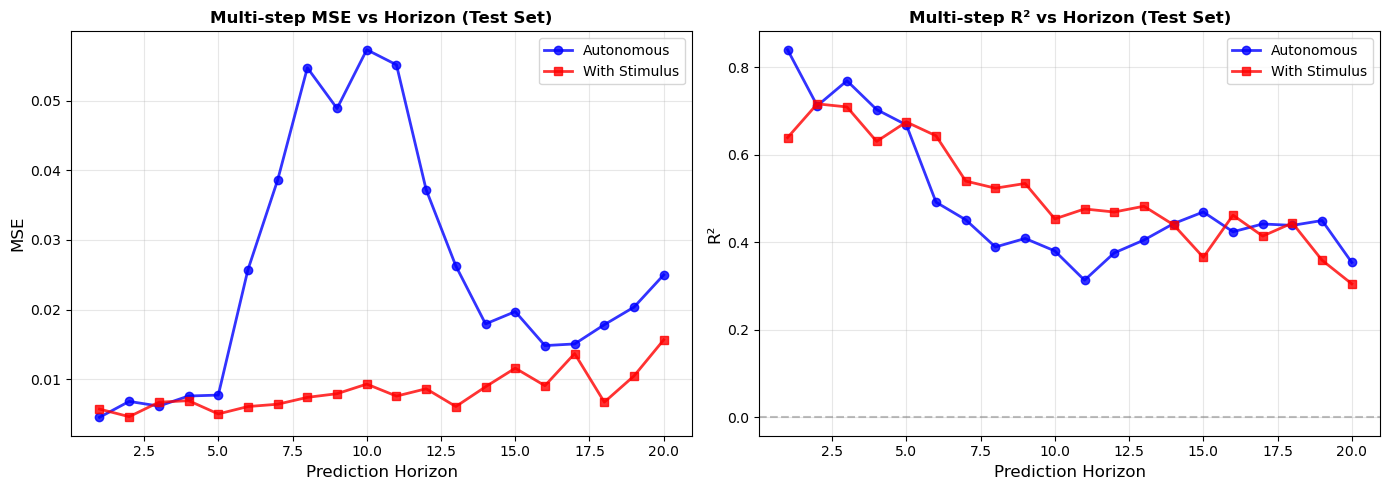

In [107]:
# --- Visualization: Horizon Metrics Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

horizons = np.arange(1, horizon + 1)

# MSE comparison
ax1 = axes[0]
ax1.plot(horizons, horizon_auto['mse_per_step'], 'o-', color='blue', linewidth=2, 
         markersize=6, label='Autonomous', alpha=0.8)
ax1.plot(horizons, horizon_stim['mse_per_step'], 's-', color='red', linewidth=2, 
         markersize=6, label='With Stimulus', alpha=0.8)
ax1.set_xlabel('Prediction Horizon', fontsize=12)
ax1.set_ylabel('MSE', fontsize=12)
ax1.set_title('Multi-step MSE vs Horizon (Test Set)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# R² comparison
ax2 = axes[1]
ax2.plot(horizons, horizon_auto['r2_per_step'], 'o-', color='blue', linewidth=2, 
         markersize=6, label='Autonomous', alpha=0.8)
ax2.plot(horizons, horizon_stim['r2_per_step'], 's-', color='red', linewidth=2, 
         markersize=6, label='With Stimulus', alpha=0.8)
ax2.set_xlabel('Prediction Horizon', fontsize=12)
ax2.set_ylabel('R²', fontsize=12)
ax2.set_title('Multi-step R² vs Horizon (Test Set)', fontsize=12, fontweight='bold')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Visualizing test trial 0 (stimulus intensity: 150)
Starting at timepoint 10 within trial
Prediction horizon: 50 steps

Trajectory shapes:
  True: (51, 5)
  Pred (auto): (51, 5)
  Pred (stim): (51, 5)


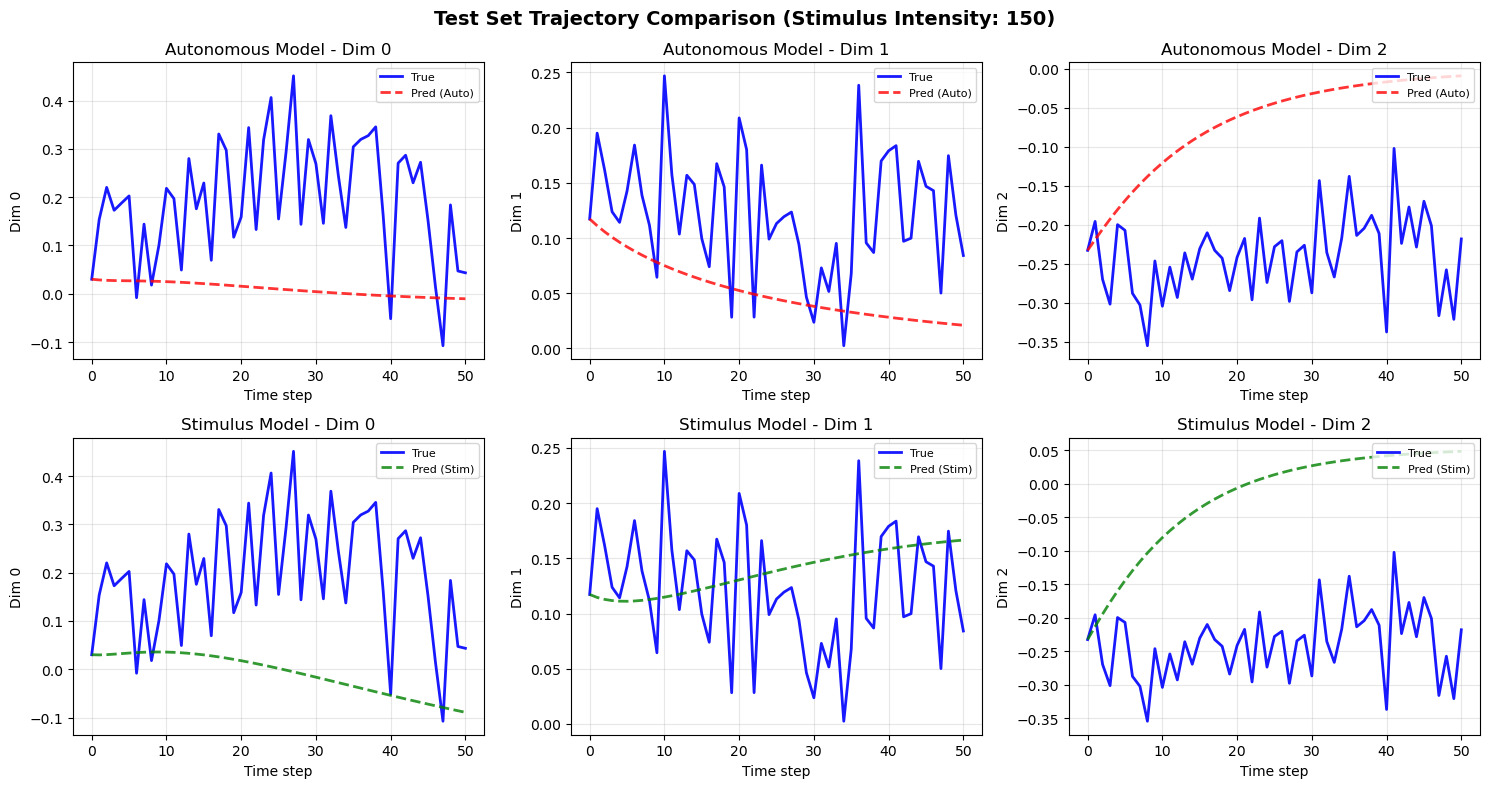

In [108]:
# --- Visualization: Sample Trajectory Comparison (Test Set) ---
# Select a trajectory from the test set for visualization
import builtins

# Pick a test trial with stimulation for interesting dynamics
test_stim_intensities = trial_subsets[test_trial_indices]
stim_trial_mask = test_stim_intensities > 0
if np.any(stim_trial_mask):
    # Use first stimulated trial in test set
    local_idx = np.where(stim_trial_mask)[0][0]
else:
    local_idx = 0

# Get the corresponding position in concatenated test data
sample_start = local_idx * T_time + 10  # Start a bit into the trial
sample_horizon = builtins.min(50, T_time - 20)  # Predict within trial

print(f"Visualizing test trial {local_idx} (stimulus intensity: {test_stim_intensities[local_idx]})")
print(f"Starting at timepoint {sample_start % T_time} within trial")
print(f"Prediction horizon: {sample_horizon} steps")

# Make sure we don't exceed bounds
if sample_start + sample_horizon + 1 > len(Z_test_concat):
    sample_start = len(Z_test_concat) - sample_horizon - 10
    sample_horizon = builtins.min(sample_horizon, len(Z_test_concat) - sample_start - 1)

z0 = Z_test_concat[sample_start]
V_segment_auto = np.zeros((sample_horizon, 1))  # No input for autonomous
V_segment_stim = V_test_normalized[sample_start:sample_start + sample_horizon]

# Get predictions from both models
Z_pred_auto = lds_auto.predict_trajectory(z0, V_segment_auto)
Z_pred_stim = lds_stim.predict_trajectory(z0, V_segment_stim)
Z_true = Z_test_concat[sample_start:sample_start + sample_horizon + 1]

print(f"\nTrajectory shapes:")
print(f"  True: {Z_true.shape}")
print(f"  Pred (auto): {Z_pred_auto.shape}")
print(f"  Pred (stim): {Z_pred_stim.shape}")

# Plot comparison for first 3 dimensions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
time_axis = np.arange(Z_true.shape[0])

for i, dim in enumerate([0, 1, 2]):
    # Top row: Autonomous model
    ax = axes[0, i]
    ax.plot(time_axis, Z_true[:, dim], 'b-', linewidth=2, label='True', alpha=0.9)
    ax.plot(time_axis, Z_pred_auto[:, dim], 'r--', linewidth=2, label='Pred (Auto)', alpha=0.8)
    ax.set_xlabel('Time step')
    ax.set_ylabel(f'Dim {dim}')
    ax.set_title(f'Autonomous Model - Dim {dim}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Bottom row: Stimulus model
    ax = axes[1, i]
    ax.plot(time_axis, Z_true[:, dim], 'b-', linewidth=2, label='True', alpha=0.9)
    ax.plot(time_axis, Z_pred_stim[:, dim], 'g--', linewidth=2, label='Pred (Stim)', alpha=0.8)
    ax.set_xlabel('Time step')
    ax.set_ylabel(f'Dim {dim}')
    ax.set_title(f'Stimulus Model - Dim {dim}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Test Set Trajectory Comparison (Stimulus Intensity: {test_stim_intensities[local_idx]})', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

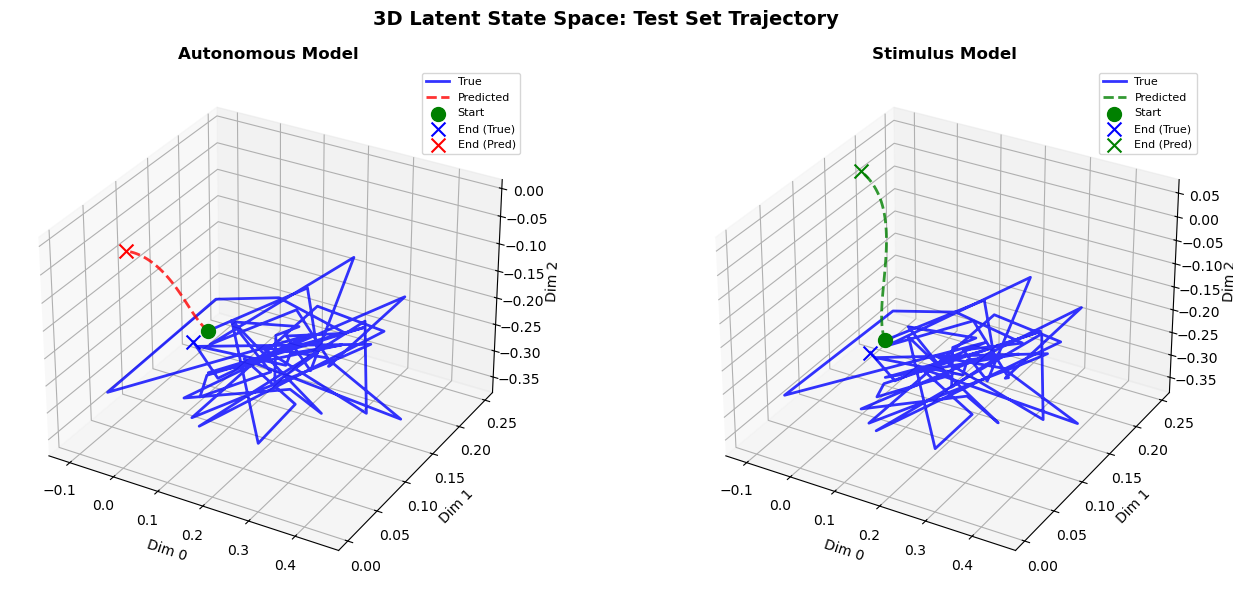

In [109]:
# --- 3D Trajectory Visualization (Test Set) ---
fig = plt.figure(figsize=(14, 6))

# Autonomous model
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(Z_true[:, 0], Z_true[:, 1], Z_true[:, 2], 
         'b-', linewidth=2, label='True', alpha=0.8)
ax1.plot(Z_pred_auto[:, 0], Z_pred_auto[:, 1], Z_pred_auto[:, 2], 
         'r--', linewidth=2, label='Predicted', alpha=0.8)
ax1.scatter(*Z_true[0, :3], color='green', s=100, marker='o', label='Start')
ax1.scatter(*Z_true[-1, :3], color='blue', s=100, marker='x', label='End (True)')
ax1.scatter(*Z_pred_auto[-1, :3], color='red', s=100, marker='x', label='End (Pred)')
ax1.set_xlabel('Dim 0')
ax1.set_ylabel('Dim 1')
ax1.set_zlabel('Dim 2')
ax1.set_title('Autonomous Model', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8)

# Stimulus model
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(Z_true[:, 0], Z_true[:, 1], Z_true[:, 2], 
         'b-', linewidth=2, label='True', alpha=0.8)
ax2.plot(Z_pred_stim[:, 0], Z_pred_stim[:, 1], Z_pred_stim[:, 2], 
         'g--', linewidth=2, label='Predicted', alpha=0.8)
ax2.scatter(*Z_true[0, :3], color='green', s=100, marker='o', label='Start')
ax2.scatter(*Z_true[-1, :3], color='blue', s=100, marker='x', label='End (True)')
ax2.scatter(*Z_pred_stim[-1, :3], color='green', s=100, marker='x', label='End (Pred)')
ax2.set_xlabel('Dim 0')
ax2.set_ylabel('Dim 1')
ax2.set_zlabel('Dim 2')
ax2.set_title('Stimulus Model', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8)

plt.suptitle('3D Latent State Space: Test Set Trajectory', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## LDS with Stimulus as Exogenous Input

For control applications (as in Fehrman et al. MPC), we need to model the effect of stimulation. Here we demonstrate by treating the **stimulus condition** as an exogenous input $v_t$, simulating the open-loop scenario where stimulus is applied but not controlled in real-time.

The model becomes: $z_{t+1} = Az_t + Bv_t$

where $v_t$ encodes the stimulus condition (one-hot or magnitude).

Learned LDS Matrices


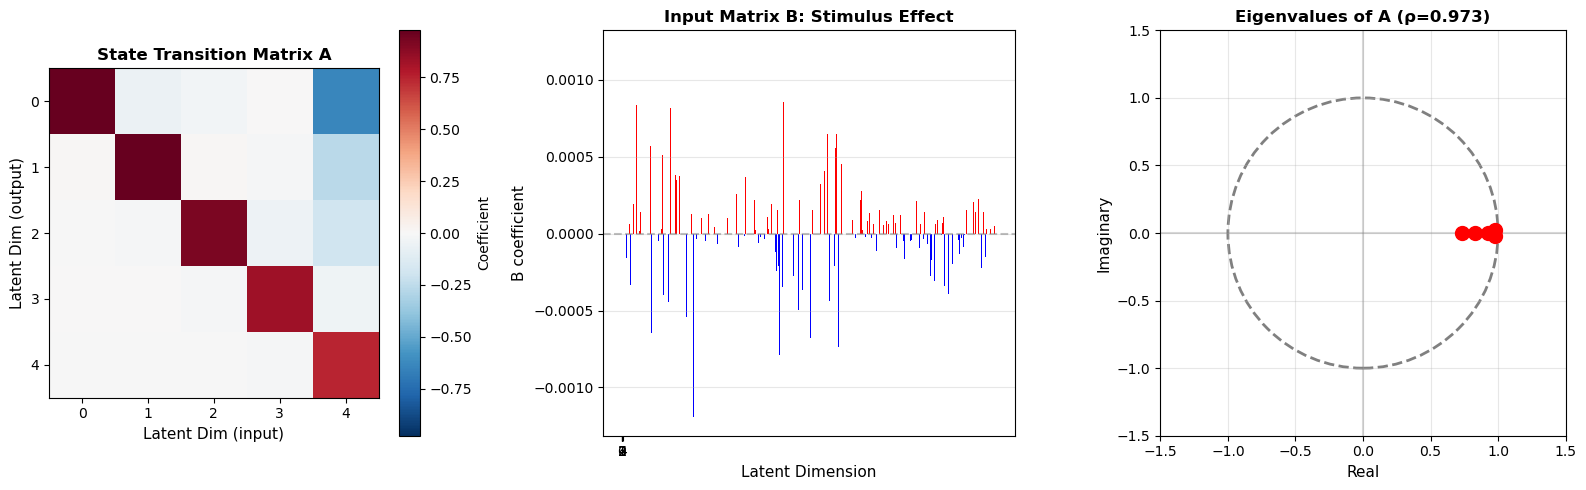


Matrix A statistics:
  Shape: (5, 5)
  Spectral radius: 0.9733
  Max |eigenvalue|: 0.9733
  Stable (ρ < 1): True

Matrix B statistics:
  Shape: (5, 471)
  Max absolute value: 0.0012
  B coefficients: [ 0.00000000e+00  1.49765575e-04  0.00000000e+00 ...  0.00000000e+00
 -9.30204545e-05 -8.67097068e-06]


In [110]:
# --- Visualize Learned Matrices A and B ---
print("=" * 60)
print("Learned LDS Matrices")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# A matrix (state transition)
ax1 = axes[0]
im1 = ax1.imshow(lds_stim.A, aspect='equal', cmap='RdBu_r',
                 vmin=-np.max(np.abs(lds_stim.A)),
                 vmax=np.max(np.abs(lds_stim.A)))
ax1.set_xlabel('Latent Dim (input)', fontsize=11)
ax1.set_ylabel('Latent Dim (output)', fontsize=11)
ax1.set_title('State Transition Matrix A', fontsize=12, fontweight='bold')
ax1.set_xticks(range(n_components_to_use))
ax1.set_yticks(range(n_components_to_use))
plt.colorbar(im1, ax=ax1, label='Coefficient')

# B matrix (stimulus input effect)
ax2 = axes[1]
B_display = lds_stim.B.flatten()
ax2.bar(range(len(B_display)), B_display, color=['red' if b > 0 else 'blue' for b in B_display])
ax2.set_xlabel('Latent Dimension', fontsize=11)
ax2.set_ylabel('B coefficient', fontsize=11)
ax2.set_title('Input Matrix B: Stimulus Effect', fontsize=12, fontweight='bold')
ax2.set_xticks(range(n_components_to_use))
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.grid(True, alpha=0.3, axis='y')

# Eigenvalues of A (stability analysis)
ax3 = axes[2]
eigenvalues = np.linalg.eigvals(lds_stim.A)
circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--', linewidth=2)
ax3.add_patch(circle)
ax3.scatter(eigenvalues.real, eigenvalues.imag, s=100, c='red', marker='o', zorder=5)
ax3.set_xlim(-1.5, 1.5)
ax3.set_ylim(-1.5, 1.5)
ax3.set_xlabel('Real', fontsize=11)
ax3.set_ylabel('Imaginary', fontsize=11)
ax3.set_title(f'Eigenvalues of A (ρ={lds_stim.spectral_radius():.3f})', fontsize=12, fontweight='bold')
ax3.set_aspect('equal')
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0, color='gray', alpha=0.3)
ax3.axvline(x=0, color='gray', alpha=0.3)

plt.tight_layout()
plt.show()

# Print matrix statistics
print(f"\nMatrix A statistics:")
print(f"  Shape: {lds_stim.A.shape}")
print(f"  Spectral radius: {lds_stim.spectral_radius():.4f}")
print(f"  Max |eigenvalue|: {np.max(np.abs(eigenvalues)):.4f}")
print(f"  Stable (ρ < 1): {lds_stim.spectral_radius() < 1}")

print(f"\nMatrix B statistics:")
print(f"  Shape: {lds_stim.B.shape}")
print(f"  Max absolute value: {np.max(np.abs(lds_stim.B)):.4f}")
print(f"  B coefficients: {lds_stim.B.flatten()}")

Per-Trial Analysis by Stimulus Condition

Stim Intensity | N Trials | Auto R² (mean) | Stim R² (mean) |     Δ R²
---------------------------------------------------------------------------
             0 |       15 |        +0.7360 |        +0.7364 |  +0.0004 [NO STIM]
             5 |        3 |        +0.6957 |        +0.6962 |  +0.0005 [STIM]
            10 |        1 |        +0.6386 |        +0.6389 |  +0.0003 [STIM]
            20 |        2 |        +0.8165 |        +0.8168 |  +0.0004 [STIM]
            30 |        4 |        +0.7392 |        +0.7421 |  +0.0029 [STIM]
            50 |        2 |        +0.7875 |        +0.7871 |  -0.0004 [STIM]
           150 |        6 |        +0.8203 |        +0.8205 |  +0.0002 [STIM]


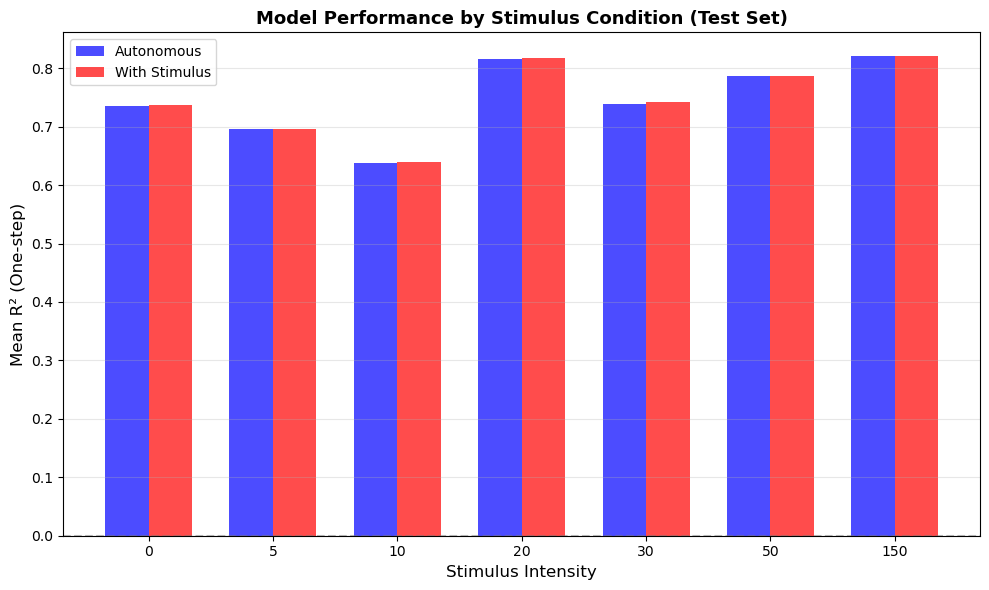

In [111]:
# --- Per-Trial Evaluation: Compare predictions across different stimulus conditions ---
print("=" * 60)
print("Per-Trial Analysis by Stimulus Condition")
print("=" * 60)

# Evaluate both models on individual test trials
results_by_condition = {}

for trial_local_idx in range(len(test_trial_indices)):
    stim_intensity = test_stim_intensities[trial_local_idx]
    
    # Get this trial's data
    trial_start = trial_local_idx * T_time
    trial_end = (trial_local_idx + 1) * T_time
    
    Z_trial = Z_test_concat[trial_start:trial_end]
    V_trial = V_test_normalized[trial_start:trial_end-1]
    
    # One-step metrics for this trial
    auto_metrics = compute_one_step_metrics(lds_auto, Z_trial, V=None)
    stim_metrics = compute_one_step_metrics(lds_stim, Z_trial, V=V_trial)
    
    if stim_intensity not in results_by_condition:
        results_by_condition[stim_intensity] = {'auto_r2': [], 'stim_r2': [], 'n_trials': 0}
    
    results_by_condition[stim_intensity]['auto_r2'].append(auto_metrics['r2'])
    results_by_condition[stim_intensity]['stim_r2'].append(stim_metrics['r2'])
    results_by_condition[stim_intensity]['n_trials'] += 1

# Print summary by condition
print(f"\n{'Stim Intensity':>14} | {'N Trials':>8} | {'Auto R² (mean)':>14} | {'Stim R² (mean)':>14} | {'Δ R²':>8}")
print("-" * 75)

intensities_sorted = sorted(results_by_condition.keys())
for intensity in intensities_sorted:
    data = results_by_condition[intensity]
    auto_mean = np.mean(data['auto_r2'])
    stim_mean = np.mean(data['stim_r2'])
    delta = stim_mean - auto_mean
    stim_type = "NO STIM" if intensity == 0 else "STIM"
    print(f"{intensity:14d} | {data['n_trials']:8d} | {auto_mean:+14.4f} | {stim_mean:+14.4f} | {delta:+8.4f} [{stim_type}]")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
x_positions = np.arange(len(intensities_sorted))
width = 0.35

auto_means = [np.mean(results_by_condition[i]['auto_r2']) for i in intensities_sorted]
stim_means = [np.mean(results_by_condition[i]['stim_r2']) for i in intensities_sorted]

bars1 = ax.bar(x_positions - width/2, auto_means, width, label='Autonomous', color='blue', alpha=0.7)
bars2 = ax.bar(x_positions + width/2, stim_means, width, label='With Stimulus', color='red', alpha=0.7)

ax.set_xlabel('Stimulus Intensity', fontsize=12)
ax.set_ylabel('Mean R² (One-step)', fontsize=12)
ax.set_title('Model Performance by Stimulus Condition (Test Set)', fontsize=13, fontweight='bold')
ax.set_xticks(x_positions)
ax.set_xticklabels([str(i) for i in intensities_sorted])
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Summary & Next Steps

### What we implemented:
1. **`RidgeLDS` class**: A Linear Dynamical System trained via Ridge Regression
   - Fits $z_{t+1} = Az_t + Bv_t$ using closed-form or sklearn solutions
   - Handles both autonomous (no input) and controlled (with input) cases
   
2. **Evaluation metrics**:
   - One-step-ahead: MSE and R² for immediate prediction quality
   - Multi-step (horizon): Recursive prediction performance over time
   
3. **Application to dPCA latent space**:
   - Autonomous dynamics model
   - Model with stimulus as exogenous input

### Connection to Fehrman et al. MPC Framework:
The learned matrices $(A, B)$ can be directly used in a Model Predictive Control (MPC) formulation:

$$\min_{v_0, \ldots, v_{H-1}} \sum_{t=0}^{H-1} \| z_t - z^{\text{target}} \|_Q^2 + \| v_t \|_R^2$$

subject to: $z_{t+1} = Az_t + Bv_t$

### Future extensions:
- **Cross-validation** for hyperparameter selection
- **Time-varying LDS** (switching dynamics)
- **Nonlinear extensions** (e.g., Neural Network dynamics)
- **Integration with real-time photostimulation control**

## Corrected Multi-Step Evaluation: Post-Stimulus Analysis

The previous evaluation had two issues:
1. **Mixed stim and no-stim trials**: The stimulus model should only be evaluated on trials that actually have stimulation
2. **Ignored stimulation timing**: The stimulus effect should only be measured at timesteps **after** stimulation onset

### Corrected Approach:
- Evaluate **Autonomous model** on **NO-STIM trials** (baseline dynamics)
- Compare **Autonomous vs Stimulus model** on **STIM trials only**
- Start evaluation at timesteps **after stimulation onset** (not from trial start)

In [112]:
# --- Corrected Multi-Step Evaluation: Separate Stim vs No-Stim Trials ---
"""
Key corrections:
1. Evaluate autonomous model on NO-STIM trials only (v_t = 0)
2. Evaluate stimulus model on STIM trials only (v_t > 0)
3. Focus evaluation on timesteps AFTER stimulation onset
"""

import builtins

print("=" * 70)
print("Corrected Multi-Step Evaluation: Stim vs No-Stim Trials")
print("=" * 70)

# --- Identify stimulation timing ---
filter_ps_time = s0.get('filter_ps_time', None)
print(f"\nfilter_ps_time shape: {filter_ps_time.shape if filter_ps_time is not None else 'None'}")
if filter_ps_time is not None:
    print(f"filter_ps_time dtype: {filter_ps_time.dtype}")
    # Check if it's a boolean array indicating stim times
    if filter_ps_time.dtype == bool:
        stim_timepoints = np.where(filter_ps_time)[0]
        if len(stim_timepoints) > 0:
            print(f"Stim timepoints range: {stim_timepoints.min()} to {stim_timepoints.max()}")
    
# Typical experimental structure: baseline -> stimulus -> response
# Define stimulation window based on experiment structure
# For Rowland data: ~30% baseline, then stimulus period
BASELINE_FRACTION = 0.3
stim_onset_idx = int(BASELINE_FRACTION * T_time) - 1
print(f"\nTotal timepoints per trial: {T_time}")
print(f"Assumed stimulation onset: timepoint {stim_onset_idx} ({BASELINE_FRACTION*100:.0f}% into trial)")

# --- Separate test trials by stimulation condition ---
test_stim_intensities = trial_subsets[test_trial_indices]

# Indices within test set (local indices)
no_stim_mask = test_stim_intensities == 0
stim_mask_test = test_stim_intensities > 0

no_stim_local_indices = np.where(no_stim_mask)[0]
stim_local_indices = np.where(stim_mask_test)[0]

print(f"\n--- Test Set Breakdown ---")
print(f"Total test trials: {len(test_trial_indices)}")
print(f"  No-stim trials (v=0): {len(no_stim_local_indices)}")
print(f"  Stim trials (v>0):    {len(stim_local_indices)}")

if len(stim_local_indices) > 0:
    stim_intensities_in_test = test_stim_intensities[stim_mask_test]
    print(f"  Stim intensities present: {np.unique(stim_intensities_in_test)}")

Corrected Multi-Step Evaluation: Stim vs No-Stim Trials

filter_ps_time shape: (420,)
filter_ps_time dtype: float64

Total timepoints per trial: 420
Assumed stimulation onset: timepoint 125 (30% into trial)

--- Test Set Breakdown ---
Total test trials: 33
  No-stim trials (v=0): 15
  Stim trials (v>0):    18
  Stim intensities present: [  5  10  20  30  50 150]


In [113]:
# --- Helper Functions for Corrected Evaluation ---
from sklearn.metrics import r2_score

def compute_trial_horizon_metrics(model, Z_trial, V_trial, 
                                   start_idx, horizon, 
                                   use_input=False):
    """
    Compute horizon metrics for a single trial starting at start_idx.
    
    Parameters
    ----------
    model : RidgeLDS
    Z_trial : ndarray (T, n_latent) - single trial trajectory
    V_trial : ndarray (T, n_inputs) or None - stimulus input for this trial
              n_inputs can be 1 (scalar) or n_cells (vector)
    start_idx : int - starting timepoint within trial
    horizon : int - prediction horizon
    use_input : bool - whether to use stimulus input in prediction
    
    Returns
    -------
    mse_per_step : ndarray (actual_horizon,)
    predictions : ndarray (actual_horizon+1, n_latent)
    ground_truth : ndarray (actual_horizon+1, n_latent)
    """
    T_trial = Z_trial.shape[0]
    
    # Ensure we don't exceed trial bounds
    end_idx = builtins.min(start_idx + horizon, T_trial - 1)
    actual_horizon = end_idx - start_idx
    
    if actual_horizon < 1:
        return None, None, None
    
    z0 = Z_trial[start_idx]
    
    if use_input and V_trial is not None:
        V_segment = V_trial[start_idx:start_idx + actual_horizon]
    else:
        # Match the shape expected by model.B
        # model.B has shape (n_latent, n_inputs)
        n_inputs = model.n_inputs if model.n_inputs > 0 else 1
        V_segment = np.zeros((actual_horizon, n_inputs))
    
    # Recursive prediction
    Z_pred = model.predict_trajectory(z0, V_segment)
    Z_true = Z_trial[start_idx:start_idx + actual_horizon + 1]
    
    # MSE per step
    mse_per_step = np.mean((Z_pred[1:] - Z_true[1:]) ** 2, axis=1)
    
    return mse_per_step, Z_pred, Z_true


def evaluate_model_on_trial_subset(model, Z_trials_array, V_trials_array,
                                    trial_local_indices, T_time,
                                    eval_start_offset, horizon,
                                    use_input=False):
    """
    Evaluate model on a subset of trials, starting evaluation at a specific
    offset within each trial (e.g., after stimulation onset).
    
    Parameters
    ----------
    model : RidgeLDS
    Z_trials_array : ndarray (n_trials, T, n_latent) - all trial trajectories
    V_trials_array : ndarray (n_trials, T, n_inputs) - stimulus inputs per trial
                     n_inputs can be 1 (scalar) or n_cells (vector)
    trial_local_indices : array - which trials to evaluate (indices into test set)
    T_time : int - timepoints per trial
    eval_start_offset : int - where within each trial to start evaluation
    horizon : int - prediction horizon
    use_input : bool - whether to use stimulus input
    
    Returns
    -------
    metrics : dict with mse_per_step, r2_per_step, etc.
    """
    all_mse_per_step = []
    all_predictions = {h: [] for h in range(1, horizon + 1)}
    all_ground_truth = {h: [] for h in range(1, horizon + 1)}
    
    for local_idx in trial_local_indices:
        # Get this trial's data
        Z_trial = Z_trials_array[local_idx]  # (T, n_latent)
        
        # Handle V_trial shape: could be (T,), (T, 1), or (T, n_cells)
        V_trial_raw = V_trials_array[local_idx]
        if V_trial_raw.ndim == 1:
            V_trial = V_trial_raw.reshape(-1, 1)  # (T, 1)
        else:
            V_trial = V_trial_raw  # (T, n_inputs) - keep as is
        
        # Start evaluation at the specified offset (e.g., after stim onset)
        start_idx = eval_start_offset
        
        mse_steps, Z_pred, Z_true = compute_trial_horizon_metrics(
            model, Z_trial, V_trial, start_idx, horizon, use_input
        )
        
        if mse_steps is None:
            continue
            
        # Pad if needed (trial might be shorter than horizon)
        actual_horizon = len(mse_steps)
        padded_mse = np.full(horizon, np.nan)
        padded_mse[:actual_horizon] = mse_steps
        all_mse_per_step.append(padded_mse)
        
        # Store predictions for R² calculation
        for h in range(1, builtins.min(actual_horizon + 1, horizon + 1)):
            all_predictions[h].append(Z_pred[h])
            all_ground_truth[h].append(Z_true[h])
    
    if len(all_mse_per_step) == 0:
        return None
    
    # Aggregate MSE (nanmean to handle different trial lengths)
    all_mse_per_step = np.array(all_mse_per_step)
    mse_per_step = np.nanmean(all_mse_per_step, axis=0)
    
    # Compute R² per horizon step across all trials
    # This computes R² treating each trial's prediction at horizon h as a sample
    r2_per_step = []
    for h in range(1, horizon + 1):
        if len(all_predictions[h]) > 1:
            y_true = np.array(all_ground_truth[h])  # (n_trials, n_latent)
            y_pred = np.array(all_predictions[h])   # (n_trials, n_latent)
            # Compute multioutput R² (global variance across trials)
            r2 = r2_score(y_true, y_pred, multioutput='variance_weighted')
        else:
            r2 = np.nan
        r2_per_step.append(r2)
    
    return {
        'mse_per_step': mse_per_step,
        'r2_per_step': np.array(r2_per_step),
        'n_trials': len(trial_local_indices),
        'n_trials_evaluated': len(all_mse_per_step)
    }


print("Helper functions defined for corrected evaluation.")
print(f"Note: These functions now handle vector stimulus V of shape (T, n_cells)")

Helper functions defined for corrected evaluation.
Note: These functions now handle vector stimulus V of shape (T, n_cells)


In [114]:
# --- Run Corrected Evaluation ---

# Evaluation parameters
horizon = 30  # Predict up to 30 steps after stim onset
eval_start_after_stim = stim_onset_idx + 5  # Start eval 5 steps after stim onset

print(f"\n--- Evaluation Parameters ---")
print(f"Horizon: {horizon} steps")
print(f"Evaluation starts at: timepoint {eval_start_after_stim} (post-stimulus)")

# Prepare trial-level data arrays for evaluation
# Z_test has shape (n_test_trials, T, n_latent)
# V_test has shape (n_test_trials, T, n_cells) - NOW A VECTOR!

print(f"\nZ_test shape: {Z_test.shape}")
print(f"V_test shape: {V_test.shape}")

# V is already binary (0/1), no normalization needed
V_test_trials_normalized = V_test  # Shape: (n_trials, T, n_cells)

# --- Check model compatibility ---
print(f"\n--- Model Compatibility Check ---")
print(f"LDS model n_inputs: {lds_stim.n_inputs}")
print(f"V_test n_inputs: {V_test.shape[2]}")

if lds_stim.n_inputs != V_test.shape[2]:
    print(f"\n⚠️  WARNING: Model was trained with stim_dim={lds_stim.n_inputs}, but V_test has {V_test.shape[2]} dimensions!")
    print(f"    Please RE-RUN the notebook cells from the data preparation cell onwards.")
    print(f"    The LDS models need to be re-trained with the new vector stimulus format.")
    raise ValueError(f"Model stim_dim mismatch: model expects {lds_stim.n_inputs}, got {V_test.shape[2]}")

# --- Evaluate Autonomous Model on NO-STIM trials ---
print(f"\n{'='*70}")
print("AUTONOMOUS MODEL on NO-STIM Trials (Baseline Dynamics)")
print(f"{'='*70}")

if len(no_stim_local_indices) > 0:
    metrics_auto_nostim = evaluate_model_on_trial_subset(
        lds_auto, Z_test, V_test_trials_normalized,
        no_stim_local_indices, T_time,
        eval_start_offset=stim_onset_idx,  # Evaluate from "stimulus time" for comparison
        horizon=horizon,
        use_input=False
    )
    
    if metrics_auto_nostim:
        print(f"Evaluated {metrics_auto_nostim['n_trials_evaluated']} / {metrics_auto_nostim['n_trials']} no-stim trials")
        print(f"\nSample MSE/R² at selected horizons:")
        print(f"{'H':>4} | {'MSE':>10} | {'R²':>8}")
        print("-" * 30)
        for h in [1, 5, 10, 15, 20, 25, 30]:
            if h <= horizon:
                print(f"{h:4d} | {metrics_auto_nostim['mse_per_step'][h-1]:.6f} | {metrics_auto_nostim['r2_per_step'][h-1]:+.4f}")
else:
    print("No no-stim trials in test set!")
    metrics_auto_nostim = None

# --- Evaluate BOTH models on STIM trials (post-stimulus) ---
print(f"\n{'='*70}")
print("STIMULUS MODEL vs AUTONOMOUS on STIM Trials (Post-Stimulus)")
print(f"{'='*70}")

if len(stim_local_indices) > 0:
    # Autonomous model on stim trials (doesn't use stimulus info)
    metrics_auto_stim = evaluate_model_on_trial_subset(
        lds_auto, Z_test, V_test_trials_normalized,
        stim_local_indices, T_time,
        eval_start_offset=eval_start_after_stim,
        horizon=horizon,
        use_input=False  # Autonomous doesn't use input
    )
    
    # Stimulus model on stim trials (uses stimulus info)
    metrics_stim_stim = evaluate_model_on_trial_subset(
        lds_stim, Z_test, V_test_trials_normalized,
        stim_local_indices, T_time,
        eval_start_offset=eval_start_after_stim,
        horizon=horizon,
        use_input=True  # Uses stimulus input
    )
    
    if metrics_auto_stim and metrics_stim_stim:
        print(f"Evaluated on {metrics_stim_stim['n_trials_evaluated']} stim trials")
        print(f"\nComparison at selected horizons:")
        print(f"{'Step':>4} | {'Auto MSE':>10} | {'Stim MSE':>10} | {'Auto R²':>8} | {'Stim R²':>8} | {'Δ R²':>8}")
        print("-" * 70)
        
        for h in [1, 2, 5, 10, 15, 20, 25, 30]:
            if h <= horizon:
                auto_mse = metrics_auto_stim['mse_per_step'][h-1]
                stim_mse = metrics_stim_stim['mse_per_step'][h-1]
                auto_r2 = metrics_auto_stim['r2_per_step'][h-1]
                stim_r2 = metrics_stim_stim['r2_per_step'][h-1]
                delta_r2 = stim_r2 - auto_r2
                print(f"{h:4d} | {auto_mse:10.6f} | {stim_mse:10.6f} | {auto_r2:+8.4f} | {stim_r2:+8.4f} | {delta_r2:+8.4f}")
else:
    print("No stim trials in test set!")
    metrics_auto_stim = None
    metrics_stim_stim = None


--- Evaluation Parameters ---
Horizon: 30 steps
Evaluation starts at: timepoint 130 (post-stimulus)

Z_test shape: (33, 420, 5)
V_test shape: (33, 420, 471)

--- Model Compatibility Check ---
LDS model n_inputs: 471
V_test n_inputs: 471

AUTONOMOUS MODEL on NO-STIM Trials (Baseline Dynamics)
Evaluated 15 / 15 no-stim trials

Sample MSE/R² at selected horizons:
   H |        MSE |       R²
------------------------------
   1 | 0.000821 | -98594067173598810655009275904.0000
   5 | 0.008376 | -1441085657764506625596540846080.0000
  10 | 0.003381 | -994540569793500355814047612928.0000
  15 | 0.009872 | -2435186434607223643521186529280.0000
  20 | 0.007790 | -1321357011832802554379468013568.0000
  25 | 0.030026 | -25172346508437302001440435208192.0000
  30 | 0.026343 | -2399806817052979357115289174016.0000

STIMULUS MODEL vs AUTONOMOUS on STIM Trials (Post-Stimulus)
Evaluated on 18 stim trials

Comparison at selected horizons:
Step |   Auto MSE |   Stim MSE |  Auto R² |  Stim R² |     Δ R²

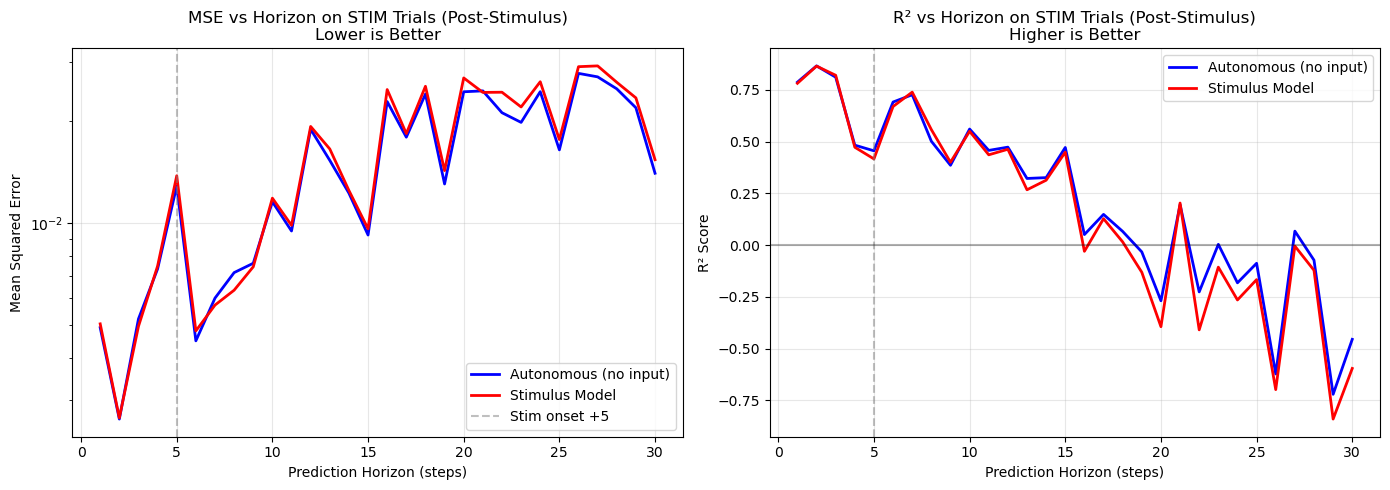


SUMMARY: Does the Stimulus Model Improve Post-Stim Prediction?

Average ΔR² (Stim - Auto): -0.0466
Average MSE Reduction: -5.6%

Early horizon (1-10 steps) ΔR²: +0.0004
Late horizon (20-30 steps) ΔR²: -0.0935

✗ Stimulus model performs WORSE than autonomous in post-stimulus period


In [115]:
# --- Visualization: Corrected Multi-Step Metrics ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

horizons = np.arange(1, horizon + 1)

# MSE comparison on STIM trials
ax1 = axes[0]
if metrics_auto_stim and metrics_stim_stim:
    ax1.plot(horizons, metrics_auto_stim['mse_per_step'], 'b-', linewidth=2, label='Autonomous (no input)')
    ax1.plot(horizons, metrics_stim_stim['mse_per_step'], 'r-', linewidth=2, label='Stimulus Model')
    ax1.axvline(x=5, color='gray', linestyle='--', alpha=0.5, label='Stim onset +5')
ax1.set_xlabel('Prediction Horizon (steps)')
ax1.set_ylabel('Mean Squared Error')
ax1.set_title('MSE vs Horizon on STIM Trials (Post-Stimulus)\nLower is Better')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# R² comparison on STIM trials
ax2 = axes[1]
if metrics_auto_stim and metrics_stim_stim:
    ax2.plot(horizons, metrics_auto_stim['r2_per_step'], 'b-', linewidth=2, label='Autonomous (no input)')
    ax2.plot(horizons, metrics_stim_stim['r2_per_step'], 'r-', linewidth=2, label='Stimulus Model')
    ax2.axvline(x=5, color='gray', linestyle='--', alpha=0.5)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.set_xlabel('Prediction Horizon (steps)')
ax2.set_ylabel('R² Score')
ax2.set_title('R² vs Horizon on STIM Trials (Post-Stimulus)\nHigher is Better')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
if metrics_auto_stim and metrics_stim_stim:
    print("\n" + "="*60)
    print("SUMMARY: Does the Stimulus Model Improve Post-Stim Prediction?")
    print("="*60)
    
    # Average improvement over all horizons
    avg_delta_r2 = np.mean(metrics_stim_stim['r2_per_step'] - metrics_auto_stim['r2_per_step'])
    avg_delta_mse = np.mean(metrics_auto_stim['mse_per_step'] - metrics_stim_stim['mse_per_step'])
    pct_mse_reduction = 100 * avg_delta_mse / np.mean(metrics_auto_stim['mse_per_step'])
    
    print(f"\nAverage ΔR² (Stim - Auto): {avg_delta_r2:+.4f}")
    print(f"Average MSE Reduction: {pct_mse_reduction:.1f}%")
    
    # Early horizon (1-10 steps)
    early_delta_r2 = np.mean(metrics_stim_stim['r2_per_step'][:10] - metrics_auto_stim['r2_per_step'][:10])
    # Late horizon (20-30 steps)
    late_delta_r2 = np.mean(metrics_stim_stim['r2_per_step'][19:] - metrics_auto_stim['r2_per_step'][19:])
    
    print(f"\nEarly horizon (1-10 steps) ΔR²: {early_delta_r2:+.4f}")
    print(f"Late horizon (20-30 steps) ΔR²: {late_delta_r2:+.4f}")
    
    # Conclusion
    if avg_delta_r2 > 0.01:
        print("\n✓ Stimulus model IMPROVES prediction in post-stimulus period")
    elif avg_delta_r2 < -0.01:
        print("\n✗ Stimulus model performs WORSE than autonomous in post-stimulus period")
    else:
        print("\n≈ Stimulus model performs similarly to autonomous")

lds_auto.B shape: (5, 1), n_inputs: 0
lds_stim.B shape: (5, 471), n_inputs: 471
V_future shape: (30, 471)


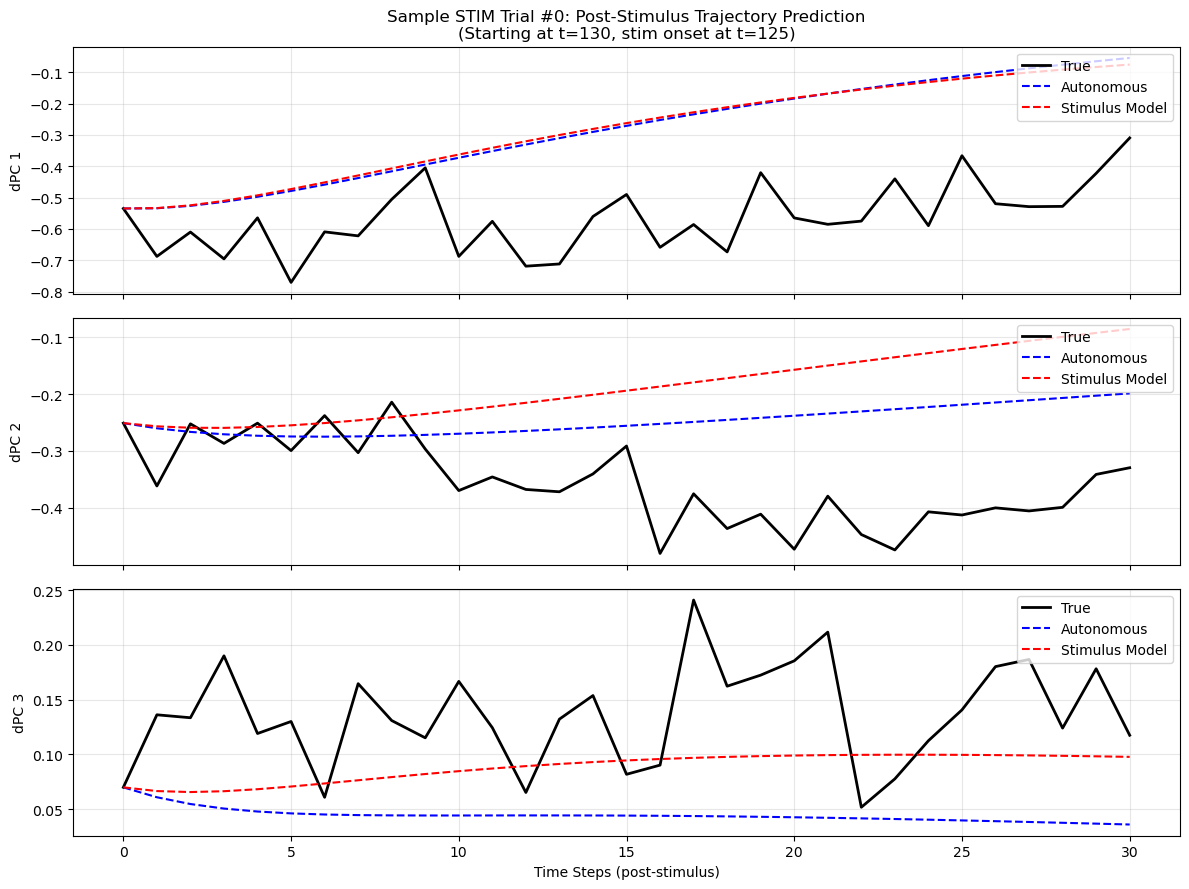


Neurons targeted in this trial: 177
Timepoints with stimulation: 30 / 30


In [116]:
# --- Visualization: Sample STIM Trial Trajectory (Post-Stimulus) ---

if len(stim_local_indices) > 0 and metrics_stim_stim:
    # Select a sample stim trial
    sample_idx = stim_local_indices[0]
    Z_sample = Z_test[sample_idx]  # (T, n_latent)
    V_sample = V_test[sample_idx]  # (T, n_cells) - NOW A VECTOR!
    
    # Initial state: just after stimulus onset
    start_t = eval_start_after_stim
    z0 = Z_sample[start_t]
    
    # Ensure we have enough horizon within trial bounds
    available_horizon = builtins.min(horizon, T_time - start_t - 1)
    
    # Print model dimensions for debugging
    print(f"lds_auto.B shape: {lds_auto.B.shape}, n_inputs: {lds_auto.n_inputs}")
    print(f"lds_stim.B shape: {lds_stim.B.shape}, n_inputs: {lds_stim.n_inputs}")
    
    # V_future: shape (horizon, n_cells) - the actual stimulation vector
    V_future = V_sample[start_t:start_t + available_horizon]  # (horizon, n_cells)
    print(f"V_future shape: {V_future.shape}")
    
    # IMPORTANT: Each model needs V with matching dimensions!
    # lds_auto was trained with V=None, so its B has shape (n_latent, 1)
    # lds_stim was trained with V=(T-1, n_cells), so its B has shape (n_latent, n_cells)
    
    # For autonomous model: use V with shape (horizon, 1) to match B
    V_zeros_auto = np.zeros((available_horizon, lds_auto.B.shape[1]))
    
    # For stimulus model: use actual V with shape (horizon, n_cells)
    V_zeros_stim = np.zeros((available_horizon, lds_stim.n_inputs))
    
    # Predict with autonomous model (no input, uses B shape (n_latent, 1))
    traj_auto = lds_auto.predict_trajectory(z0, V_zeros_auto)
    
    # Predict with stimulus model (uses stimulus input)
    traj_stim = lds_stim.predict_trajectory(z0, V_future)
    
    # True trajectory
    end_t = start_t + available_horizon + 1
    traj_true = Z_sample[start_t:end_t]
    
    # Plot first 3 components
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    time_horizon = np.arange(len(traj_true))
    
    for i, ax in enumerate(axes[:3]):
        ax.plot(time_horizon, traj_true[:, i], 'k-', linewidth=2, label='True')
        ax.plot(time_horizon, traj_auto[:len(traj_true), i], 'b--', linewidth=1.5, label='Autonomous')
        ax.plot(time_horizon, traj_stim[:len(traj_true), i], 'r--', linewidth=1.5, label='Stimulus Model')
        ax.set_ylabel(f'dPC {i+1}')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    
    axes[0].set_title(f'Sample STIM Trial #{sample_idx}: Post-Stimulus Trajectory Prediction\n(Starting at t={start_t}, stim onset at t={stim_onset_idx})')
    axes[-1].set_xlabel('Time Steps (post-stimulus)')
    
    plt.tight_layout()
    plt.show()
    
    # Show stimulus info
    n_neurons_stimulated = (V_future.sum(axis=1) > 0).sum()  # Number of timepoints with stim
    total_neurons_targeted = (V_future.any(axis=0)).sum()  # Number of unique neurons stimulated
    print(f"\nNeurons targeted in this trial: {total_neurons_targeted}")
    print(f"Timepoints with stimulation: {n_neurons_stimulated} / {len(V_future)}")
else:
    print("No stim trials available for visualization")

# Temporal Convolutional Network (TCN) for Neural Dynamics Prediction

## Model Overview

We implement a **Temporal Convolutional Network (TCN)** combined with a **Multi-Layer Perceptron (MLP)** head to predict the next latent neural state $z_{t+1}$ based on a window of past states $z_{t-k:t}$ and past photostimulation inputs $v_{t-k:t}$.

### Key Innovation: Full Neuron Stimulation Vector

Unlike a scalar intensity value, we use the **full stimulation vector** $v_t \in \{0, 1\}^{n_{cells}}$ indicating which specific neurons were optogenetically stimulated at each timepoint:

$$v_t[i] = \begin{cases} 1 & \text{if neuron } i \text{ was stimulated at time } t \\ 0 & \text{otherwise} \end{cases}$$

This allows the model to learn **how stimulating specific neurons affects the latent dynamics**.

### Model Architecture

$$\hat{z}_{t+1} = \text{MLP}\left(\text{TCN}\left([z_{t-k}, z_{t-k+1}, \ldots, z_t] \oplus [v_{t-k}, v_{t-k+1}, \ldots, v_t]\right)\right)$$

Where:
- $z_t \in \mathbb{R}^{n_{latent}}$ is the latent state (dPCA components)
- $v_t \in \{0, 1\}^{n_{cells}}$ is the **full stimulation vector** (which neurons were stimulated)
- $\oplus$ denotes concatenation along the feature dimension

---

## Dilated Causal Convolutions

The key innovation in TCNs is the use of **dilated causal convolutions**. A standard 1D convolution with kernel size $K$ only looks at $K$ consecutive timesteps. To capture long-range dependencies, we use **dilated convolutions** that introduce gaps (dilation) between kernel elements:

### Dilation Factor $d$

For a 1D dilated convolution with dilation $d$, the operation at output position $t$ is:

$$y_t = \sum_{i=0}^{K-1} w_i \cdot x_{t - d \cdot i}$$

Where:
- $w_i$ are the kernel weights
- $d$ is the dilation factor (spacing between samples)
- $K$ is the kernel size

### Receptive Field Calculation

For a TCN with $L$ layers, exponentially increasing dilations $d_l = 2^{l-1}$ for layer $l$, the **receptive field** is:

$$\boxed{\text{Receptive Field} = 1 + (K - 1) \cdot \sum_{l=1}^{L} d_l = 1 + (K-1) \cdot (2^L - 1)}$$

**Example**: With $K=3$ (kernel size) and $L=4$ layers with dilations $[1, 2, 4, 8]$:
$$\text{RF} = 1 + 2 \cdot (1 + 2 + 4 + 8) = 1 + 2 \cdot 15 = 31 \text{ timesteps}$$

This allows capturing **long-range temporal dependencies** with only a few layers and small kernels

### Causality

Each convolution only looks at **past** timesteps (causal padding), ensuring no information leakage from the future:

$$y_t = f(x_t, x_{t-1}, x_{t-2}, \ldots, x_{t-k})$$

---

## Architecture Details

```
Input: (batch, window_size, latent_dim + n_cells)
         ↓
    ┌─────────────────────────────┐
    │   Temporal Block 1 (d=1)    │  Conv1D → BatchNorm → ReLU → Dropout
    │   + Residual Connection     │
    └─────────────────────────────┘
         ↓
    ┌─────────────────────────────┐
    │   Temporal Block 2 (d=2)    │
    │   + Residual Connection     │
    └─────────────────────────────┘
         ↓
    ┌─────────────────────────────┐
    │   Temporal Block 3 (d=4)    │
    │   + Residual Connection     │
    └─────────────────────────────┘
         ↓
    Take last timestep output
         ↓
    ┌─────────────────────────────┐
    │   MLP Head                  │  Linear → ReLU → Linear → ReLU → Linear
    │   (Hidden → Hidden → Out)   │
    └─────────────────────────────┘
         ↓
Output: (batch, latent_dim)
```

### Why Full Stimulation Vector?

Using the full vector $v_t \in \{0, 1\}^{n_{cells}}$ instead of scalar intensity allows the model to:

1. **Learn neuron-specific effects**: Different neurons may have different impacts on latent dynamics
2. **Predict responses to novel stimulation patterns**: Generalize to new combinations of stimulated neurons
3. **Enable control design**: The B matrix (effect of stimulation on latent dynamics) can be estimated for each neuron

In [117]:
# --- PyTorch Imports and TCN Implementation ---
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from typing import List, Tuple

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


class CausalConv1d(nn.Module):
    """
    Causal 1D Convolution with proper padding to ensure no future information leakage.
    
    For a kernel of size K with dilation d, we need padding = (K-1) * d on the left side only.
    """
    
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, 
                 dilation: int = 1, **kwargs):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size,
                              dilation=dilation, padding=0, **kwargs)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, channels, seq_len)
        # Pad only on the left (causal)
        x = F.pad(x, (self.padding, 0))
        return self.conv(x)


class TemporalBlock(nn.Module):
    """
    A single temporal block with two dilated causal convolutions,
    batch normalization, ReLU activation, dropout, and a residual connection.
    
    Parameters
    ----------
    in_channels : int
        Number of input channels
    out_channels : int
        Number of output channels
    kernel_size : int
        Size of the convolutional kernel
    dilation : int
        Dilation factor for this block
    dropout : float
        Dropout probability
    """
    
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int,
                 dilation: int, dropout: float = 0.2):
        super().__init__()
        
        # First causal conv layer
        self.conv1 = CausalConv1d(in_channels, out_channels, kernel_size, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.dropout1 = nn.Dropout(dropout)
        
        # Second causal conv layer (same dilation)
        self.conv2 = CausalConv1d(out_channels, out_channels, kernel_size, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout2 = nn.Dropout(dropout)
        
        # Residual connection (1x1 conv if channels don't match)
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        
        self.relu = nn.ReLU()
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through temporal block.
        
        Parameters
        ----------
        x : torch.Tensor
            Input tensor of shape (batch, channels, seq_len)
        
        Returns
        -------
        torch.Tensor
            Output tensor of shape (batch, out_channels, seq_len)
        """
        # First conv block
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout1(out)
        
        # Second conv block
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.dropout2(out)
        
        # Residual connection
        res = x if self.downsample is None else self.downsample(x)
        
        return self.relu(out + res)


class TCNBackbone(nn.Module):
    """
    Temporal Convolutional Network backbone with exponentially increasing dilations.
    
    Parameters
    ----------
    input_dim : int
        Number of input features (latent_dim + stimulus_dim)
    num_channels : List[int]
        Number of channels in each temporal block. Length determines number of layers.
    kernel_size : int
        Kernel size for all convolutional layers
    dropout : float
        Dropout probability
    """
    
    def __init__(self, input_dim: int, num_channels: List[int], 
                 kernel_size: int = 3, dropout: float = 0.2):
        super().__init__()
        
        self.input_dim = input_dim
        self.num_channels = num_channels
        self.kernel_size = kernel_size
        
        layers = []
        num_layers = len(num_channels)
        
        for i in range(num_layers):
            dilation = 2 ** i  # Exponentially increasing dilation
            in_ch = input_dim if i == 0 else num_channels[i - 1]
            out_ch = num_channels[i]
            
            layers.append(
                TemporalBlock(in_ch, out_ch, kernel_size, dilation=dilation, dropout=dropout)
            )
        
        self.network = nn.Sequential(*layers)
        self.output_dim = num_channels[-1]
        
        # Calculate receptive field
        self.receptive_field = self._compute_receptive_field()
    
    def _compute_receptive_field(self) -> int:
        """Compute the receptive field of the TCN."""
        # RF = 1 + (K-1) * sum of dilations
        # With exponential dilations: sum = 2^L - 1
        L = len(self.num_channels)
        dilations_sum = sum(2 ** i for i in range(L))
        # Each block has 2 conv layers, so multiply by 2
        return 1 + 2 * (self.kernel_size - 1) * dilations_sum
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through TCN backbone.
        
        Parameters
        ----------
        x : torch.Tensor
            Input tensor of shape (batch, seq_len, input_dim)
        
        Returns
        -------
        torch.Tensor
            Output tensor of shape (batch, seq_len, output_dim)
        """
        # Transpose for conv1d: (batch, seq_len, features) -> (batch, features, seq_len)
        x = x.transpose(1, 2)
        x = self.network(x)
        # Transpose back: (batch, features, seq_len) -> (batch, seq_len, features)
        x = x.transpose(1, 2)
        return x


print("TCN Backbone module defined successfully!")
print(f"Example: TCNBackbone(input_dim=6, num_channels=[32, 32, 32, 32], kernel_size=3)")
tcn_example = TCNBackbone(input_dim=6, num_channels=[32, 32, 32, 32], kernel_size=3)
print(f"  → Receptive field: {tcn_example.receptive_field} timesteps")

Using device: cuda
TCN Backbone module defined successfully!
Example: TCNBackbone(input_dim=6, num_channels=[32, 32, 32, 32], kernel_size=3)
  → Receptive field: 61 timesteps


/tmp/ipykernel_334246/123075483.py:151: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  dilations_sum = sum(2 ** i for i in range(L))


In [118]:
# --- TCN + MLP Predictor Model ---

class TCNPredictor(nn.Module):
    """
    TCN + MLP model for predicting the next latent neural state z_{t+1}.
    
    Takes a window of past latent states and stimulation inputs and predicts
    the next latent state.
    
    Architecture:
        Input: (batch, window_size, latent_dim + stim_dim)
            ↓
        TCN Backbone (dilated causal convolutions)
            ↓
        Extract last timestep features
            ↓
        MLP Head (2-3 layers with ReLU)
            ↓
        Output: (batch, latent_dim)
    
    Parameters
    ----------
    latent_dim : int
        Dimension of the latent state z
    stim_dim : int
        Dimension of the stimulation input v (typically 1)
    tcn_channels : List[int]
        Number of channels in each TCN block
    kernel_size : int
        Kernel size for TCN convolutions
    dropout : float
        Dropout probability
    mlp_hidden : List[int]
        Hidden layer sizes for the MLP head
    """
    
    def __init__(self, latent_dim: int, stim_dim: int = 1,
                 tcn_channels: List[int] = [32, 32, 32, 32],
                 kernel_size: int = 3, dropout: float = 0.2,
                 mlp_hidden: List[int] = [64, 32]):
        super().__init__()
        
        self.latent_dim = latent_dim
        self.stim_dim = stim_dim
        self.input_dim = latent_dim + stim_dim
        
        # TCN Backbone
        self.tcn = TCNBackbone(
            input_dim=self.input_dim,
            num_channels=tcn_channels,
            kernel_size=kernel_size,
            dropout=dropout
        )
        
        # MLP Head
        mlp_layers = []
        in_features = self.tcn.output_dim
        
        for hidden_size in mlp_hidden:
            mlp_layers.append(nn.Linear(in_features, hidden_size))
            mlp_layers.append(nn.ReLU())
            mlp_layers.append(nn.Dropout(dropout))
            in_features = hidden_size
        
        # Output layer (no activation - predicting continuous latent state)
        mlp_layers.append(nn.Linear(in_features, latent_dim))
        
        self.mlp = nn.Sequential(*mlp_layers)
        
        # Store hyperparameters
        self.receptive_field = self.tcn.receptive_field
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.
        
        Parameters
        ----------
        x : torch.Tensor
            Input tensor of shape (batch, window_size, latent_dim + stim_dim)
        
        Returns
        -------
        torch.Tensor
            Predicted next state of shape (batch, latent_dim)
        """
        # Pass through TCN: (batch, window, features) -> (batch, window, tcn_out)
        tcn_out = self.tcn(x)
        
        # Take the last timestep's features (most recent context)
        last_features = tcn_out[:, -1, :]  # (batch, tcn_out)
        
        # Pass through MLP head
        z_pred = self.mlp(last_features)  # (batch, latent_dim)
        
        return z_pred
    
    def predict_trajectory(self, initial_window: torch.Tensor, 
                          future_stim: torch.Tensor,
                          horizon: int) -> torch.Tensor:
        """
        Multi-step recursive prediction for a given horizon.
        
        The model takes its own prediction z_hat_{t+1} and feeds it back 
        as input to predict z_hat_{t+2}, continuing for H steps.
        
        Parameters
        ----------
        initial_window : torch.Tensor
            Initial context window of shape (batch, window_size, latent_dim + stim_dim)
        future_stim : torch.Tensor
            Future stimulation inputs of shape (batch, horizon, stim_dim)
        horizon : int
            Number of steps to predict ahead
        
        Returns
        -------
        torch.Tensor
            Predicted trajectory of shape (batch, horizon, latent_dim)
        """
        batch_size = initial_window.shape[0]
        window_size = initial_window.shape[1]
        
        # Initialize predictions storage
        predictions = torch.zeros(batch_size, horizon, self.latent_dim, device=initial_window.device)
        
        # Current window (will be updated with predictions)
        current_window = initial_window.clone()
        
        for h in range(horizon):
            # Predict next state
            z_pred = self.forward(current_window)  # (batch, latent_dim)
            predictions[:, h, :] = z_pred
            
            # Get the stimulus for the next timestep
            next_stim = future_stim[:, h:h+1, :]  # (batch, 1, stim_dim)
            
            # Concatenate prediction with stimulus
            next_input = torch.cat([z_pred.unsqueeze(1), next_stim], dim=-1)  # (batch, 1, input_dim)
            
            # Shift window: remove oldest, add newest prediction
            current_window = torch.cat([current_window[:, 1:, :], next_input], dim=1)
        
        return predictions


# --- NRMSE Metric ---

def compute_nrmse(y_true: torch.Tensor, y_pred: torch.Tensor, 
                  normalization: str = 'std') -> torch.Tensor:
    """
    Compute Normalized Root Mean Square Error.
    
    NRMSE = RMSE / normalization_factor
    
    Parameters
    ----------
    y_true : torch.Tensor
        Ground truth values
    y_pred : torch.Tensor
        Predicted values
    normalization : str
        'std': Normalize by standard deviation of y_true
        'range': Normalize by range (max - min) of y_true
        'mean': Normalize by mean of y_true
    
    Returns
    -------
    torch.Tensor
        NRMSE value
    """
    mse = torch.mean((y_true - y_pred) ** 2)
    rmse = torch.sqrt(mse)
    
    if normalization == 'std':
        norm_factor = torch.std(y_true)
    elif normalization == 'range':
        norm_factor = torch.max(y_true) - torch.min(y_true)
    elif normalization == 'mean':
        norm_factor = torch.abs(torch.mean(y_true))
    else:
        raise ValueError(f"Unknown normalization: {normalization}")
    
    # Avoid division by zero
    norm_factor = torch.clamp(norm_factor, min=1e-8)
    
    return rmse / norm_factor


def compute_horizon_nrmse(y_true: torch.Tensor, y_pred: torch.Tensor,
                          horizon: int) -> torch.Tensor:
    """
    Compute NRMSE for each prediction horizon step.
    
    Parameters
    ----------
    y_true : torch.Tensor
        Ground truth of shape (batch, horizon, latent_dim)
    y_pred : torch.Tensor
        Predictions of shape (batch, horizon, latent_dim)
    horizon : int
        Number of horizon steps
    
    Returns
    -------
    torch.Tensor
        NRMSE per horizon step of shape (horizon,)
    """
    nrmse_per_step = torch.zeros(horizon, device=y_true.device)
    
    for h in range(horizon):
        nrmse_per_step[h] = compute_nrmse(y_true[:, h, :], y_pred[:, h, :])
    
    return nrmse_per_step


print("TCN Predictor and NRMSE metrics defined successfully!")
print(f"\nExample model:")
model_example = TCNPredictor(latent_dim=5, stim_dim=1, 
                              tcn_channels=[32, 32, 32, 32],
                              kernel_size=3, dropout=0.2,
                              mlp_hidden=[64, 32])
print(f"  Latent dim: {model_example.latent_dim}")
print(f"  Receptive field: {model_example.receptive_field} timesteps")
print(f"  Total parameters: {sum(p.numel() for p in model_example.parameters()):,}")

TCN Predictor and NRMSE metrics defined successfully!

Example model:
  Latent dim: 5
  Receptive field: 61 timesteps
  Total parameters: 27,429


/tmp/ipykernel_334246/123075483.py:151: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  dilations_sum = sum(2 ** i for i in range(L))
/tmp/ipykernel_334246/366004416.py:225: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  print(f"  Total parameters: {sum(p.numel() for p in model_example.parameters()):,}")


In [119]:
# --- Windowed Dataset for TCN Training ---

class NeuralStateDataset(Dataset):
    """
    Dataset for TCN training on neural state prediction.
    
    Creates sliding windows of (z, v) pairs for predicting z_{t+1}.
    
    Parameters
    ----------
    Z_trials : np.ndarray
        Latent states of shape (n_trials, T, latent_dim)
    V_trials : np.ndarray
        Stimulation inputs of shape (n_trials, T, stim_dim) 
        where stim_dim = n_cells (vector of which neurons were stimulated)
    window_size : int
        Number of past timesteps to use as context
    horizon : int
        Number of future steps to predict (for multi-step training if needed)
    """
    
    def __init__(self, Z_trials: np.ndarray, V_trials: np.ndarray,
                 window_size: int = 20, horizon: int = 1):
        
        self.window_size = window_size
        self.horizon = horizon
        
        # Handle V shape: should be (n_trials, T, stim_dim)
        # stim_dim is now n_cells (the vector of stimulated neurons)
        if V_trials.ndim == 2:
            # Old format (n_trials, T) -> add dimension
            V_trials = V_trials[:, :, np.newaxis]
        
        self.latent_dim = Z_trials.shape[2]
        self.stim_dim = V_trials.shape[2]  # Now n_cells instead of 1
        
        print(f"NeuralStateDataset initialized:")
        print(f"  Latent dim: {self.latent_dim}")
        print(f"  Stim dim (n_cells): {self.stim_dim}")
        
        # Build all valid (window, target) pairs across all trials
        self.windows = []
        self.targets = []
        self.future_stim = []
        
        n_trials, T, _ = Z_trials.shape
        
        for trial_idx in range(n_trials):
            Z_trial = Z_trials[trial_idx]  # (T, latent_dim)
            V_trial = V_trials[trial_idx]  # (T, stim_dim) where stim_dim = n_cells
            
            # For each valid starting position
            # Window: [t - window_size : t], Target: z_{t+1 : t+horizon}
            for t in range(window_size, T - horizon):
                # Input window: [z_{t-window_size}, ..., z_{t-1}] concatenated with [v_{t-window_size}, ..., v_{t-1}]
                z_window = Z_trial[t - window_size:t]  # (window_size, latent_dim)
                v_window = V_trial[t - window_size:t]  # (window_size, stim_dim)
                
                # Concatenate z and v for each timestep
                # Now: (window_size, latent_dim + stim_dim) where stim_dim = n_cells
                window = np.concatenate([z_window, v_window], axis=-1)
                
                # Target: z_{t+1} (or z_{t+1 : t+horizon} for multi-step)
                if horizon == 1:
                    target = Z_trial[t]  # (latent_dim,)
                else:
                    target = Z_trial[t:t + horizon]  # (horizon, latent_dim)
                
                # Future stimulation (for multi-step prediction during validation)
                future_v = V_trial[t:t + horizon]  # (horizon, stim_dim)
                
                self.windows.append(window)
                self.targets.append(target)
                self.future_stim.append(future_v)
        
        self.windows = np.array(self.windows, dtype=np.float32)
        self.targets = np.array(self.targets, dtype=np.float32)
        self.future_stim = np.array(self.future_stim, dtype=np.float32)
        
        print(f"Created dataset with {len(self.windows)} samples")
        print(f"  Window shape: {self.windows.shape}")
        print(f"  Target shape: {self.targets.shape}")
        print(f"  Future stim shape: {self.future_stim.shape}")
    
    def __len__(self) -> int:
        return len(self.windows)
    
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        return (
            torch.from_numpy(self.windows[idx]),
            torch.from_numpy(self.targets[idx]),
            torch.from_numpy(self.future_stim[idx])
        )


def create_tcn_datasets(Z_train: np.ndarray, V_train: np.ndarray,
                        Z_test: np.ndarray, V_test: np.ndarray,
                        window_size: int = 20, horizon: int = 30,
                        batch_size: int = 64, val_split: float = 0.1):
    """
    Create train, validation, and test dataloaders for TCN training.
    
    Parameters
    ----------
    Z_train, V_train : np.ndarray
        Training data. V_train shape: (n_trials, T, n_cells)
    Z_test, V_test : np.ndarray
        Test data
    window_size : int
        Context window size
    horizon : int
        Prediction horizon for validation
    batch_size : int
        Batch size for training
    val_split : float
        Fraction of training data for validation
    
    Returns
    -------
    train_loader, val_loader, test_loader : DataLoader
        PyTorch dataloaders
    """
    # Create datasets (horizon=1 for training, but store future_stim for validation)
    full_train_dataset = NeuralStateDataset(Z_train, V_train, window_size, horizon=1)
    test_dataset = NeuralStateDataset(Z_test, V_test, window_size, horizon=horizon)
    
    # Split training into train/val
    n_train = len(full_train_dataset)
    n_val = int(n_train * val_split)
    n_train_actual = n_train - n_val
    
    train_dataset, val_dataset = torch.utils.data.random_split(
        full_train_dataset, [n_train_actual, n_val],
        generator=torch.Generator().manual_seed(42)
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    print(f"\nDataloaders created:")
    print(f"  Train: {len(train_dataset)} samples ({len(train_loader)} batches)")
    print(f"  Val: {len(val_dataset)} samples ({len(val_loader)} batches)")
    print(f"  Test: {len(test_dataset)} samples ({len(test_loader)} batches)")
    
    return train_loader, val_loader, test_loader


# --- Create Datasets from Existing Data ---
print("\n" + "="*60)
print("Creating TCN Datasets from dPCA Latent States")
print("="*60)

# Use existing data: Z_train, Z_test (from cells above)
# Z_train shape: (n_train_trials, T, latent_dim)
# V_train shape: (n_train_trials, T, n_cells) - NOW A VECTOR!

WINDOW_SIZE = 20
HORIZON = 30
BATCH_SIZE = 64

# Get stim_dim from the data
STIM_DIM = V_train.shape[2]  # n_cells

print(f"\nData shapes:")
print(f"  Z_train: {Z_train.shape}")
print(f"  V_train: {V_train.shape} (stim_dim = {STIM_DIM})")
print(f"  Z_test: {Z_test.shape}")
print(f"  V_test: {V_test.shape}")

# V is already binary (0/1), no normalization needed
train_loader, val_loader, test_loader = create_tcn_datasets(
    Z_train, V_train,  # V is already in [0, 1]
    Z_test, V_test,
    window_size=WINDOW_SIZE,
    horizon=HORIZON,
    batch_size=BATCH_SIZE
)


Creating TCN Datasets from dPCA Latent States

Data shapes:
  Z_train: (129, 420, 5)
  V_train: (129, 420, 471) (stim_dim = 471)
  Z_test: (33, 420, 5)
  V_test: (33, 420, 471)
NeuralStateDataset initialized:
  Latent dim: 5
  Stim dim (n_cells): 471


Created dataset with 51471 samples
  Window shape: (51471, 20, 476)
  Target shape: (51471, 5)
  Future stim shape: (51471, 1, 471)
NeuralStateDataset initialized:
  Latent dim: 5
  Stim dim (n_cells): 471
Created dataset with 12210 samples
  Window shape: (12210, 20, 476)
  Target shape: (12210, 30, 5)
  Future stim shape: (12210, 30, 471)

Dataloaders created:
  Train: 46324 samples (724 batches)
  Val: 5147 samples (81 batches)
  Test: 12210 samples (191 batches)


In [120]:
# --- Training Loop with Multi-Step Validation ---

def train_tcn_model(model: TCNPredictor, train_loader: DataLoader, 
                    val_loader: DataLoader, epochs: int = 50,
                    lr: float = 1e-3, weight_decay: float = 1e-4,
                    validation_horizon: int = 30,
                    device: torch.device = device,
                    patience: int = 10):
    """
    Train TCN model with MSE loss and multi-step recursive validation.
    
    Parameters
    ----------
    model : TCNPredictor
        Model to train
    train_loader, val_loader : DataLoader
        Data loaders
    epochs : int
        Number of training epochs
    lr : float
        Learning rate
    weight_decay : float
        L2 regularization
    validation_horizon : int
        Horizon for multi-step validation
    device : torch.device
        Device to train on
    patience : int
        Early stopping patience
    
    Returns
    -------
    dict
        Training history with losses and metrics
    """
    model = model.to(device)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    criterion = nn.MSELoss()
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_nrmse_1step': [],
        'val_nrmse_multistep': []
    }
    
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    for epoch in range(epochs):
        # --- Training ---
        model.train()
        train_losses = []
        
        for batch in train_loader:
            windows, targets, _ = batch
            windows = windows.to(device)
            targets = targets.to(device)
            
            optimizer.zero_grad()
            predictions = model(windows)
            loss = criterion(predictions, targets)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            train_losses.append(loss.item())
        
        avg_train_loss = np.mean(train_losses)
        
        # --- Validation (One-Step) ---
        model.eval()
        val_losses = []
        all_val_preds = []
        all_val_targets = []
        
        with torch.no_grad():
            for batch in val_loader:
                windows, targets, _ = batch
                windows = windows.to(device)
                targets = targets.to(device)
                
                predictions = model(windows)
                loss = criterion(predictions, targets)
                val_losses.append(loss.item())
                
                all_val_preds.append(predictions.cpu())
                all_val_targets.append(targets.cpu())
        
        avg_val_loss = np.mean(val_losses)
        
        # NRMSE for one-step
        all_val_preds = torch.cat(all_val_preds, dim=0)
        all_val_targets = torch.cat(all_val_targets, dim=0)
        val_nrmse_1step = compute_nrmse(all_val_targets, all_val_preds).item()
        
        # Update scheduler
        scheduler.step(avg_val_loss)
        
        # Store history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_nrmse_1step'].append(val_nrmse_1step)
        
        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        # Print progress
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {avg_train_loss:.6f} | "
                  f"Val Loss: {avg_val_loss:.6f} | "
                  f"Val NRMSE (1-step): {val_nrmse_1step:.4f}")
        
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break
    
    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\nRestored best model with val_loss = {best_val_loss:.6f}")
    
    return history


def evaluate_multistep(model: TCNPredictor, test_loader: DataLoader,
                       horizon: int, device: torch.device = device):
    """
    Evaluate model with multi-step recursive prediction.
    
    Parameters
    ----------
    model : TCNPredictor
        Trained model
    test_loader : DataLoader
        Test data loader (must have horizon > 1 in dataset)
    horizon : int
        Prediction horizon
    device : torch.device
        Device
    
    Returns
    -------
    dict
        Evaluation metrics including NRMSE per horizon step
    """
    model.eval()
    model = model.to(device)
    
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for batch in test_loader:
            windows, targets, future_stim = batch
            windows = windows.to(device)
            future_stim = future_stim.to(device)
            
            # Multi-step recursive prediction
            pred_traj = model.predict_trajectory(windows, future_stim, horizon=horizon)
            
            all_predictions.append(pred_traj.cpu())
            all_targets.append(targets[:, :horizon, :].cpu())  # Ensure same shape
    
    all_predictions = torch.cat(all_predictions, dim=0)  # (N, horizon, latent_dim)
    all_targets = torch.cat(all_targets, dim=0)
    
    # Compute NRMSE per horizon step
    nrmse_per_step = compute_horizon_nrmse(all_targets, all_predictions, horizon).numpy()
    
    # Overall metrics
    overall_mse = torch.mean((all_predictions - all_targets) ** 2).item()
    overall_nrmse = compute_nrmse(all_targets, all_predictions).item()
    
    return {
        'nrmse_per_step': nrmse_per_step,
        'overall_mse': overall_mse,
        'overall_nrmse': overall_nrmse,
        'predictions': all_predictions.numpy(),
        'targets': all_targets.numpy()
    }


print("Training and evaluation functions defined successfully!")

Training and evaluation functions defined successfully!


In [121]:
# --- Train TCN Model ---
print("="*60)
print("Training TCN + MLP Predictor")
print("="*60)

# Model hyperparameters
TCN_CHANNELS = [64, 64, 64, 64]  # Increased capacity for larger input
KERNEL_SIZE = 3
DROPOUT = 0.2
MLP_HIDDEN = [128, 64]  # Increased capacity for larger input
LEARNING_RATE = 1e-3
EPOCHS = 100
PATIENCE = 15

# Get latent dim and stim_dim from actual data
LATENT_DIM = Z_train.shape[2]  # Should be 5 (dPCA time components)
# STIM_DIM is already defined above as V_train.shape[2] = n_cells

print(f"\n--- Input Dimensions ---")
print(f"  Latent dim: {LATENT_DIM}")
print(f"  Stim dim (n_cells): {STIM_DIM}")
print(f"  Total input dim: {LATENT_DIM + STIM_DIM}")

# Create model - NOW WITH FULL STIMULUS VECTOR
tcn_model = TCNPredictor(
    latent_dim=LATENT_DIM,
    stim_dim=STIM_DIM,  # NOW n_cells instead of 1!
    tcn_channels=TCN_CHANNELS,
    kernel_size=KERNEL_SIZE,
    dropout=DROPOUT,
    mlp_hidden=MLP_HIDDEN
)

print(f"\nModel Architecture:")
print(f"  Latent dim: {LATENT_DIM}")
print(f"  Stim dim: {STIM_DIM} (full neuron stimulation vector)")
print(f"  TCN channels: {TCN_CHANNELS}")
print(f"  Kernel size: {KERNEL_SIZE}")
print(f"  Receptive field: {tcn_model.receptive_field} timesteps")
print(f"  MLP hidden: {MLP_HIDDEN}")
print(f"  Total parameters: {sum(p.numel() for p in tcn_model.parameters()):,}")

# Train
print(f"\n--- Training ---")
history = train_tcn_model(
    tcn_model, train_loader, val_loader,
    epochs=EPOCHS, lr=LEARNING_RATE,
    validation_horizon=HORIZON,
    patience=PATIENCE
)

Training TCN + MLP Predictor

--- Input Dimensions ---
  Latent dim: 5
  Stim dim (n_cells): 471
  Total input dim: 476

Model Architecture:
  Latent dim: 5
  Stim dim: 471 (full neuron stimulation vector)
  TCN channels: [64, 64, 64, 64]
  Kernel size: 3
  Receptive field: 61 timesteps
  MLP hidden: [128, 64]
  Total parameters: 226,373

--- Training ---


/tmp/ipykernel_334246/123075483.py:151: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  dilations_sum = sum(2 ** i for i in range(L))
/tmp/ipykernel_334246/2074901481.py:41: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  print(f"  Total parameters: {sum(p.numel() for p in tcn_model.parameters()):,}")


Epoch   1/100 | Train Loss: 0.042333 | Val Loss: 0.011883 | Val NRMSE (1-step): 0.3008
Epoch   5/100 | Train Loss: 0.012546 | Val Loss: 0.007623 | Val NRMSE (1-step): 0.2413
Epoch  10/100 | Train Loss: 0.010262 | Val Loss: 0.005467 | Val NRMSE (1-step): 0.2042
Epoch  15/100 | Train Loss: 0.007900 | Val Loss: 0.008449 | Val NRMSE (1-step): 0.2537
Epoch  20/100 | Train Loss: 0.007679 | Val Loss: 0.004165 | Val NRMSE (1-step): 0.1782
Epoch  25/100 | Train Loss: 0.008014 | Val Loss: 0.003376 | Val NRMSE (1-step): 0.1603
Epoch  30/100 | Train Loss: 0.006592 | Val Loss: 0.003826 | Val NRMSE (1-step): 0.1709
Epoch  35/100 | Train Loss: 0.007175 | Val Loss: 0.003787 | Val NRMSE (1-step): 0.1699
Epoch  40/100 | Train Loss: 0.006093 | Val Loss: 0.008269 | Val NRMSE (1-step): 0.2490
Epoch  45/100 | Train Loss: 0.006498 | Val Loss: 0.002927 | Val NRMSE (1-step): 0.1494
Epoch  50/100 | Train Loss: 0.005785 | Val Loss: 0.002703 | Val NRMSE (1-step): 0.1436
Epoch  55/100 | Train Loss: 0.006256 | Val 

In [122]:
# --- Evaluate TCN on Test Set (Multi-Step) ---
print("="*60)
print("Multi-Step Recursive Evaluation on Test Set")
print("="*60)

# Need to create test dataset with full horizon
# V_test is already in correct format: (n_trials, T, n_cells)
test_dataset_multistep = NeuralStateDataset(
    Z_test, V_test,  # V_test is already binary [0, 1]
    window_size=WINDOW_SIZE, horizon=HORIZON
)
test_loader_multistep = DataLoader(test_dataset_multistep, batch_size=BATCH_SIZE, shuffle=False)

# Evaluate
test_metrics = evaluate_multistep(tcn_model, test_loader_multistep, horizon=HORIZON)

print(f"\n--- Test Results ---")
print(f"Overall MSE: {test_metrics['overall_mse']:.6f}")
print(f"Overall NRMSE: {test_metrics['overall_nrmse']:.4f}")

print(f"\nNRMSE per Horizon Step:")
print(f"{'Step':>4} | {'NRMSE':>8}")
print("-" * 20)
for h in [1, 5, 10, 15, 20, 25, 30]:
    if h <= HORIZON:
        print(f"{h:4d} | {test_metrics['nrmse_per_step'][h-1]:.4f}")

Multi-Step Recursive Evaluation on Test Set
NeuralStateDataset initialized:
  Latent dim: 5
  Stim dim (n_cells): 471
Created dataset with 12210 samples
  Window shape: (12210, 20, 476)
  Target shape: (12210, 30, 5)
  Future stim shape: (12210, 30, 471)

--- Test Results ---
Overall MSE: 0.019081
Overall NRMSE: 0.4380

NRMSE per Horizon Step:
Step |    NRMSE
--------------------
   1 | 0.1578
   5 | 0.2256
  10 | 0.2988
  15 | 0.3916
  20 | 0.4883
  25 | 0.5830
  30 | 0.6666


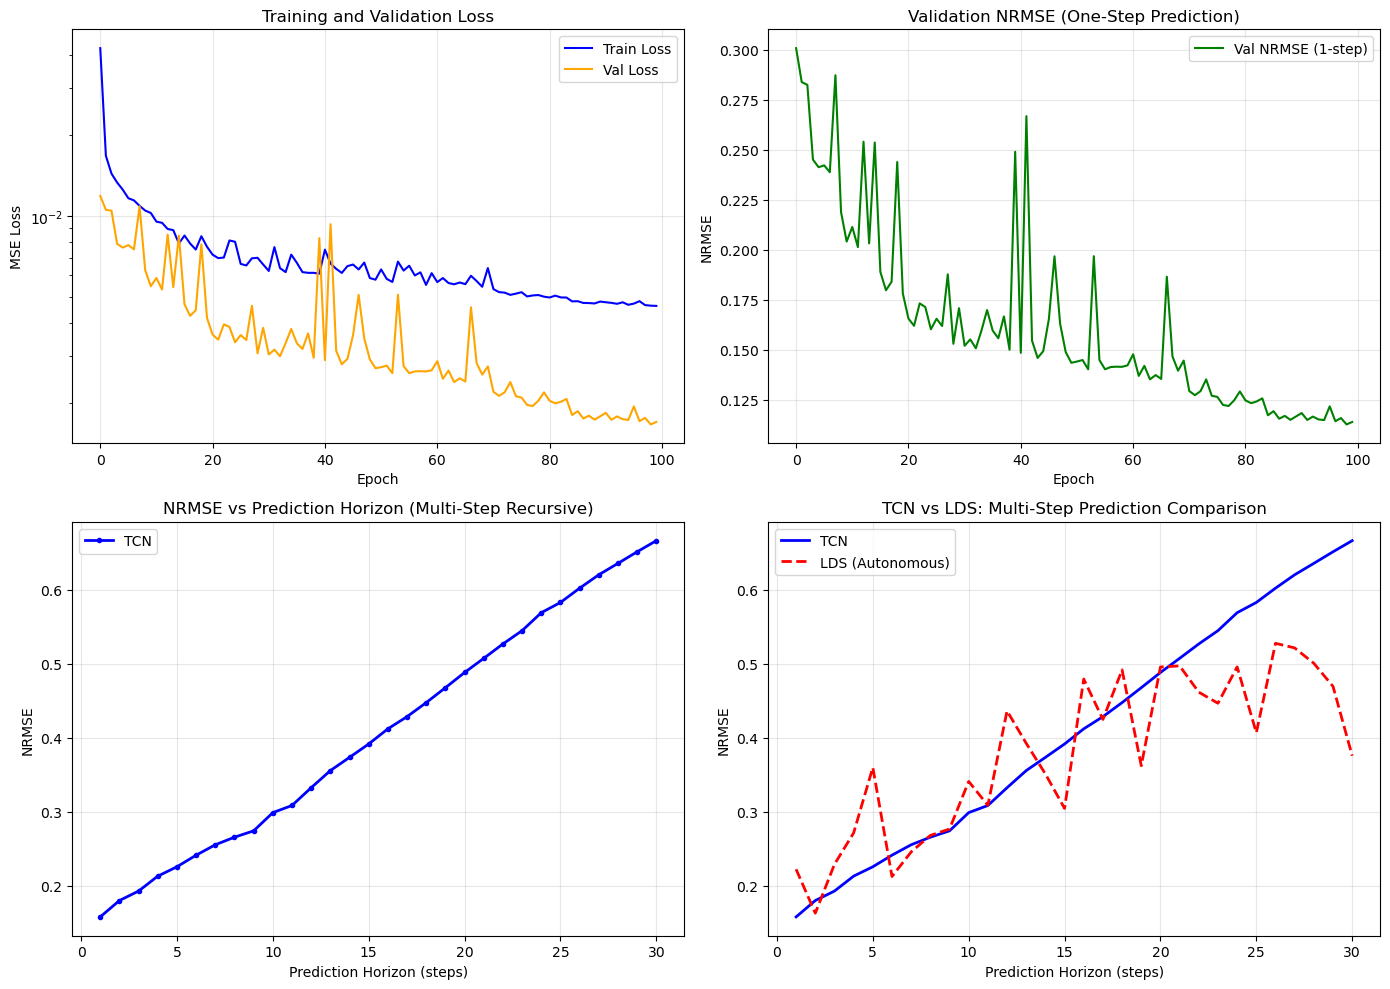

In [123]:
# --- Visualization: Training History and Comparison ---

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training/Validation Loss
ax1 = axes[0, 0]
ax1.plot(history['train_loss'], label='Train Loss', color='blue')
ax1.plot(history['val_loss'], label='Val Loss', color='orange')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Validation NRMSE (1-step)
ax2 = axes[0, 1]
ax2.plot(history['val_nrmse_1step'], label='Val NRMSE (1-step)', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('NRMSE')
ax2.set_title('Validation NRMSE (One-Step Prediction)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# NRMSE vs Horizon (Test Set)
ax3 = axes[1, 0]
horizons = np.arange(1, HORIZON + 1)
ax3.plot(horizons, test_metrics['nrmse_per_step'], 'b-', linewidth=2, marker='o', markersize=3, label='TCN')
ax3.set_xlabel('Prediction Horizon (steps)')
ax3.set_ylabel('NRMSE')
ax3.set_title('NRMSE vs Prediction Horizon (Multi-Step Recursive)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Compare with LDS (if available)
ax4 = axes[1, 1]
if 'metrics_auto_stim' in dir() and metrics_auto_stim is not None:
    # Convert LDS MSE to NRMSE for comparison (approximate)
    # NRMSE ≈ sqrt(MSE) / std(y)
    # We'll use the test targets std as normalization
    test_targets = test_metrics['targets']
    test_std = np.std(test_targets)
    
    lds_nrmse = np.sqrt(metrics_auto_stim['mse_per_step']) / test_std
    
    ax4.plot(horizons, test_metrics['nrmse_per_step'], 'b-', linewidth=2, label='TCN')
    ax4.plot(horizons[:len(lds_nrmse)], lds_nrmse, 'r--', linewidth=2, label='LDS (Autonomous)')
    ax4.set_xlabel('Prediction Horizon (steps)')
    ax4.set_ylabel('NRMSE')
    ax4.set_title('TCN vs LDS: Multi-Step Prediction Comparison')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'LDS metrics not available\nfor comparison', 
             ha='center', va='center', transform=ax4.transAxes, fontsize=12)
    ax4.set_title('TCN vs LDS Comparison (N/A)')

plt.tight_layout()
plt.show()

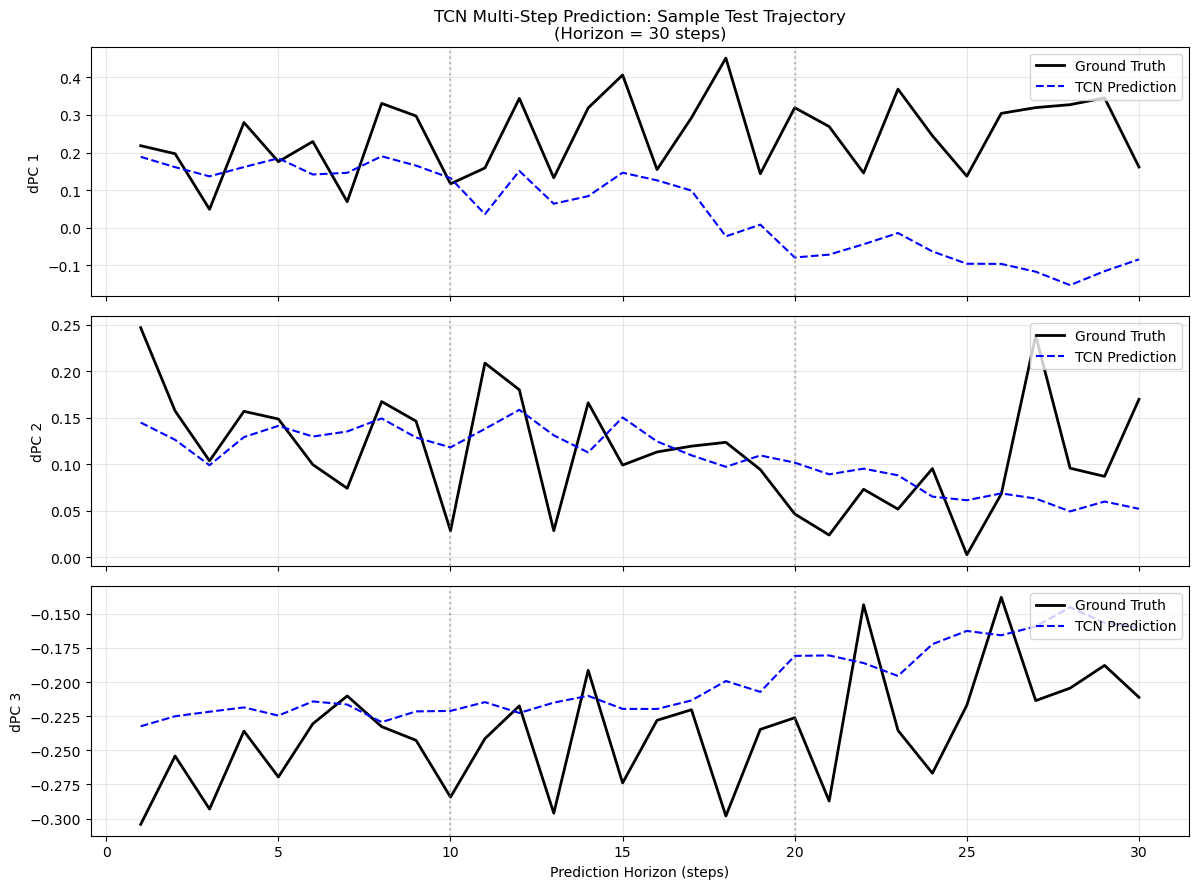


Per-dimension NRMSE for this sample:
  dPC 1: 2.5569
  dPC 2: 0.9846
  dPC 3: 1.2485
  dPC 4: 2.1444
  dPC 5: 1.4129


In [124]:
# --- Visualization: Sample Trajectory Prediction (TCN vs Ground Truth) ---

# Get a sample from test set
sample_batch = next(iter(test_loader_multistep))
sample_window, sample_targets, sample_future_stim = sample_batch

# Select first sample in batch
idx = 0
sample_window_single = sample_window[idx:idx+1].to(device)
sample_future_stim_single = sample_future_stim[idx:idx+1].to(device)
sample_target_single = sample_targets[idx].numpy()

# Predict trajectory
tcn_model.eval()
with torch.no_grad():
    pred_traj = tcn_model.predict_trajectory(
        sample_window_single, sample_future_stim_single, horizon=HORIZON
    )
pred_traj = pred_traj[0].cpu().numpy()  # (horizon, latent_dim)

# Plot first 3 latent dimensions
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
time_horizon = np.arange(1, HORIZON + 1)

for i, ax in enumerate(axes[:3]):
    ax.plot(time_horizon, sample_target_single[:, i], 'k-', linewidth=2, label='Ground Truth')
    ax.plot(time_horizon, pred_traj[:, i], 'b--', linewidth=1.5, label='TCN Prediction')
    ax.set_ylabel(f'dPC {i+1}')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.axvline(x=10, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(x=20, color='gray', linestyle=':', alpha=0.5)

axes[0].set_title(f'TCN Multi-Step Prediction: Sample Test Trajectory\n(Horizon = {HORIZON} steps)')
axes[-1].set_xlabel('Prediction Horizon (steps)')

plt.tight_layout()
plt.show()

# Compute per-dimension NRMSE for this sample
print("\nPer-dimension NRMSE for this sample:")
for i in range(LATENT_DIM):
    dim_nrmse = np.sqrt(np.mean((sample_target_single[:, i] - pred_traj[:, i])**2)) / np.std(sample_target_single[:, i])
    print(f"  dPC {i+1}: {dim_nrmse:.4f}")

Post-Stimulation Evaluation: Models Primed to Stim Onset

[INFO] Using filter_ps_time to find stimulation onset:
       Time axis range: [-7.967s, 6.000s]
       Stim onset index (t=0): 238 (time = -0.0333s)

Stimulation onset index: 238
TCN post-stim eval offset: 50 steps (1.667s after stim)
MLP prediction horizon: 30 steps (1.000s)
Trial length: 420 timesteps

SECTION 1: TCN One-Step Prediction Metrics



--- TCN One-Step Prediction (Test Set) ---

  PRE-STIMULATION (t=0 to t=238, time < 0s):
    MSE: 0.005036
    R²:  0.9165
    N samples: 7194

  POST-STIMULATION (t=288 to end, time > 1.633s):
    MSE: 0.004533
    R²:  0.9648
    N samples: 4323

SECTION 2: MLP Multi-Step Prediction (Primed at Stim Onset)

--- TCN+MLP Multi-Step Prediction (Primed at t=238, time=0s) ---
  Horizon: 30 steps post-stimulation
  Trials evaluated: 33
  Actual horizon: 30 steps

  OVERALL POST-STIM METRICS:
    MSE: 0.178812
    R²:  0.6873

  MSE per Horizon Step:
  Step |        MSE |       R²
  ------------------------------
     1 | 0.019032 | 0.5596
     5 | 0.265607 | 0.6619
    10 | 0.031243 | 0.9271
    15 | 0.028580 | 0.9396
    20 | 0.033857 | 0.9322
    25 | 0.158648 | -8.5773
    30 | 0.056654 | 0.3923

SECTION 3: Visualization - Primed Model Prediction vs Truth


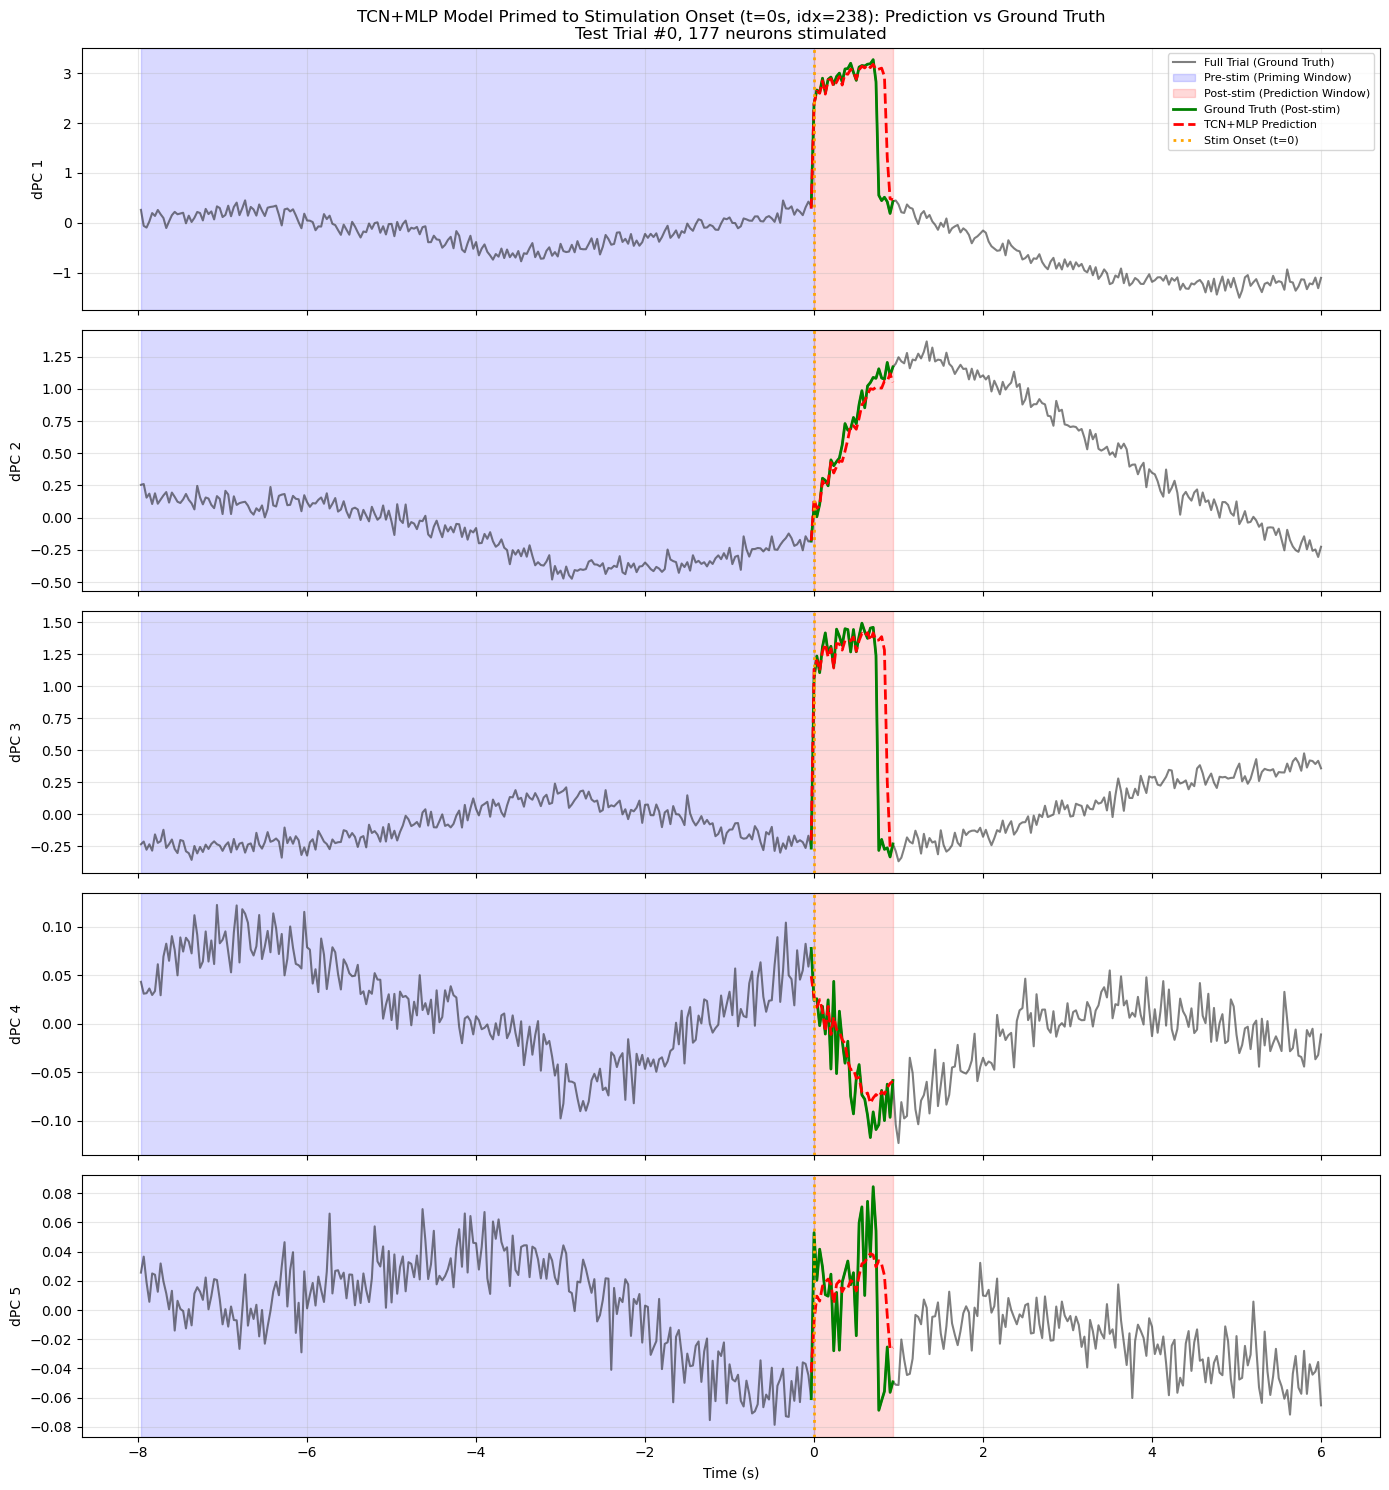

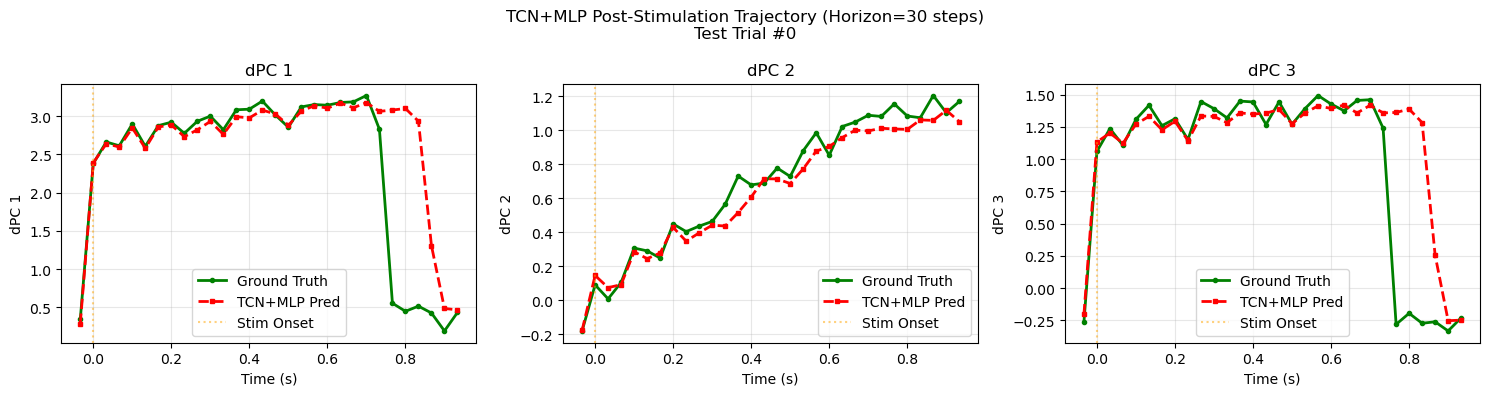


SECTION 4: TCN+MLP Performance vs Prediction Horizon


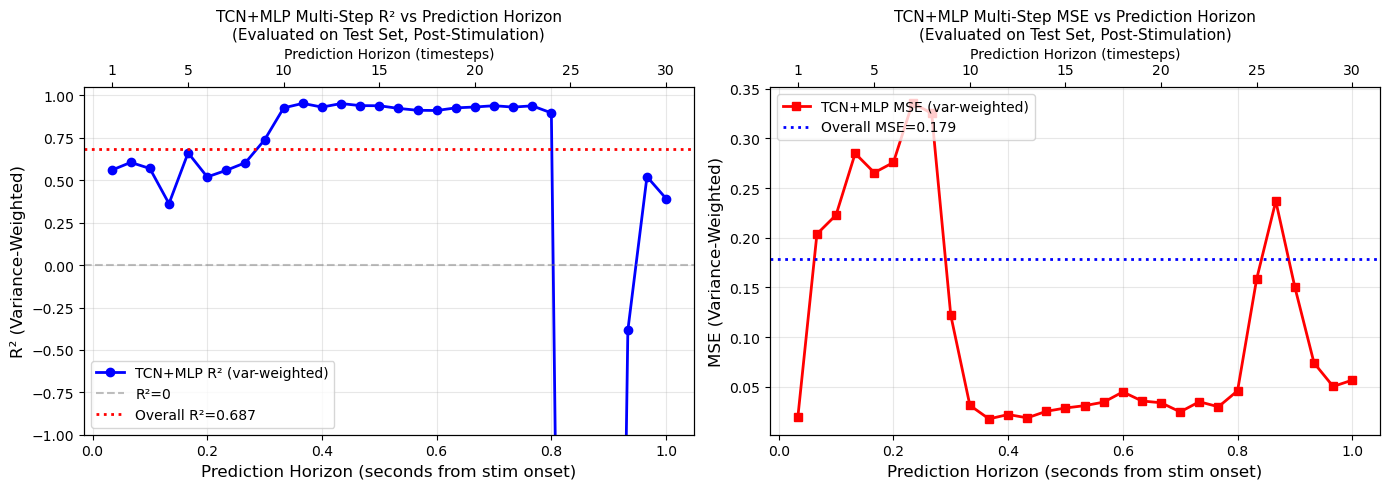


SUMMARY: Post-Stimulation Evaluation Metrics

Stimulation onset: index 238 (t = 0.0s)
Sampling frequency: 30.0 Hz (33.3 ms per step)

────────────────────────────────────────────────────────────────────────────────
MODEL: TCN Backbone (One-Step Prediction, z[t] → z[t+1])
Evaluates the TCN's ability to predict one timestep ahead using ground truth context
────────────────────────────────────────────────────────────────────────────────

Metric                                                  |        Value
----------------------------------------------------------------------
Pre-Stim MSE (t < 0s, baseline period)                  |     0.005036
Pre-Stim R² (t < 0s, baseline period)                   |       0.9165
Post-Stim MSE (t > 1.67s, stim+50 steps)                |     0.004533
Post-Stim R² (t > 1.67s, stim+50 steps)                 |       0.9648

────────────────────────────────────────────────────────────────────────────────
MODEL: TCN+MLP (Multi-Step Open-Loop Prediction)
Pri

In [125]:
# --- Post-Stimulation Evaluation: Models Primed to Stim Onset ---
"""
Evaluation Strategy:
1. TCN One-Step Metrics:
   - Pre-stimulation: timepoints 0 to stim_onset_idx (baseline)
   - Post-stimulation: from stim_onset_idx + 50 until end of trial
   
2. MLP Multi-Step Metrics:
   - Prime the model with a window ending at stim_onset_idx
   - Predict horizon up to 30 steps AFTER photostimulation
   - Compute MSE and R² only on these post-stim predictions

3. Visualization:
   - Model primed up to stim onset
   - Show prediction trajectory vs ground truth after photostimulation
"""

import torch
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

print("="*70)
print("Post-Stimulation Evaluation: Models Primed to Stim Onset")
print("="*70)

# --- Find the CORRECT stimulation onset index using filter_ps_time ---
# filter_ps_time is a time axis aligned to stimulation, where t=0 is stim onset
time_axis = np.asarray(s0['filter_ps_time'])
stim_onset_idx = int(np.argmin(np.abs(time_axis - 0))) - 1
print(f"\n[INFO] Using filter_ps_time to find stimulation onset:")
print(f"       Time axis range: [{time_axis.min():.3f}s, {time_axis.max():.3f}s]")
print(f"       Stim onset index (t=0): {stim_onset_idx} (time = {time_axis[stim_onset_idx]:.4f}s)")

# --- Parameters ---
POST_STIM_OFFSET = 50  # TCN one-step eval starts 50 steps after stim onset
MLP_HORIZON = 30       # MLP multi-step horizon after stim

# Calculate time in seconds for the offset
freq = s0['frequency']  # Hz
time_per_step = 1.0 / freq
post_stim_offset_time = POST_STIM_OFFSET * time_per_step
mlp_horizon_time = MLP_HORIZON * time_per_step

print(f"\nStimulation onset index: {stim_onset_idx}")
print(f"TCN post-stim eval offset: {POST_STIM_OFFSET} steps ({post_stim_offset_time:.3f}s after stim)")
print(f"MLP prediction horizon: {MLP_HORIZON} steps ({mlp_horizon_time:.3f}s)")
print(f"Trial length: {T_time} timesteps")

# ===================================================================
# SECTION 1: TCN One-Step Prediction Metrics (Pre-stim vs Post-stim)
# ===================================================================
print(f"\n{'='*70}")
print("SECTION 1: TCN One-Step Prediction Metrics")
print("="*70)

def compute_tcn_one_step_metrics_by_region(model, Z_trials, V_trials, 
                                            pre_stim_end_idx, post_stim_start_idx,
                                            device, V_max):
    """
    Compute TCN one-step prediction MSE and R² for:
    - Pre-stimulation region: [WINDOW_SIZE, pre_stim_end_idx)
    - Post-stimulation region: [post_stim_start_idx, T-1)
    
    V_trials shape: (n_trials, T, n_cells) - vector stimulus format
    """
    model.eval()
    n_trials, T, latent_dim = Z_trials.shape
    
    # Normalize V - shape stays (n_trials, T, n_cells)
    V_normalized = V_trials / V_max if V_max > 0 else V_trials
    # V is already 3D: (n_trials, T, n_cells) - no need to add newaxis
    
    pre_stim_preds = []
    pre_stim_targets = []
    post_stim_preds = []
    post_stim_targets = []
    
    with torch.no_grad():
        for trial_idx in range(n_trials):
            Z_trial = Z_trials[trial_idx]  # (T, latent_dim)
            V_trial = V_normalized[trial_idx]  # (T, n_cells) - VECTOR now!
            
            # --- Pre-stimulation predictions ---
            # Window from t-WINDOW_SIZE to t, predict t+1
            for t in range(WINDOW_SIZE, pre_stim_end_idx):
                if t + 1 >= T:
                    continue
                z_window = Z_trial[t - WINDOW_SIZE:t]  # (window, latent)
                v_window = V_trial[t - WINDOW_SIZE:t]  # (window, n_cells)
                
                window = np.concatenate([z_window, v_window], axis=-1)
                window_tensor = torch.from_numpy(window.astype(np.float32)).unsqueeze(0).to(device)
                
                pred = model(window_tensor).cpu().numpy().squeeze()
                target = Z_trial[t]
                
                pre_stim_preds.append(pred)
                pre_stim_targets.append(target)
            
            # --- Post-stimulation predictions ---
            for t in range(post_stim_start_idx, T - 1):
                if t < WINDOW_SIZE:
                    continue
                z_window = Z_trial[t - WINDOW_SIZE:t]
                v_window = V_trial[t - WINDOW_SIZE:t]  # (window, n_cells)
                
                window = np.concatenate([z_window, v_window], axis=-1)
                window_tensor = torch.from_numpy(window.astype(np.float32)).unsqueeze(0).to(device)
                
                pred = model(window_tensor).cpu().numpy().squeeze()
                target = Z_trial[t]
                
                post_stim_preds.append(pred)
                post_stim_targets.append(target)
    
    # Compute metrics (variance-weighted)
    results = {}
    
    if len(pre_stim_preds) > 0:
        pre_stim_preds = np.array(pre_stim_preds)
        pre_stim_targets = np.array(pre_stim_targets)
        
        # Variance-weighted MSE
        variances = np.var(pre_stim_targets, axis=0)
        variances = np.maximum(variances, 1e-10)
        weights = variances / np.sum(variances)
        mse_per_dim = np.mean((pre_stim_targets - pre_stim_preds) ** 2, axis=0)
        results['pre_stim_mse'] = np.sum(weights * mse_per_dim)
        
        # Variance-weighted R²
        results['pre_stim_r2'] = r2_score(pre_stim_targets, pre_stim_preds, multioutput='variance_weighted')
        results['pre_stim_n_samples'] = len(pre_stim_preds)
    else:
        results['pre_stim_mse'] = np.nan
        results['pre_stim_r2'] = np.nan
        results['pre_stim_n_samples'] = 0
    
    if len(post_stim_preds) > 0:
        post_stim_preds = np.array(post_stim_preds)
        post_stim_targets = np.array(post_stim_targets)
        
        # Variance-weighted MSE
        variances = np.var(post_stim_targets, axis=0)
        variances = np.maximum(variances, 1e-10)
        weights = variances / np.sum(variances)
        mse_per_dim = np.mean((post_stim_targets - post_stim_preds) ** 2, axis=0)
        results['post_stim_mse'] = np.sum(weights * mse_per_dim)
        
        # Variance-weighted R²
        results['post_stim_r2'] = r2_score(post_stim_targets, post_stim_preds, multioutput='variance_weighted')
        results['post_stim_n_samples'] = len(post_stim_preds)
    else:
        results['post_stim_mse'] = np.nan
        results['post_stim_r2'] = np.nan
        results['post_stim_n_samples'] = 0
    
    return results

# Compute TCN one-step metrics on test set
tcn_one_step_metrics = compute_tcn_one_step_metrics_by_region(
    tcn_model, Z_test, V_test,
    pre_stim_end_idx=stim_onset_idx,
    post_stim_start_idx=stim_onset_idx + POST_STIM_OFFSET,
    device=device,
    V_max=V_max
)

print(f"\n--- TCN One-Step Prediction (Test Set) ---")
print(f"\n  PRE-STIMULATION (t=0 to t={stim_onset_idx}, time < 0s):")
print(f"    MSE: {tcn_one_step_metrics['pre_stim_mse']:.6f}")
print(f"    R²:  {tcn_one_step_metrics['pre_stim_r2']:.4f}")
print(f"    N samples: {tcn_one_step_metrics['pre_stim_n_samples']}")

print(f"\n  POST-STIMULATION (t={stim_onset_idx + POST_STIM_OFFSET} to end, time > {time_axis[stim_onset_idx + POST_STIM_OFFSET]:.3f}s):")
print(f"    MSE: {tcn_one_step_metrics['post_stim_mse']:.6f}")
print(f"    R²:  {tcn_one_step_metrics['post_stim_r2']:.4f}")
print(f"    N samples: {tcn_one_step_metrics['post_stim_n_samples']}")


# ===================================================================
# SECTION 2: MLP Multi-Step Prediction (Primed to Stim, Horizon=30)
# ===================================================================
print(f"\n{'='*70}")
print("SECTION 2: MLP Multi-Step Prediction (Primed at Stim Onset)")
print("="*70)

def compute_mlp_multistep_post_stim(model, Z_trials, V_trials, 
                                     stim_onset_idx, horizon, window_size,
                                     device, V_max):
    """
    Prime the MLP model with a window ending at stim_onset_idx, then predict
    'horizon' steps forward. Evaluate MSE and R² on these post-stim predictions.
    
    V_trials shape: (n_trials, T, n_cells) - vector stimulus format
    """
    model.eval()
    n_trials, T, latent_dim = Z_trials.shape
    
    # Normalize V - shape stays (n_trials, T, n_cells)
    V_normalized = V_trials / V_max if V_max > 0 else V_trials
    # V is already 3D: (n_trials, T, n_cells) - no need to add newaxis
    
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for trial_idx in range(n_trials):
            Z_trial = Z_trials[trial_idx]
            V_trial = V_normalized[trial_idx]  # (T, n_cells) - VECTOR now!
            
            # Check if we have enough data
            if stim_onset_idx < window_size:
                continue
            if stim_onset_idx + horizon > T:
                # Truncate horizon if needed
                actual_horizon = T - stim_onset_idx
            else:
                actual_horizon = horizon
            
            if actual_horizon < 1:
                continue
            
            # Build initial window ending at stim_onset_idx
            # Window: [stim_onset_idx - window_size : stim_onset_idx]
            z_window = Z_trial[stim_onset_idx - window_size:stim_onset_idx]  # (window, latent)
            v_window = V_trial[stim_onset_idx - window_size:stim_onset_idx]  # (window, n_cells)
            
            initial_window = np.concatenate([z_window, v_window], axis=-1)
            initial_window = torch.from_numpy(initial_window.astype(np.float32)).unsqueeze(0).to(device)
            
            # Future stimulation for prediction - already (horizon, n_cells)
            future_stim = V_trial[stim_onset_idx:stim_onset_idx + actual_horizon]
            future_stim = torch.from_numpy(future_stim.astype(np.float32)).unsqueeze(0).to(device)
            
            # Predict trajectory
            pred_traj = model.predict_trajectory(initial_window, future_stim, horizon=actual_horizon)
            pred_traj = pred_traj[0].cpu().numpy()  # (actual_horizon, latent_dim)
            
            # Ground truth
            ground_truth = Z_trial[stim_onset_idx:stim_onset_idx + actual_horizon]
            
            all_predictions.append(pred_traj)
            all_targets.append(ground_truth)
    
    if len(all_predictions) == 0:
        return None
    
    # Stack all predictions and targets
    # Handle variable horizon lengths by padding or using the minimum
    import builtins
    min_horizon = builtins.min([p.shape[0] for p in all_predictions])
    
    all_predictions_arr = np.array([p[:min_horizon] for p in all_predictions])  # (n_trials, horizon, latent)
    all_targets_arr = np.array([t[:min_horizon] for t in all_targets])
    
    # Compute metrics per horizon step (variance-weighted)
    mse_per_step = []
    r2_per_step = []
    
    for h in range(min_horizon):
        preds_h = all_predictions_arr[:, h, :]  # (n_trials, latent_dim)
        targets_h = all_targets_arr[:, h, :]
        
        # Variance-weighted MSE: weight each component by its variance
        variances = np.var(targets_h, axis=0)
        variances = np.maximum(variances, 1e-10)  # Avoid division by zero
        weights = variances / np.sum(variances)
        mse_per_dim = np.mean((targets_h - preds_h) ** 2, axis=0)
        mse_h = np.sum(weights * mse_per_dim)
        
        # Variance-weighted R²
        r2_h = r2_score(targets_h, preds_h, multioutput='variance_weighted')
        
        mse_per_step.append(mse_h)
        r2_per_step.append(r2_h)
    
    # Overall metrics across all horizons (variance-weighted)
    targets_flat = all_targets_arr.reshape(-1, latent_dim)
    preds_flat = all_predictions_arr.reshape(-1, latent_dim)
    
    # Variance-weighted MSE
    variances_overall = np.var(targets_flat, axis=0)
    variances_overall = np.maximum(variances_overall, 1e-10)
    weights_overall = variances_overall / np.sum(variances_overall)
    mse_per_dim_overall = np.mean((targets_flat - preds_flat) ** 2, axis=0)
    overall_mse = np.sum(weights_overall * mse_per_dim_overall)
    
    # Variance-weighted R²
    overall_r2 = r2_score(targets_flat, preds_flat, multioutput='variance_weighted')
    
    return {
        'mse_per_step': np.array(mse_per_step),
        'r2_per_step': np.array(r2_per_step),
        'overall_mse': overall_mse,
        'overall_r2': overall_r2,
        'n_trials': len(all_predictions),
        'horizon_evaluated': min_horizon,
        'all_predictions': all_predictions_arr,
        'all_targets': all_targets_arr
    }

# Compute MLP multi-step metrics (primed at stim onset)
mlp_post_stim_metrics = compute_mlp_multistep_post_stim(
    tcn_model, Z_test, V_test,
    stim_onset_idx=stim_onset_idx,
    horizon=MLP_HORIZON,
    window_size=WINDOW_SIZE,
    device=device,
    V_max=V_max
)

print(f"\n--- TCN+MLP Multi-Step Prediction (Primed at t={stim_onset_idx}, time=0s) ---")
print(f"  Horizon: {MLP_HORIZON} steps post-stimulation")
print(f"  Trials evaluated: {mlp_post_stim_metrics['n_trials']}")
print(f"  Actual horizon: {mlp_post_stim_metrics['horizon_evaluated']} steps")
print(f"\n  OVERALL POST-STIM METRICS:")
print(f"    MSE: {mlp_post_stim_metrics['overall_mse']:.6f}")
print(f"    R²:  {mlp_post_stim_metrics['overall_r2']:.4f}")

print(f"\n  MSE per Horizon Step:")
print(f"  {'Step':>4} | {'MSE':>10} | {'R²':>8}")
print("  " + "-" * 30)
for h in [1, 5, 10, 15, 20, 25, 30]:
    if h <= mlp_post_stim_metrics['horizon_evaluated']:
        print(f"  {h:4d} | {mlp_post_stim_metrics['mse_per_step'][h-1]:.6f} | {mlp_post_stim_metrics['r2_per_step'][h-1]:.4f}")


# ===================================================================
# SECTION 3: Visualization - Prediction Trajectory vs Ground Truth
# ===================================================================
print(f"\n{'='*70}")
print("SECTION 3: Visualization - Primed Model Prediction vs Truth")
print("="*70)

# Select a sample trial with stimulation for visualization
# V_test shape: (n_trials, T, n_cells) - check if any neuron was stimulated
stim_trial_mask = V_test.max(axis=(1, 2)) > 0  # max over time AND neurons
stim_trial_indices = np.where(stim_trial_mask)[0]

if len(stim_trial_indices) == 0:
    print("No stimulation trials in test set for visualization.")
else:
    # Pick first stim trial
    viz_trial_idx = stim_trial_indices[0]
    
    Z_viz = Z_test[viz_trial_idx]  # (T, latent_dim)
    V_viz = V_test[viz_trial_idx]  # (T, n_cells) - VECTOR now!
    V_viz_normalized = V_viz / V_max if V_max > 0 else V_viz
    
    # Build primed window - NO np.newaxis since V is already (T, n_cells)
    z_window_viz = Z_viz[stim_onset_idx - WINDOW_SIZE:stim_onset_idx]  # (window, latent)
    v_window_viz = V_viz_normalized[stim_onset_idx - WINDOW_SIZE:stim_onset_idx]  # (window, n_cells)
    
    initial_window_viz = np.concatenate([z_window_viz, v_window_viz], axis=-1)
    initial_window_viz = torch.from_numpy(initial_window_viz.astype(np.float32)).unsqueeze(0).to(device)
    
    # Future stim - NO np.newaxis since V is already (T, n_cells)
    import builtins
    horizon_viz = builtins.min(MLP_HORIZON, T_time - stim_onset_idx)
    future_stim_viz = V_viz_normalized[stim_onset_idx:stim_onset_idx + horizon_viz]  # (horizon, n_cells)
    future_stim_viz = torch.from_numpy(future_stim_viz.astype(np.float32)).unsqueeze(0).to(device)
    
    # Predict
    tcn_model.eval()
    with torch.no_grad():
        pred_viz = tcn_model.predict_trajectory(initial_window_viz, future_stim_viz, horizon=horizon_viz)
    pred_viz = pred_viz[0].cpu().numpy()
    
    # Ground truth
    truth_viz = Z_viz[stim_onset_idx:stim_onset_idx + horizon_viz]
    
    # Time axis for plotting (use actual time in seconds)
    time_post_stim = time_axis[stim_onset_idx:stim_onset_idx + horizon_viz]
    time_full = time_axis
    
    # --- Plot: Full trajectory with priming region highlighted ---
    fig, axes = plt.subplots(LATENT_DIM, 1, figsize=(14, 3 * LATENT_DIM), sharex=True)
    
    for dim in range(LATENT_DIM):
        ax = axes[dim]
        
        # Full ground truth trajectory
        ax.plot(time_full, Z_viz[:, dim], 'k-', linewidth=1.5, alpha=0.5, label='Full Trial (Ground Truth)')
        
        # Highlight pre-stim (priming) region
        ax.axvspan(time_full[0], 0, alpha=0.15, color='blue', label='Pre-stim (Priming Window)')
        
        # Highlight post-stim evaluation region  
        ax.axvspan(0, time_axis[stim_onset_idx + horizon_viz - 1], alpha=0.15, color='red', label='Post-stim (Prediction Window)')
        
        # Ground truth post-stim
        ax.plot(time_post_stim, truth_viz[:, dim], 
                'g-', linewidth=2, label='Ground Truth (Post-stim)')
        
        # Prediction post-stim
        ax.plot(time_post_stim, pred_viz[:, dim], 
                'r--', linewidth=2, label='TCN+MLP Prediction')
        
        # Mark stim onset (t=0)
        ax.axvline(x=0, color='orange', linestyle=':', linewidth=2, label='Stim Onset (t=0)')
        
        ax.set_ylabel(f'dPC {dim+1}')
        ax.grid(True, alpha=0.3)
        
        if dim == 0:
            ax.legend(loc='upper right', fontsize=8)
    
    # Show number of neurons stimulated
    n_neurons_viz = (V_viz.any(axis=0)).sum()
    axes[0].set_title(f'TCN+MLP Model Primed to Stimulation Onset (t=0s, idx={stim_onset_idx}): Prediction vs Ground Truth\n'
                      f'Test Trial #{viz_trial_idx}, {n_neurons_viz} neurons stimulated')
    axes[-1].set_xlabel('Time (s)')
    
    plt.tight_layout()
    plt.show()
    
    # --- Plot: Zoomed post-stim prediction ---
    fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
    
    for dim, ax in enumerate(axes2[:3]):
        ax.plot(time_post_stim, truth_viz[:, dim], 'g-', linewidth=2, marker='o', markersize=3, label='Ground Truth')
        ax.plot(time_post_stim, pred_viz[:, dim], 'r--', linewidth=2, marker='s', markersize=3, label='TCN+MLP Pred')
        ax.set_xlabel(f'Time (s)')
        ax.set_ylabel(f'dPC {dim+1}')
        ax.set_title(f'dPC {dim+1}')
        ax.axvline(x=0, color='orange', linestyle=':', alpha=0.5, label='Stim Onset')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    fig2.suptitle(f'TCN+MLP Post-Stimulation Trajectory (Horizon={horizon_viz} steps)\nTest Trial #{viz_trial_idx}')
    plt.tight_layout()
    plt.show()


# ===================================================================
# SECTION 4: TCN+MLP Multi-Step R² and MSE vs Prediction Horizon
# ===================================================================
print(f"\n{'='*70}")
print("SECTION 4: TCN+MLP Performance vs Prediction Horizon")
print("="*70)

# Create time axis for horizon steps (in seconds from stim onset)
horizon_steps = np.arange(1, mlp_post_stim_metrics['horizon_evaluated'] + 1)
horizon_time_sec = horizon_steps * time_per_step

fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot R² vs Horizon ---
ax1.plot(horizon_time_sec, mlp_post_stim_metrics['r2_per_step'], 
         'b-o', linewidth=2, markersize=6, label='TCN+MLP R² (var-weighted)')
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='R²=0')
ax1.axhline(y=mlp_post_stim_metrics['overall_r2'], color='r', linestyle=':', 
            linewidth=2, label=f'Overall R²={mlp_post_stim_metrics["overall_r2"]:.3f}')
ax1.set_xlabel('Prediction Horizon (seconds from stim onset)', fontsize=12)
ax1.set_ylabel('R² (Variance-Weighted)', fontsize=12)
ax1.set_title('TCN+MLP Multi-Step R² vs Prediction Horizon\n(Evaluated on Test Set, Post-Stimulation)', fontsize=11)
ax1.legend(loc='lower left')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([-1, 1.05])  # Clip for visibility

# Add secondary x-axis for steps
ax1_steps = ax1.twiny()
ax1_steps.set_xlim(ax1.get_xlim())
step_ticks = [1, 5, 10, 15, 20, 25, 30]
step_tick_positions = [s * time_per_step for s in step_ticks if s <= mlp_post_stim_metrics['horizon_evaluated']]
ax1_steps.set_xticks(step_tick_positions)
ax1_steps.set_xticklabels([str(s) for s in step_ticks[:len(step_tick_positions)]])
ax1_steps.set_xlabel('Prediction Horizon (timesteps)', fontsize=10)

# --- Plot MSE vs Horizon ---
ax2.plot(horizon_time_sec, mlp_post_stim_metrics['mse_per_step'], 
         'r-s', linewidth=2, markersize=6, label='TCN+MLP MSE (var-weighted)')
ax2.axhline(y=mlp_post_stim_metrics['overall_mse'], color='b', linestyle=':', 
            linewidth=2, label=f'Overall MSE={mlp_post_stim_metrics["overall_mse"]:.3f}')
ax2.set_xlabel('Prediction Horizon (seconds from stim onset)', fontsize=12)
ax2.set_ylabel('MSE (Variance-Weighted)', fontsize=12)
ax2.set_title('TCN+MLP Multi-Step MSE vs Prediction Horizon\n(Evaluated on Test Set, Post-Stimulation)', fontsize=11)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# Add secondary x-axis for steps
ax2_steps = ax2.twiny()
ax2_steps.set_xlim(ax2.get_xlim())
ax2_steps.set_xticks(step_tick_positions)
ax2_steps.set_xticklabels([str(s) for s in step_ticks[:len(step_tick_positions)]])
ax2_steps.set_xlabel('Prediction Horizon (timesteps)', fontsize=10)

plt.tight_layout()
plt.show()


# ===================================================================
# SUMMARY TABLE (Improved Labels)
# ===================================================================
print(f"\n{'='*80}")
print("SUMMARY: Post-Stimulation Evaluation Metrics")
print("="*80)
print(f"\nStimulation onset: index {stim_onset_idx} (t = 0.0s)")
print(f"Sampling frequency: {freq:.1f} Hz ({time_per_step*1000:.1f} ms per step)")

print(f"\n{'─'*80}")
print("MODEL: TCN Backbone (One-Step Prediction, z[t] → z[t+1])")
print("Evaluates the TCN's ability to predict one timestep ahead using ground truth context")
print(f"{'─'*80}")
print(f"\n{'Metric':<55} | {'Value':>12}")
print("-" * 70)
print(f"{'Pre-Stim MSE (t < 0s, baseline period)':<55} | {tcn_one_step_metrics['pre_stim_mse']:>12.6f}")
print(f"{'Pre-Stim R² (t < 0s, baseline period)':<55} | {tcn_one_step_metrics['pre_stim_r2']:>12.4f}")
print(f"{'Post-Stim MSE (t > {0:.2f}s, stim+{1} steps)'.format(post_stim_offset_time, POST_STIM_OFFSET):<55} | {tcn_one_step_metrics['post_stim_mse']:>12.6f}")
print(f"{'Post-Stim R² (t > {0:.2f}s, stim+{1} steps)'.format(post_stim_offset_time, POST_STIM_OFFSET):<55} | {tcn_one_step_metrics['post_stim_r2']:>12.4f}")

print(f"\n{'─'*80}")
print("MODEL: TCN+MLP (Multi-Step Open-Loop Prediction)")
print("Primed with pre-stim context, then predicts trajectory without ground truth feedback")
print(f"Evaluation window: t=0s to t={mlp_horizon_time:.2f}s ({MLP_HORIZON} steps post-stim)")
print(f"{'─'*80}")
print(f"\n{'Metric':<55} | {'Value':>12}")
print("-" * 70)
print(f"{'Overall MSE (H=1 to H={0}, all horizons)'.format(MLP_HORIZON):<55} | {mlp_post_stim_metrics['overall_mse']:>12.6f}")
print(f"{'Overall R² (H=1 to H={0}, all horizons)'.format(MLP_HORIZON):<55} | {mlp_post_stim_metrics['overall_r2']:>12.4f}")
print("-" * 70)
h10_idx = builtins.min(9, len(mlp_post_stim_metrics['mse_per_step'])-1)
print(f"{'MSE @ H=1  (t={0:.3f}s, 1 step after stim)'.format(1*time_per_step):<55} | {mlp_post_stim_metrics['mse_per_step'][0]:>12.6f}")
print(f"{'R²  @ H=1  (t={0:.3f}s, 1 step after stim)'.format(1*time_per_step):<55} | {mlp_post_stim_metrics['r2_per_step'][0]:>12.4f}")
print(f"{'MSE @ H=10 (t={0:.3f}s, 10 steps after stim)'.format(10*time_per_step):<55} | {mlp_post_stim_metrics['mse_per_step'][h10_idx]:>12.6f}")
print(f"{'R²  @ H=10 (t={0:.3f}s, 10 steps after stim)'.format(10*time_per_step):<55} | {mlp_post_stim_metrics['r2_per_step'][h10_idx]:>12.4f}")
print(f"{'MSE @ H=30 (t={0:.3f}s, 30 steps after stim)'.format(30*time_per_step):<55} | {mlp_post_stim_metrics['mse_per_step'][-1]:>12.6f}")
print(f"{'R²  @ H=30 (t={0:.3f}s, 30 steps after stim)'.format(30*time_per_step):<55} | {mlp_post_stim_metrics['r2_per_step'][-1]:>12.4f}")

print(f"\n{'─'*80}")
print("Notes:")
print("  • All metrics are variance-weighted across latent dimensions (5 dPCA components)")
print("  • TCN one-step: Uses sliding window with ground truth, predicts next step")
print("  • TCN+MLP multi-step: Open-loop rollout from stim onset, no ground truth feedback")
print("  • Test set: 33 trials (chronological 80/20 split)")
print("  • Stimulus input: vector of {0} neurons (which neurons were stimulated)".format(V_test.shape[2]))
print(f"{'─'*80}")

No trial found with actual_stim_onset >= WINDOW_SIZE (20)
Falling back to stim_onset_idx (from filter_ps_time)
Timing diagnostic (Trial 0):
  stim_onset_idx (from filter_ps_time t=0): 238
  actual_stim_onset (from V array):         0
  Offset: -238 timesteps
  WINDOW_SIZE required: 20
  Using true_stim_onset: 238


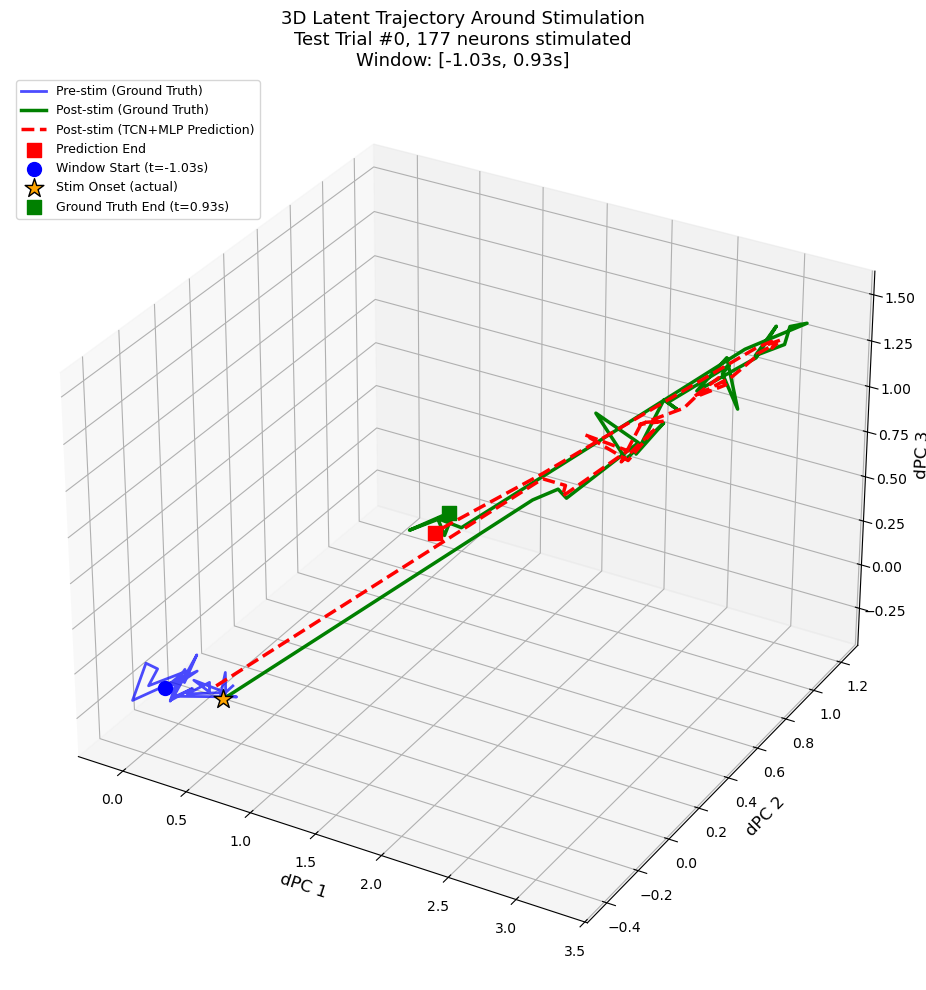


Timing summary:
  Pre-stim window:  t = [-1.033s, -0.067s] (30 steps)
  Actual stim onset: t = -0.033s (index 238)
  Post-stim window: t = [-0.033s, 0.933s] (30 steps)

  Model input: z[t-20:t] and v[t-20:t] where t=actual_stim_onset
  Model receives future stim: v[t:t+30]
  Model predicts: z[t:t+30]


In [126]:
# --- 3D Plot: dPCA Trajectory Around Stimulation (Single Trial) ---
from mpl_toolkits.mplot3d import Axes3D
import builtins

# Parameters for visualization window
PRE_STIM_WINDOW = 30   # timesteps before stim onset to show
POST_STIM_WINDOW = 30  # timesteps after stim onset (prediction horizon)

# Get a stim trial
stim_trial_mask_3d = V_test.max(axis=(1, 2)) > 0
stim_trial_indices_3d = np.where(stim_trial_mask_3d)[0]

if len(stim_trial_indices_3d) > 0:
    # Find a trial where actual stim onset has enough history for TCN
    viz_idx = None
    true_stim_onset = None
    
    for trial_idx in stim_trial_indices_3d:
        V_trial_check = V_test[trial_idx]
        stim_active_per_time = V_trial_check.sum(axis=1)
        actual_stim_times = np.where(stim_active_per_time > 0)[0]
        
        if len(actual_stim_times) > 0:
            onset = actual_stim_times[0]
            # Need at least WINDOW_SIZE history for TCN and some post-stim room
            if onset >= WINDOW_SIZE and onset + POST_STIM_WINDOW <= T_time:
                viz_idx = trial_idx
                true_stim_onset = onset
                break
    
    if viz_idx is None:
        print(f"No trial found with actual_stim_onset >= WINDOW_SIZE ({WINDOW_SIZE})")
        print("Falling back to stim_onset_idx (from filter_ps_time)")
        viz_idx = stim_trial_indices_3d[0]
        true_stim_onset = stim_onset_idx
    
    Z_trial_3d = Z_test[viz_idx]  # (T, latent_dim)
    V_trial_3d = V_test[viz_idx]  # (T, n_cells)
    V_trial_3d_norm = V_trial_3d / V_max if V_max > 0 else V_trial_3d
    
    # Diagnostic: compare filter_ps_time onset vs actual onset for this trial
    stim_active_per_time = V_trial_3d.sum(axis=1)
    actual_stim_times = np.where(stim_active_per_time > 0)[0]
    actual_stim_onset = actual_stim_times[0] if len(actual_stim_times) > 0 else stim_onset_idx
    
    print(f"Timing diagnostic (Trial {viz_idx}):")
    print(f"  stim_onset_idx (from filter_ps_time t=0): {stim_onset_idx}")
    print(f"  actual_stim_onset (from V array):         {actual_stim_onset}")
    print(f"  Offset: {actual_stim_onset - stim_onset_idx} timesteps")
    print(f"  WINDOW_SIZE required: {WINDOW_SIZE}")
    print(f"  Using true_stim_onset: {true_stim_onset}")
    
    # Define the window around stimulation (use builtins.max/min to avoid numpy override)
    pre_start = builtins.max(0, true_stim_onset - PRE_STIM_WINDOW)
    post_end = builtins.min(T_time, true_stim_onset + POST_STIM_WINDOW)
    
    # Ground truth: pre-stim + post-stim
    Z_pre_stim_3d = Z_trial_3d[pre_start:true_stim_onset]  # Before stim
    Z_post_stim_3d = Z_trial_3d[true_stim_onset:post_end]   # After stim (ground truth)
    
    # Get model prediction (primed at stim onset)
    # Ensure window slicing is valid
    window_start = true_stim_onset - WINDOW_SIZE
    if window_start < 0:
        print(f"\nWARNING: Not enough history for TCN window. window_start={window_start}")
        print("Skipping TCN prediction, only showing ground truth.")
        Z_pred_3d = None
    else:
        z_window_3d = Z_trial_3d[window_start:true_stim_onset]
        v_window_3d = V_trial_3d_norm[window_start:true_stim_onset]
        
        initial_window_3d = np.concatenate([z_window_3d, v_window_3d], axis=-1)
        initial_window_3d_t = torch.from_numpy(initial_window_3d.astype(np.float32)).unsqueeze(0).to(device)
        
        horizon_3d = post_end - true_stim_onset
        future_stim_3d = V_trial_3d_norm[true_stim_onset:post_end]
        future_stim_3d_t = torch.from_numpy(future_stim_3d.astype(np.float32)).unsqueeze(0).to(device)
        
        tcn_model.eval()
        with torch.no_grad():
            Z_pred_3d = tcn_model.predict_trajectory(initial_window_3d_t, future_stim_3d_t, horizon=horizon_3d)
        Z_pred_3d = Z_pred_3d[0].cpu().numpy()  # (horizon, latent_dim)
    
    # --- Create 3D Plot ---
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot pre-stim trajectory (ground truth) - blue
    ax.plot(Z_pre_stim_3d[:, 0], Z_pre_stim_3d[:, 1], Z_pre_stim_3d[:, 2], 
            'b-', linewidth=2, alpha=0.7, label='Pre-stim (Ground Truth)')
    
    # Plot post-stim trajectory (ground truth) - green
    ax.plot(Z_post_stim_3d[:, 0], Z_post_stim_3d[:, 1], Z_post_stim_3d[:, 2], 
            'g-', linewidth=2.5, label='Post-stim (Ground Truth)')
    
    # Plot prediction - red dashed (if available)
    if Z_pred_3d is not None:
        ax.plot(Z_pred_3d[:, 0], Z_pred_3d[:, 1], Z_pred_3d[:, 2], 
                'r--', linewidth=2.5, label='Post-stim (TCN+MLP Prediction)')
        ax.scatter(*Z_pred_3d[-1, :3], color='red', s=100, marker='s', 
                   label=f'Prediction End', zorder=5)
    
    # Mark key points
    # Start of pre-stim window
    ax.scatter(*Z_pre_stim_3d[0, :3], color='blue', s=100, marker='o', 
               label=f'Window Start (t={time_axis[pre_start]:.2f}s)', zorder=5)
    
    # Stimulation onset (where pre meets post)
    ax.scatter(*Z_trial_3d[true_stim_onset, :3], color='orange', s=200, marker='*', 
               label='Stim Onset (actual)', zorder=5, edgecolors='black', linewidths=1)
    
    # End of ground truth
    ax.scatter(*Z_post_stim_3d[-1, :3], color='green', s=100, marker='s', 
               label=f'Ground Truth End (t={time_axis[post_end-1]:.2f}s)', zorder=5)
    
    # Axis labels
    ax.set_xlabel('dPC 1', fontsize=12)
    ax.set_ylabel('dPC 2', fontsize=12)
    ax.set_zlabel('dPC 3', fontsize=12)
    
    # Title with trial info
    n_neurons_stim_3d = (V_trial_3d.any(axis=0)).sum()
    ax.set_title(f'3D Latent Trajectory Around Stimulation\n'
                 f'Test Trial #{viz_idx}, {n_neurons_stim_3d} neurons stimulated\n'
                 f'Window: [{time_axis[pre_start]:.2f}s, {time_axis[post_end-1]:.2f}s]', 
                 fontsize=13)
    
    ax.legend(loc='upper left', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Print timing info
    print(f"\nTiming summary:")
    print(f"  Pre-stim window:  t = [{time_axis[pre_start]:.3f}s, {time_axis[true_stim_onset-1]:.3f}s] ({len(Z_pre_stim_3d)} steps)")
    print(f"  Actual stim onset: t = {time_axis[true_stim_onset]:.3f}s (index {true_stim_onset})")
    print(f"  Post-stim window: t = [{time_axis[true_stim_onset]:.3f}s, {time_axis[post_end-1]:.3f}s] ({len(Z_post_stim_3d)} steps)")
    if Z_pred_3d is not None:
        print(f"\n  Model input: z[t-{WINDOW_SIZE}:t] and v[t-{WINDOW_SIZE}:t] where t=actual_stim_onset")
        print(f"  Model receives future stim: v[t:t+{horizon_3d}]")
        print(f"  Model predicts: z[t:t+{horizon_3d}]")
else:
    print("No stimulation trials available for 3D visualization.")

In [127]:
# --- Data Summary: Timepoints, Duration, and Photostimulation Proportions ---
print("="*90)
print("DATA SUMMARY: Timepoints, Duration, and Photostimulation Proportions per Session")
print("="*90)

print(f"\n{'Session':<8} | {'N Trials':<10} | {'N Times':<10} | {'Freq (Hz)':<10} | {'Duration (s)':<12} | {'Stim Trials':<12} | {'No-Stim':<10} | {'% Stim':<8}")
print("-" * 90)

for sid in sorted(sessions.keys()):
    s = sessions[sid]
    
    n_trials = s['n_trials']
    n_times = s['n_times']
    freq = s['frequency']
    duration_sec = n_times / freq
    
    trial_subsets = s['trial_subsets']
    n_stim = np.sum(trial_subsets > 0)
    n_no_stim = np.sum(trial_subsets == 0)
    pct_stim = 100 * n_stim / n_trials
    
    print(f"{sid:<8} | {n_trials:<10} | {n_times:<10} | {freq:<10.1f} | {duration_sec:<12.2f} | {n_stim:<12} | {n_no_stim:<10} | {pct_stim:<8.1f}%")

# Summary statistics
print("\n" + "="*90)
print("AGGREGATE STATISTICS")
print("="*90)

all_n_trials = [sessions[sid]['n_trials'] for sid in sessions]
all_n_times = [sessions[sid]['n_times'] for sid in sessions]
all_freqs = [sessions[sid]['frequency'] for sid in sessions]
all_durations = [sessions[sid]['n_times'] / sessions[sid]['frequency'] for sid in sessions]
all_stim_pcts = [100 * np.sum(sessions[sid]['trial_subsets'] > 0) / sessions[sid]['n_trials'] for sid in sessions]

total_stim_trials = sum([np.sum(sessions[sid]['trial_subsets'] > 0) for sid in sessions])
total_trials = sum(all_n_trials)

print(f"\nTotal sessions: {len(sessions)}")
print(f"Total trials: {total_trials}")
print(f"Total stim trials: {total_stim_trials} ({100*total_stim_trials/total_trials:.1f}%)")
print(f"Total no-stim trials: {total_trials - total_stim_trials} ({100*(total_trials-total_stim_trials)/total_trials:.1f}%)")

print(f"\nTrials per session: min={min(all_n_trials)}, max={max(all_n_trials)}, mean={np.mean(all_n_trials):.1f}")
print(f"Timepoints per trial: min={min(all_n_times)}, max={max(all_n_times)}, mean={np.mean(all_n_times):.1f}")
print(f"Sampling frequency: min={min(all_freqs):.1f} Hz, max={max(all_freqs):.1f} Hz")
print(f"Trial duration: min={min(all_durations):.2f}s, max={max(all_durations):.2f}s, mean={np.mean(all_durations):.2f}s")
print(f"Stim trial percentage: min={min(all_stim_pcts):.1f}%, max={max(all_stim_pcts):.1f}%, mean={np.mean(all_stim_pcts):.1f}%")

# Also show stimulus intensity breakdown for session 0 as example
print("\n" + "="*90)
print("STIMULUS INTENSITY BREAKDOWN (Session 0 as example)")
print("="*90)
s0_subsets = sessions[0]['trial_subsets']
unique_intensities, counts = np.unique(s0_subsets, return_counts=True)
print(f"\n{'Intensity':<12} | {'Count':<8} | {'Percent':<10}")
print("-" * 35)
for intensity, count in zip(unique_intensities, counts):
    label = "NO STIM" if intensity == 0 else f"STIM"
    print(f"{intensity:<12} | {count:<8} | {100*count/len(s0_subsets):.1f}% [{label}]")

DATA SUMMARY: Timepoints, Duration, and Photostimulation Proportions per Session

Session  | N Trials   | N Times    | Freq (Hz)  | Duration (s) | Stim Trials  | No-Stim    | % Stim  
------------------------------------------------------------------------------------------
0        | 162        | 420        | 30.0       | 14.00        | 101          | 61         | 62.3    %
1        | 166        | 420        | 30.0       | 14.00        | 122          | 44         | 73.5    %
2        | 208        | 420        | 30.0       | 14.00        | 148          | 60         | 71.2    %
3        | 375        | 420        | 30.0       | 14.00        | 250          | 125        | 66.7    %
4        | 263        | 420        | 30.0       | 14.00        | 172          | 91         | 65.4    %
5        | 339        | 420        | 30.0       | 14.00        | 229          | 110        | 67.6    %
6        | 260        | 420        | 30.0       | 14.00        | 174          | 86         | 66.9    %
7   

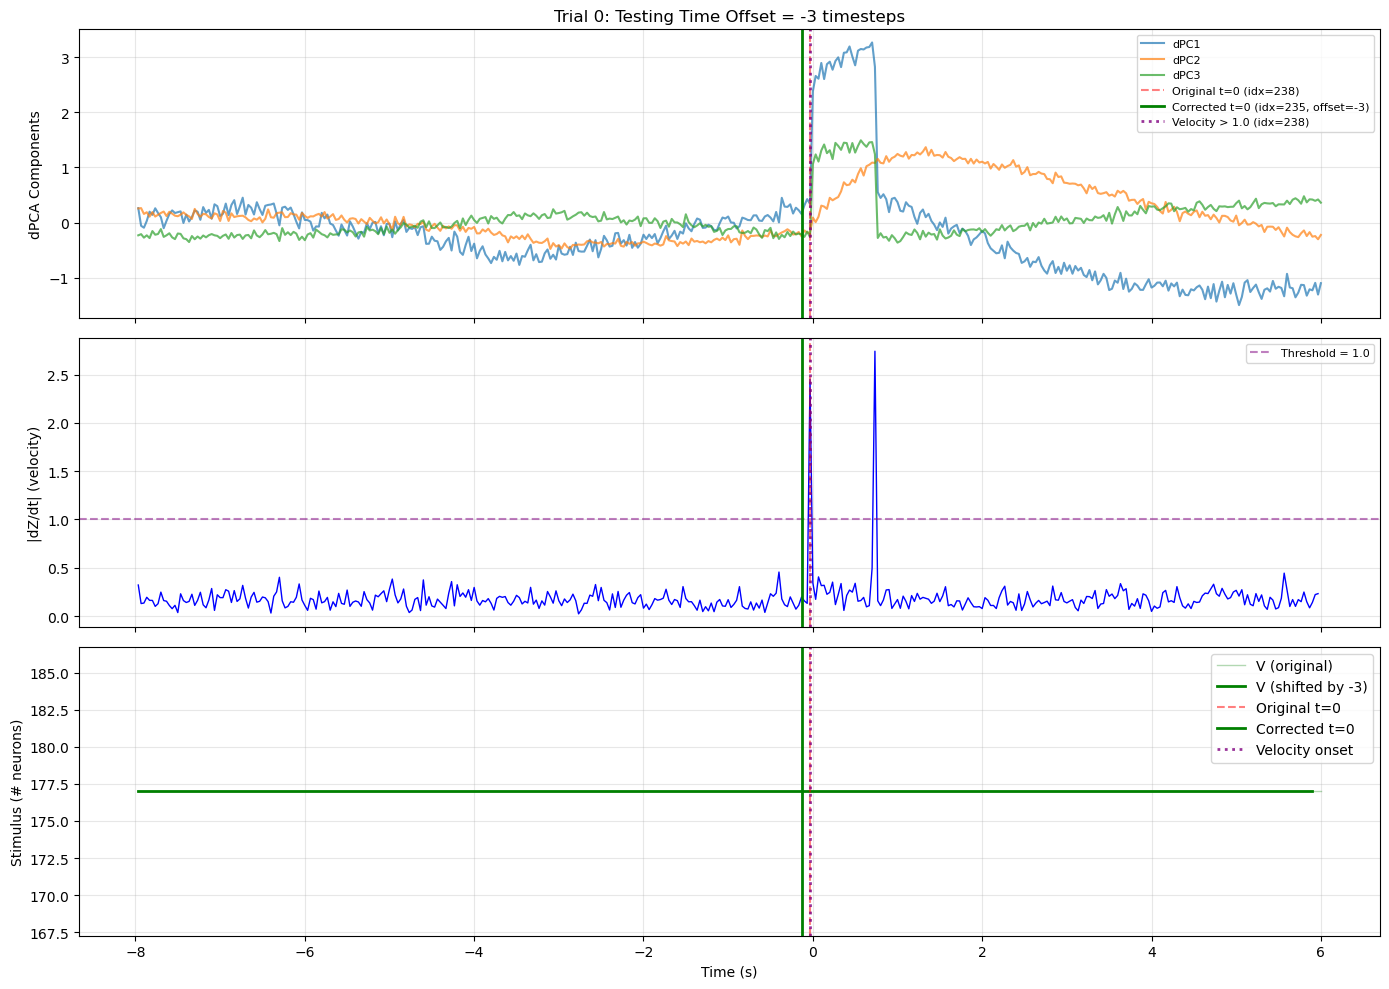


With TIME_OFFSET = -3:
  Original stim_onset_idx: 238 (time = -0.0333s)
  Corrected stim onset:    235 (time = -0.1333s)
  Velocity onset:          238 (time = -0.0333s)
  Corrected vs Velocity:   -3 timesteps difference


In [128]:
# --- Plot with TIME OFFSET of -4 timesteps ---
# This shifts the V (stimulus) signal EARLIER by 4 timesteps to test alignment

TIME_OFFSET = -3  # Negative = shift stimulus earlier

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

if len(stim_trial_indices) > 0:
    sample_trial = stim_trial_indices[0]
    Z_sample = Z_test[sample_trial]
    V_sample = V_test[sample_trial]
    dZ_magnitude = np.linalg.norm(np.diff(Z_sample, axis=0), axis=1)
    V_sum = V_sample.sum(axis=1)
    
    # Corrected stim onset with offset
    corrected_onset = stim_onset_idx + TIME_OFFSET
    
    # Find velocity onset for this trial
    above_thresh = np.where(dZ_magnitude > VELOCITY_THRESHOLD)[0]
    velocity_onset_sample = above_thresh[0] if len(above_thresh) > 0 else None
    
    # Plot 1: First 3 dPCA components
    ax1 = axes[0]
    for i in range(builtins.min(3, Z_sample.shape[1])):
        ax1.plot(time_axis, Z_sample[:, i], label=f'dPC{i+1}', alpha=0.7)
    ax1.axvline(x=time_axis[stim_onset_idx], color='red', linestyle='--', 
                label=f'Original t=0 (idx={stim_onset_idx})', linewidth=1.5, alpha=0.5)
    ax1.axvline(x=time_axis[corrected_onset], color='green', linestyle='-', 
                label=f'Corrected t=0 (idx={corrected_onset}, offset={TIME_OFFSET})', linewidth=2)
    if velocity_onset_sample is not None:
        ax1.axvline(x=time_axis[velocity_onset_sample], color='purple', linestyle=':', 
                    label=f'Velocity > {VELOCITY_THRESHOLD} (idx={velocity_onset_sample})', linewidth=2, alpha=0.8)
    ax1.set_ylabel('dPCA Components')
    ax1.legend(loc='upper right', fontsize=8)
    ax1.set_title(f'Trial {sample_trial}: Testing Time Offset = {TIME_OFFSET} timesteps')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: dZ/dt magnitude
    ax2 = axes[1]
    ax2.plot(time_axis[:-1], dZ_magnitude, 'b-', linewidth=1)
    ax2.axhline(y=VELOCITY_THRESHOLD, color='purple', linestyle='--', alpha=0.5, 
                label=f'Threshold = {VELOCITY_THRESHOLD}')
    ax2.axvline(x=time_axis[stim_onset_idx], color='red', linestyle='--', linewidth=1.5, alpha=0.5)
    ax2.axvline(x=time_axis[corrected_onset], color='green', linestyle='-', linewidth=2)
    if velocity_onset_sample is not None:
        ax2.axvline(x=time_axis[velocity_onset_sample], color='purple', linestyle=':', linewidth=2, alpha=0.8)
    ax2.set_ylabel('|dZ/dt| (velocity)')
    ax2.legend(loc='upper right', fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Stimulus (shifted)
    ax3 = axes[2]
    # Original stimulus
    ax3.plot(time_axis, V_sum, 'g-', linewidth=1, alpha=0.3, label='V (original)')
    # Shifted stimulus - shift the time axis for V
    if TIME_OFFSET < 0:
        # Shift earlier: plot V against earlier time points
        shifted_time = time_axis[:len(V_sum)+TIME_OFFSET]
        shifted_V = V_sum[-TIME_OFFSET:]
        ax3.plot(shifted_time, shifted_V, 'g-', linewidth=2, label=f'V (shifted by {TIME_OFFSET})')
    else:
        shifted_time = time_axis[TIME_OFFSET:len(V_sum)]
        shifted_V = V_sum[:-TIME_OFFSET] if TIME_OFFSET > 0 else V_sum
        ax3.plot(shifted_time, shifted_V, 'g-', linewidth=2, label=f'V (shifted by {TIME_OFFSET})')
    
    ax3.axvline(x=time_axis[stim_onset_idx], color='red', linestyle='--', 
                label='Original t=0', linewidth=1.5, alpha=0.5)
    ax3.axvline(x=time_axis[corrected_onset], color='green', linestyle='-', 
                label=f'Corrected t=0', linewidth=2)
    if velocity_onset_sample is not None:
        ax3.axvline(x=time_axis[velocity_onset_sample], color='purple', linestyle=':', 
                    label=f'Velocity onset', linewidth=2, alpha=0.8)
    ax3.set_ylabel('Stimulus (# neurons)')
    ax3.set_xlabel('Time (s)')
    ax3.legend(loc='upper right')
    ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nWith TIME_OFFSET = {TIME_OFFSET}:")
print(f"  Original stim_onset_idx: {stim_onset_idx} (time = {time_axis[stim_onset_idx]:.4f}s)")
print(f"  Corrected stim onset:    {corrected_onset} (time = {time_axis[corrected_onset]:.4f}s)")
if velocity_onset_sample is not None:
    print(f"  Velocity onset:          {velocity_onset_sample} (time = {time_axis[velocity_onset_sample]:.4f}s)")
    print(f"  Corrected vs Velocity:   {corrected_onset - velocity_onset_sample} timesteps difference")

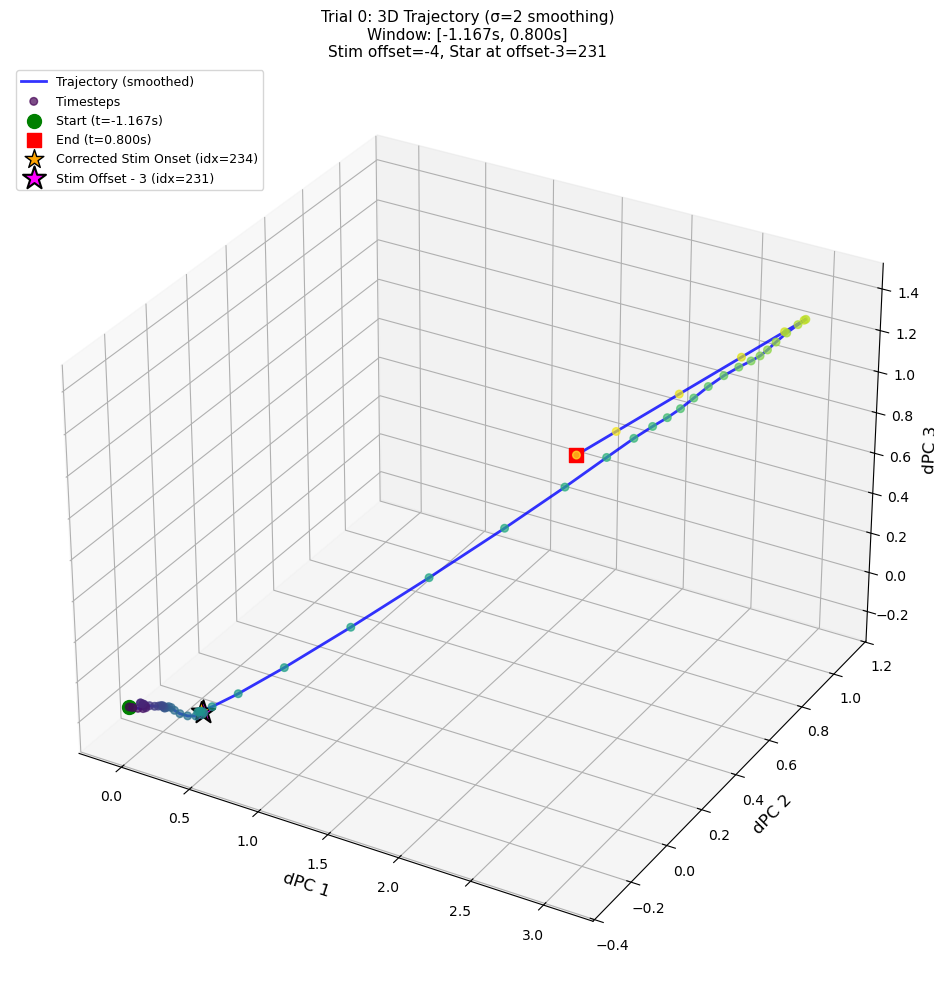

Trial 0 trajectory:
  Window: indices [204, 264) = 60 timesteps
  Corrected stim onset: 234 (local idx: 30)
  Star marker at: 231 (local idx: 27)
  Gaussian smoothing σ = 2


In [129]:
# --- 3D Trajectory of Trial 0 (Top 3 dPCA) with Gaussian Smoothing ---
from scipy.ndimage import gaussian_filter1d
from mpl_toolkits.mplot3d import Axes3D
import builtins

# Parameters
TRIAL_IDX = 0
TIME_OFFSET = -4  # Stim offset correction
STAR_OFFSET = -3  # Additional offset for star marker
WINDOW_BEFORE = 30  # Timesteps before stim onset
WINDOW_AFTER = 30   # Timesteps after stim onset
GAUSSIAN_SIGMA = 2  # Smoothing parameter

# Get trial data
Z_trial = Z_test[TRIAL_IDX]  # (T, latent_dim)

# Corrected stim onset
corrected_onset = stim_onset_idx + TIME_OFFSET
star_idx = corrected_onset + STAR_OFFSET

# Define window
window_start = builtins.max(0, corrected_onset - WINDOW_BEFORE)
window_end = builtins.min(T_time, corrected_onset + WINDOW_AFTER)

# Extract window
Z_window = Z_trial[window_start:window_end, :3]  # Top 3 components

# Apply Gaussian smoothing to each component
Z_smooth = np.zeros_like(Z_window)
for i in range(3):
    Z_smooth[:, i] = gaussian_filter1d(Z_window[:, i], sigma=GAUSSIAN_SIGMA)

# Create 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot smoothed trajectory as line
ax.plot(Z_smooth[:, 0], Z_smooth[:, 1], Z_smooth[:, 2], 
        'b-', linewidth=2, alpha=0.8, label='Trajectory (smoothed)')

# Plot dots at each timestep (on smoothed trajectory)
ax.scatter(Z_smooth[:, 0], Z_smooth[:, 1], Z_smooth[:, 2], 
           c=np.arange(len(Z_smooth)), cmap='viridis', s=30, alpha=0.7,
           label='Timesteps')

# Mark start and end
ax.scatter(*Z_smooth[0], color='green', s=100, marker='o', 
           label=f'Start (t={time_axis[window_start]:.3f}s)', zorder=5)
ax.scatter(*Z_smooth[-1], color='red', s=100, marker='s', 
           label=f'End (t={time_axis[window_end-1]:.3f}s)', zorder=5)

# Mark corrected stim onset
onset_local_idx = corrected_onset - window_start
if 0 <= onset_local_idx < len(Z_smooth):
    ax.scatter(*Z_smooth[onset_local_idx], color='orange', s=200, marker='*', 
               label=f'Corrected Stim Onset (idx={corrected_onset})', zorder=6, edgecolors='black')

# Mark star at stim offset - 3
star_local_idx = star_idx - window_start
if 0 <= star_local_idx < len(Z_smooth):
    ax.scatter(*Z_smooth[star_local_idx], color='magenta', s=300, marker='*', 
               label=f'Stim Offset - 3 (idx={star_idx})', zorder=7, edgecolors='black', linewidths=1.5)

# Labels
ax.set_xlabel('dPC 1', fontsize=12)
ax.set_ylabel('dPC 2', fontsize=12)
ax.set_zlabel('dPC 3', fontsize=12)

ax.set_title(f'Trial {TRIAL_IDX}: 3D Trajectory (σ={GAUSSIAN_SIGMA} smoothing)\n'
             f'Window: [{time_axis[window_start]:.3f}s, {time_axis[window_end-1]:.3f}s]\n'
             f'Stim offset={TIME_OFFSET}, Star at offset-3={star_idx}', fontsize=11)

ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Trial {TRIAL_IDX} trajectory:")
print(f"  Window: indices [{window_start}, {window_end}) = {window_end - window_start} timesteps")
print(f"  Corrected stim onset: {corrected_onset} (local idx: {onset_local_idx})")
print(f"  Star marker at: {star_idx} (local idx: {star_local_idx})")
print(f"  Gaussian smoothing σ = {GAUSSIAN_SIGMA}")

Plotting average firing activity around corrected stim onset
  Corrected stim onset: 237 (original: 238, offset: -1)
  Window: [232, 243) = 11 timesteps
  Number of stim trials: 18


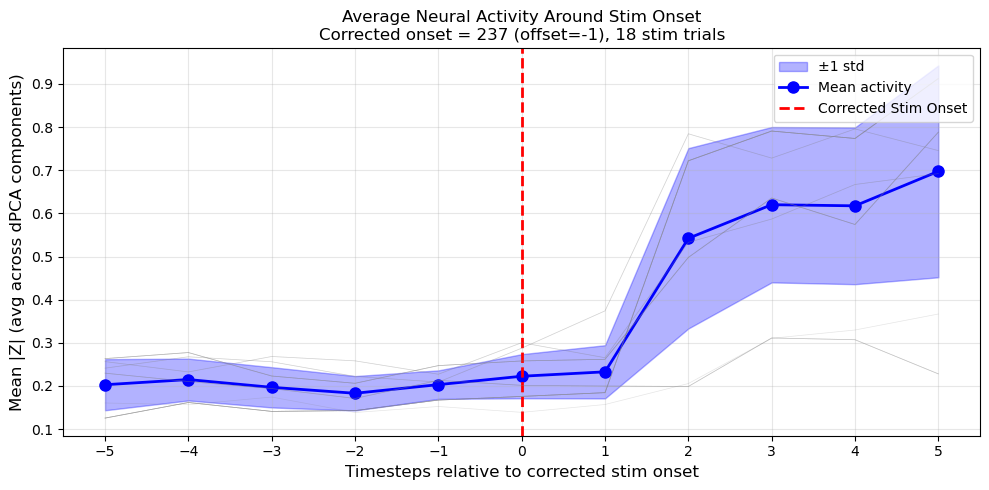


Activity values (mean ± std):
  t=-5: 0.2029 ± 0.0592
  t=-4: 0.2149 ± 0.0485
  t=-3: 0.1969 ± 0.0467
  t=-2: 0.1831 ± 0.0398
  t=-1: 0.2031 ± 0.0330
  t=+0: 0.2225 ± 0.0511 <-- STIM ONSET
  t=+1: 0.2328 ± 0.0617
  t=+2: 0.5423 ± 0.2090
  t=+3: 0.6201 ± 0.1801
  t=+4: 0.6176 ± 0.1817
  t=+5: 0.6975 ± 0.2456


In [130]:
# --- Average Firing Activity Around Corrected Stim Onset ---
import builtins

# Parameters
TIME_OFFSET = -1  # Current correction
WINDOW_HALF = 5   # 5 timesteps before and after

# Corrected stim onset
corrected_onset = stim_onset_idx + TIME_OFFSET

# Window indices
window_start = corrected_onset - WINDOW_HALF
window_end = corrected_onset + WINDOW_HALF + 1  # +1 to include the endpoint

# Get stim trials only
stim_trial_mask = V_test.max(axis=(1, 2)) > 0
stim_trial_indices = np.where(stim_trial_mask)[0]

print(f"Plotting average firing activity around corrected stim onset")
print(f"  Corrected stim onset: {corrected_onset} (original: {stim_onset_idx}, offset: {TIME_OFFSET})")
print(f"  Window: [{window_start}, {window_end}) = {window_end - window_start} timesteps")
print(f"  Number of stim trials: {len(stim_trial_indices)}")

# Collect activity from all stim trials
# Using Z (dPCA latent activity) - average across all components
all_activity = []
for trial_idx in stim_trial_indices:
    Z_trial = Z_test[trial_idx]  # (T, latent_dim)
    # Mean across latent dimensions at each timepoint
    activity = np.mean(np.abs(Z_trial[window_start:window_end]), axis=1)
    all_activity.append(activity)

all_activity = np.array(all_activity)  # (n_trials, window_size)

# Compute mean and std across trials
mean_activity = np.mean(all_activity, axis=0)
std_activity = np.std(all_activity, axis=0)

# Time axis for window (relative to corrected stim onset)
relative_time = np.arange(-WINDOW_HALF, WINDOW_HALF + 1)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

# Mean with shaded std
ax.fill_between(relative_time, mean_activity - std_activity, mean_activity + std_activity, 
                alpha=0.3, color='blue', label='±1 std')
ax.plot(relative_time, mean_activity, 'b-o', linewidth=2, markersize=8, label='Mean activity')

# Mark stim onset (t=0)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Corrected Stim Onset')

# Individual trials (faint)
for i, activity in enumerate(all_activity):
    ax.plot(relative_time, activity, 'gray', alpha=0.2, linewidth=0.5)

ax.set_xlabel('Timesteps relative to corrected stim onset', fontsize=12)
ax.set_ylabel('Mean |Z| (avg across dPCA components)', fontsize=12)
ax.set_title(f'Average Neural Activity Around Stim Onset\n'
             f'Corrected onset = {corrected_onset} (offset={TIME_OFFSET}), {len(stim_trial_indices)} stim trials', 
             fontsize=12)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Set integer ticks
ax.set_xticks(relative_time)

plt.tight_layout()
plt.show()

# Print values
print(f"\nActivity values (mean ± std):")
for t, (m, s) in enumerate(zip(mean_activity, std_activity)):
    marker = " <-- STIM ONSET" if relative_time[t] == 0 else ""
    print(f"  t={relative_time[t]:+2d}: {m:.4f} ± {s:.4f}{marker}")

Plotting 5 individual stim trials
  Corrected stim onset: 237 (original: 238, offset: -1)


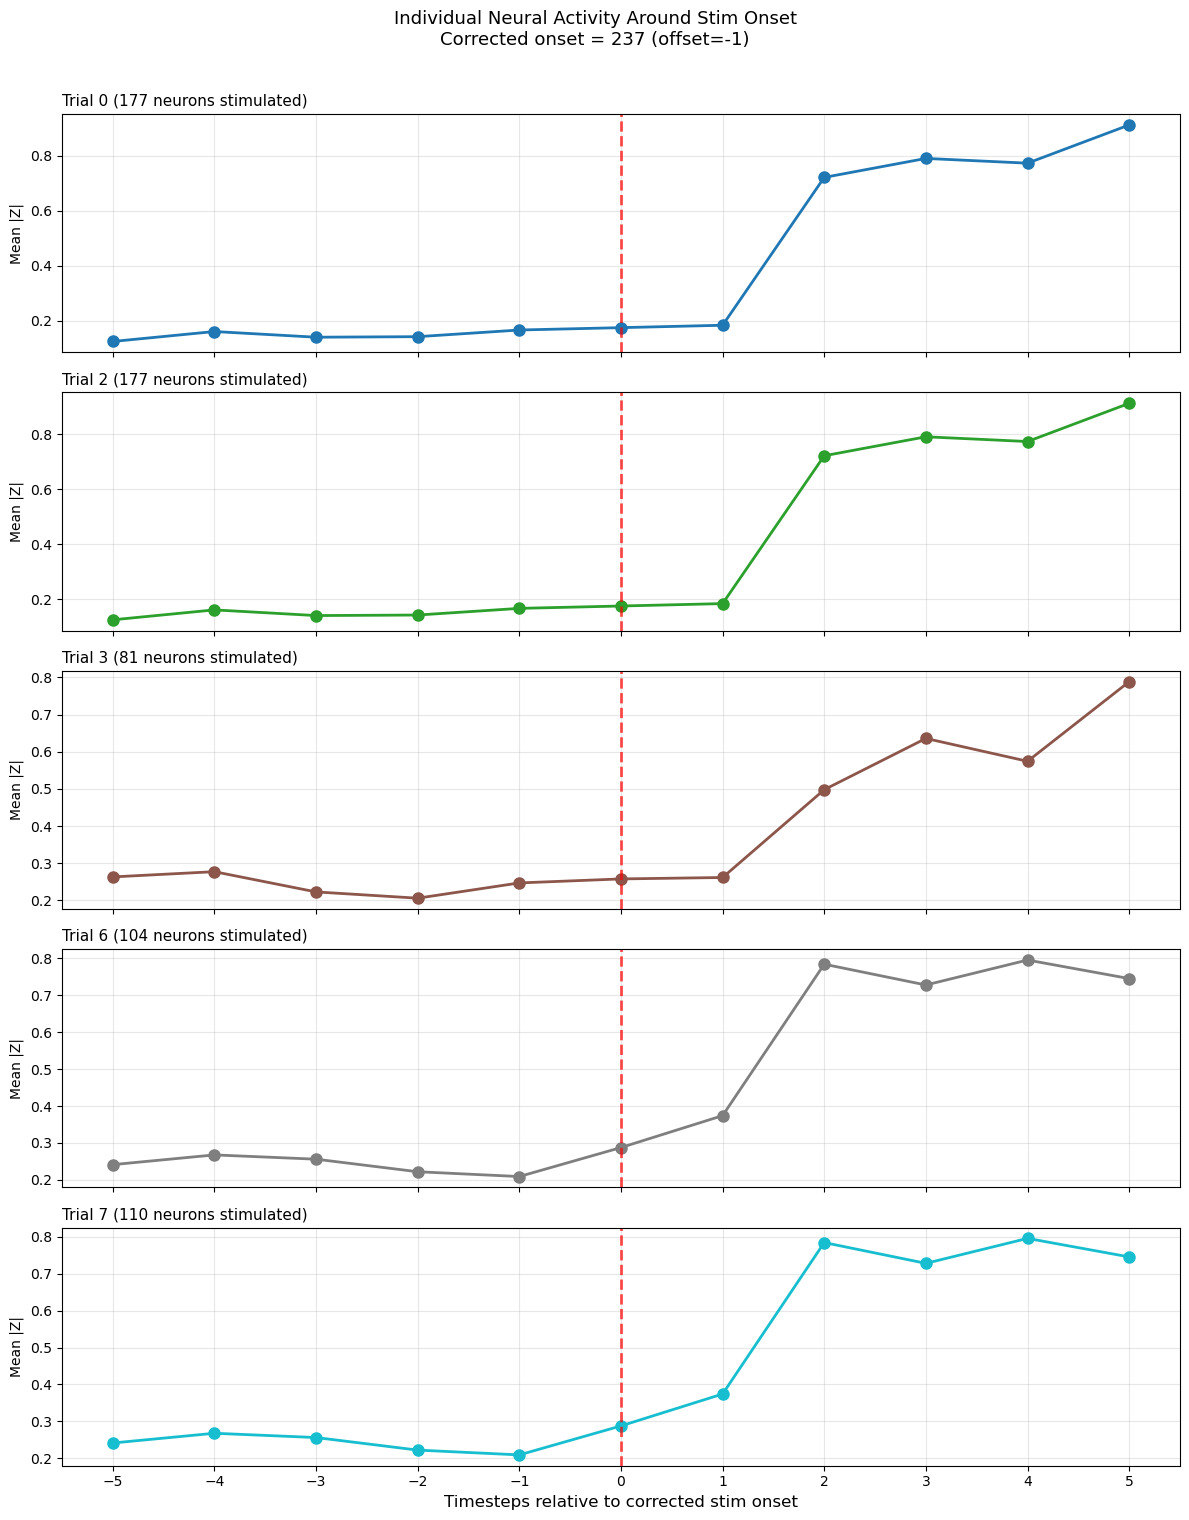

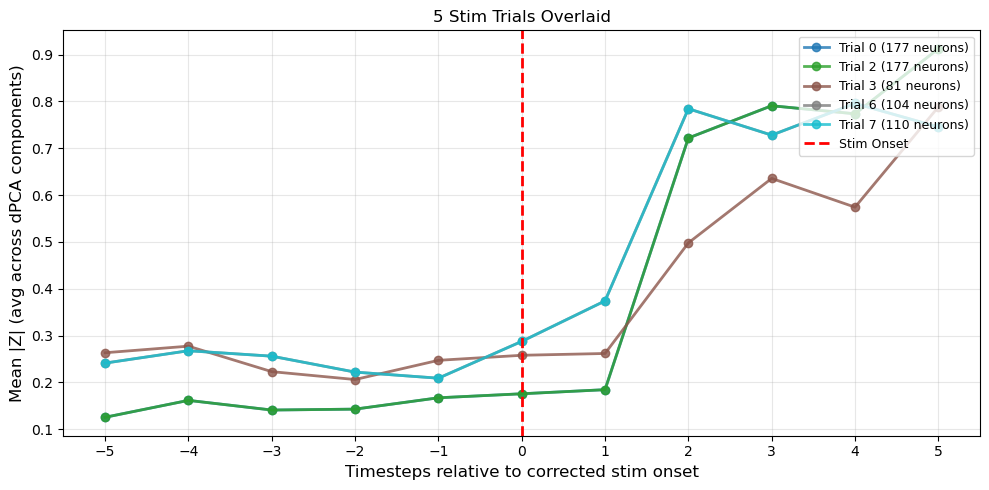

In [131]:
# --- Individual Firing Activity for 5 Stim Trials ---
import builtins

# Parameters
TIME_OFFSET = -1  # Current correction
WINDOW_HALF = 5   # 5 timesteps before and after
N_TRIALS_TO_SHOW = 5

# Corrected stim onset
corrected_onset = stim_onset_idx + TIME_OFFSET

# Window indices
window_start = corrected_onset - WINDOW_HALF
window_end = corrected_onset + WINDOW_HALF + 1

# Get stim trials only
stim_trial_mask = V_test.max(axis=(1, 2)) > 0
stim_trial_indices = np.where(stim_trial_mask)[0]

# Select first N stim trials
trials_to_plot = stim_trial_indices[:N_TRIALS_TO_SHOW]

print(f"Plotting {len(trials_to_plot)} individual stim trials")
print(f"  Corrected stim onset: {corrected_onset} (original: {stim_onset_idx}, offset: {TIME_OFFSET})")

# Time axis for window (relative to corrected stim onset)
relative_time = np.arange(-WINDOW_HALF, WINDOW_HALF + 1)

# Create subplots
fig, axes = plt.subplots(N_TRIALS_TO_SHOW, 1, figsize=(12, 3*N_TRIALS_TO_SHOW), sharex=True)

colors = plt.cm.tab10(np.linspace(0, 1, N_TRIALS_TO_SHOW))

for i, trial_idx in enumerate(trials_to_plot):
    ax = axes[i]
    
    Z_trial = Z_test[trial_idx]  # (T, latent_dim)
    
    # Mean activity across latent dimensions at each timepoint
    activity = np.mean(np.abs(Z_trial[window_start:window_end]), axis=1)
    
    # Plot
    ax.plot(relative_time, activity, '-o', color=colors[i], linewidth=2, markersize=8)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
    
    # Get number of neurons stimulated in this trial
    V_trial = V_test[trial_idx]
    n_neurons_stim = (V_trial.any(axis=0)).sum()
    
    ax.set_ylabel(f'Mean |Z|', fontsize=10)
    ax.set_title(f'Trial {trial_idx} ({n_neurons_stim} neurons stimulated)', fontsize=11, loc='left')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(relative_time)

axes[-1].set_xlabel('Timesteps relative to corrected stim onset', fontsize=12)

fig.suptitle(f'Individual Neural Activity Around Stim Onset\n'
             f'Corrected onset = {corrected_onset} (offset={TIME_OFFSET})', 
             fontsize=13, y=1.01)

plt.tight_layout()
plt.show()

# Also show overlay plot
fig2, ax2 = plt.subplots(figsize=(10, 5))

for i, trial_idx in enumerate(trials_to_plot):
    Z_trial = Z_test[trial_idx]
    activity = np.mean(np.abs(Z_trial[window_start:window_end]), axis=1)
    V_trial = V_test[trial_idx]
    n_neurons_stim = (V_trial.any(axis=0)).sum()
    
    ax2.plot(relative_time, activity, '-o', color=colors[i], linewidth=2, markersize=6, 
             alpha=0.8, label=f'Trial {trial_idx} ({n_neurons_stim} neurons)')

ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Stim Onset')
ax2.set_xlabel('Timesteps relative to corrected stim onset', fontsize=12)
ax2.set_ylabel('Mean |Z| (avg across dPCA components)', fontsize=12)
ax2.set_title(f'5 Stim Trials Overlaid', fontsize=12)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(relative_time)

plt.tight_layout()
plt.show()